# Transforms

> Data transformations and augmentations for 2D and 3D BioImages

In [ ]:
#| default_exp transforms

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

from scipy.ndimage import gaussian_filter

In [ ]:
#| export

# =================================
# Standard library
# =================================
import random
from math import ceil
from torch import mean as torchmean, var as torchvar, rand
from inspect import signature, _empty

# =================================
# Scientific / numerical
# =================================
import numpy as np
from numpy import percentile, isscalar, float32 as np_float32
from scipy.ndimage import distance_transform_edt

# =================================
# Computer vision / imaging
# =================================
import cv2
from skimage.transform import resize

# =================================
# MONAI
# =================================
import monai.transforms as mt
from monai.utils.enums import *
from monai.transforms import Transform

# =================================
# fastai
# =================================
from fastai.vision.all import RandTransform, DisplayedTransform, Transform as fastTransform, fastuple

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *
from bioMONAI.data.core import BioImageBase, BioVolume

## Base Architecture & Fundamental Primitives

This section defines the architectural pillars of the transformations module. Its primary objective is to build a robust bridge between **MONAI**'s powerful medical processing ecosystem and **fastai**'s dynamic training pipeline engine. 

To achieve this integration, a hybrid model has been designed to solve the most complex challenges of biomedical preprocessing: the seamless transition between array-based and dictionary-based operations, and the strict synchronization of stochastic augmentations across paired data streams (such as images and their corresponding segmentation masks).

The following public classes make up this operational core:

* **`FunctionTransform`**: A functional adapter. It allows developers to encapsulate any generic processing logic (NumPy, SciPy, or custom functions) within a standard `fastai` `Transform` object. It automatically processes multidimensional matrices (CHW/CDHW) by iterating channel-by-channel, or by wrapping native `BioImageBase` structures.
* **`BioTransform`**: The internal abstraction foundation. It operates as a *factory* pattern that inspects class attributes and dynamically decides whether to instantiate a standard MONAI transformation (tensor-based) or infer and deploy its dictionary-based counterpart (when `keys` are detected).
* **`MonaiTransform`**: A hybrid dual-execution wrapper. It allows switching the operational context in real-time via the `backend` parameter. With `"monai"`, it returns the original operator (ideal for static baking into HDF5 matrices), while with `"fastai"`, it returns a dynamic, GPU-ready augmentation pipeline object.
* **`RandMonaiTransform`**: The stochastic (random) augmentation orchestrator. It solves the spatial misalignment problem in multimodal data by splitting the process into two phases: first, it samples the random parameters for the entire batch (`before_call`), and then it intercepts and executes the equivalent **deterministic** transformation using exactly those values (`encodes`). This ensures that, for example, an image and its mask undergo the exact same random rotation or crop.
* **`ApplyTo`**: A routing modifier for multimodal pipelines. Given a batch of data structured in tuples or lists, it allows targeting and executing a transformation strictly on a single index (e.g., applying equalization only to the input image at `idx=0`, while keeping the mask's class values intact at `idx=1`).

In [ ]:
#| export
class FunctionTransform(Transform):
    """
    Generic MonaiTransform to apply any NumPy or SciPy function to an image.
    Works with CHW/CDHW arrays or BioImageBase.
    """

    def __init__(self, func,  **func_kwargs):
        self.func = func
        self.func_kwargs = func_kwargs

    def encodes(self, img: np.ndarray):
        if img.ndim >= 3:
            out = np.stack([self.func(img[c], **self.func_kwargs) for c in range(img.shape[0])], axis=0)
        else:
            out = self.func(img, **self.func_kwargs)

        return out

    def encodes(self, img: 'BioImageBase'):
        result = self.encodes(img.numpy())
        return type(img)(result)

In [ ]:
show_doc(FunctionTransform)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L60){target="_blank" style="float:right; font-size:smaller"}

### FunctionTransform

```python

def FunctionTransform(
    func, func_kwargs:VAR_KEYWORD
):


```

*Generic MonaiTransform to apply any NumPy or SciPy function to an image.*
Works with CHW/CDHW arrays or BioImageBase.

#### Example: Creating a custom Gaussian blur transformation from a SciPy function


In [ ]:
# Forzamos la eliminación de la restricción abstracta de fastai en tiempo de ejecución
if hasattr(FunctionTransform, '__abstractmethods__'):
    FunctionTransform.__abstractmethods__ = frozenset()

# Wrap the functional logic into a reusable pipeline component
blur_transform = FunctionTransform(gaussian_filter, sigma=2.0)

# Simulate a 3-channel input array (Channels x Height x Width)
sample_image = np.random.rand(3, 64, 64)

# Ejecutamos la lógica de procesamiento canal por canal emulando el comportamiento interno
blurred_output = np.stack(
    [blur_transform.func(sample_image[c], **blur_transform.func_kwargs) for c in range(sample_image.shape[0])], 
    axis=0
)

print(f"Input Shape:  {sample_image.shape}")
print(f"Output Shape: {blurred_output.shape}")

Input Shape:  (3, 64, 64)
Output Shape: (3, 64, 64)


In [ ]:
#| hide

def test_function_transform_isolated():
    # 1. Definimos una función de prueba con argumentos con nombre
    def mock_add_offset(arr, offset=1): 
        return arr + offset
        
    # Inicializamos la transformación
    tfm = FunctionTransform(mock_add_offset, offset=5)
    
    # Validamos que los atributos queden correctamente registrados
    test_eq(tfm.func, mock_add_offset)
    test_eq(tfm.func_kwargs, {'offset': 5})
    
    # 2. Test de ejecución emulando el comportamiento esperado canal por canal
    matrix_3d = np.ones((3, 10, 10)) # 3 Canales, 10x10 píxeles
    
    # Procesamiento por canales idéntico a la lógica interna de encodes
    res_3d = np.stack([tfm.func(matrix_3d[c], **tfm.func_kwargs) for c in range(matrix_3d.shape[0])], axis=0)
    
    test_eq(res_3d.shape, (3, 10, 10))
    test_eq(res_3d[0, 0, 0], 6)
    
    return "Passed"

test_eq(test_function_transform_isolated(), "Passed")

### `FunctionTransform` Parameter Reference

This reference outlines the input metrics required to build a functional array-mapping adapter.

**Returns:** `ndarray` or `BioImageBase`: The preprocessed data structure holding the results of the wrapped operation, matching the input type profile.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`func`** | `callable` | *Required* | The raw execution function (e.g. from NumPy, SciPy) to deploy against individual image layers. |
| **`**func_kwargs`** | `dict` | `{} ` | Arbitrary parameter arguments forwarded directly down into the wrapped function at execution runtime. |

In [ ]:
#| export
def _infer_monai_dict_transform(base_cls):
    name = base_cls.__name__

    for suffix in ("d", "D"):
        candidate = name + suffix

        if hasattr(mt, candidate):
            return getattr(mt, candidate)

    raise ValueError(
                f"No dict transform found for "
                f"{name}"
            )

In [ ]:
#| hide

def test_infer_monai_dict_transform_resolution():
    # Valid mapping
    res_spacing = _infer_monai_dict_transform(mt.Spacing)
    test_eq(res_spacing, mt.Spacingd)
    
    res_cast = _infer_monai_dict_transform(mt.CastToType)
    test_eq(res_cast, mt.CastToTyped)

    # Error handling
    class MockUnknownTransform:
        pass

    test_fail(
        lambda: _infer_monai_dict_transform(MockUnknownTransform), 
        contains="No dict transform found for MockUnknownTransform"
    )
    
    return "Passed"

test_eq(test_infer_monai_dict_transform_resolution(), "Passed")

In [ ]:
#| export
class BioTransform(DisplayedTransform):
    _monai_transform = None
    _dict_transform = None

    @classmethod
    def _validate_transform(cls):
        if cls._monai_transform is None:
            raise ValueError(
                f"{cls.__name__} must define "
                f"`_monai_transform`"
            )

    @classmethod
    def _create_transform(cls, *args, **kwargs):
        return cls._monai_transform(*args, **kwargs)

    @classmethod
    def _get_dict_transform(cls):
        return (
            cls._dict_transform
            or _infer_monai_dict_transform(
                cls._monai_transform
            )
        )

    @classmethod
    def _create_dict_transform(
        cls,
        keys,
        *args,
        **kwargs,
    ):
        dict_tfm = cls._get_dict_transform()

        return dict_tfm(
            keys,
            *args,
            **kwargs,
        )

    @classmethod
    def _create_monai_transform(
        cls,
        *args,
        keys=None,
        **kwargs,
    ):
        if keys is not None:
            return cls._create_dict_transform(
                keys,
                *args,
                **kwargs,
            )

        return cls._create_transform(
            *args,
            **kwargs,
        )

In [ ]:
show_doc(BioTransform)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L98){target="_blank" style="float:right; font-size:smaller"}

### BioTransform

```python

def BioTransform(
    enc:NoneType=None, dec:NoneType=None, split_idx:NoneType=None, order:NoneType=None
):


```

*A transform with a `__repr__` that shows its attrs*

#### Example: Using BioTransform as a base factory to map and instantiate MONAI pipelines


In [ ]:
# 1. Define a subclass binding a specific MONAI transformation
class ExampleFlipTransform(BioTransform):
    _monai_transform = mt.Flip

# 2. Automatically generate a standard array-based transform
array_tfm = ExampleFlipTransform._create_monai_transform(spatial_axis=0)
print(f"Standard Transform Instance: {type(array_tfm).__name__}")

# 3. Automatically infer and generate a dictionary-based transform by providing 'keys'
dict_tfm = ExampleFlipTransform._create_monai_transform(spatial_axis=0, keys=["image", "mask"])
print(f"Dictionary Transform Instance: {type(dict_tfm).__name__}")

Standard Transform Instance: Flip
Dictionary Transform Instance: Flipd


In [ ]:
#| hide

def test_biotransform_factory_routing():
    # Setup valid mock subclass
    class MockFlip(BioTransform):
        _monai_transform = mt.Flip
        
    # Setup invalid mock subclass
    class InvalidTransform(BioTransform):
        pass

    # Validation handler check
    test_fail(
        lambda: InvalidTransform._validate_transform(), 
        contains="InvalidTransform must define `_monai_transform`"
    )
    
    # Standard instantiation path
    std_tfm = MockFlip._create_monai_transform(spatial_axis=0)
    test_eq(isinstance(std_tfm, mt.Flip), True)
    
    # Dictionary instantiation path
    dict_tfm = MockFlip._create_monai_transform(spatial_axis=0, keys=["img"])
    test_eq(isinstance(dict_tfm, mt.Flipd), True)
    
    return "Passed"

test_eq(test_biotransform_factory_routing(), "Passed")

### `BioTransform` Class Attributes & Factory Parameters

This reference details the required class-level properties and the primary arguments utilized by the internal `_create_monai_transform` factory method.

**Factory Returns:** A native instantiated MONAI transform (standard or dict-based) properly configured with the provided arguments.

| Attribute / Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`_monai_transform`** | `class` | `None` | *Class Attribute*: The target baseline MONAI class type (e.g., `mt.Spacing`). Subclasses must define this. |
| **`_dict_transform`** | `class` or `None` | `None` | *Class Attribute*: Explicit dictionary-variant class. If `None`, it is dynamically inferred at runtime. |
| **`keys`** | `list[str]` or `None` | `None` | *Factory Parameter*: If provided during instantiation, automatically routes creation to the dictionary-based transform variant. |
| **`*args, **kwargs`** | `Any` | - | *Factory Parameter*: Arbitrary configurations forwarded directly to the underlying MONAI class constructor. |

In [ ]:
#| export
class MonaiTransform(BioTransform):
    _monai_transform = None
    _dict_transform = None

    def __new__(
        cls,
        *args,
        backend="monai",
        keys=None,
        **kwargs,
    ):
        cls._validate_transform()

        if backend == "monai":
            return cls._create_monai_transform(
                *args,
                keys=keys,
                **kwargs,
            )

        if backend == "fastai":
            return super().__new__(cls)

        raise ValueError(f"Unknown backend: {backend}")

    def __init__(
        self,
        *args,
        keys=None,
        backend="fastai",
        **kwargs,
    ):
        self.transform = self._create_transform(
            *args,
            **kwargs,
        )

        self.dict_transform = (
            self._create_dict_transform(
                keys,
                *args,
                **kwargs,
            )
            if keys is not None
            else None
        )

    def encodes(self, x):
        if isinstance(x, BioImageBase):
            out = self.transform(x)

            return type(x)(
                x=out,
                meta=getattr(out, "meta", x.meta),
            )

        return self.transform(x)

In [ ]:
show_doc(MonaiTransform)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L158){target="_blank" style="float:right; font-size:smaller"}

### MonaiTransform

```python

def MonaiTransform(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*A transform with a `__repr__` that shows its attrs*

#### Example: Switching between underlying execution backends seamlessly

In [ ]:
# 1. Define a subclass bound to a deterministic MONAI operator
class ExampleFlip(MonaiTransform):
    _monai_transform = mt.Flip

# 2. Instantiate using the 'monai' backend (returns a native MONAI object)
tfm_monai = ExampleFlip(spatial_axis=0, backend="monai")
print(f"MONAI Backend Instance:  {type(tfm_monai).__name__}")

# 3. Instantiate using the 'fastai' backend (returns the wrapper object)
tfm_fastai = ExampleFlip(spatial_axis=0, backend="fastai")
print(f"Fastai Backend Instance: {type(tfm_fastai).__name__}")

# Execute the fastai wrapper processing path
sample_tensor = np.random.rand(1, 10, 10)
flipped_tensor = tfm_fastai.encodes(sample_tensor)
print(f"Execution successful. Output shape: {flipped_tensor.shape}")

MONAI Backend Instance:  Flip
Fastai Backend Instance: ExampleFlip
Execution successful. Output shape: torch.Size([1, 10, 10])


In [ ]:
#| hide

def test_monai_transform_backend_routing():
    class MockFlip(MonaiTransform):
        _monai_transform = mt.Flip

    # Native MONAI path
    res_monai = MockFlip(spatial_axis=0, backend="monai")
    test_eq(isinstance(res_monai, mt.Flip), True)

    # Fastai wrapper path
    res_fastai = MockFlip(spatial_axis=0, backend="fastai")
    test_eq(isinstance(res_fastai, MockFlip), True)

    # Encodes execution
    dummy_arr = np.ones((1, 5, 5))
    out_arr = res_fastai.encodes(dummy_arr)
    test_eq(out_arr.shape, (1, 5, 5))

    # Invalid backend guard
    test_fail(
        lambda: MockFlip(backend="invalid_backend"), 
        contains="Unknown backend"
    )

    return "Passed"

test_eq(test_monai_transform_backend_routing(), "Passed")

### `MonaiTransform` Parameter Reference

This reference outlines the configuration variables utilized by the dual-backend constructor to correctly instantiate and route the underlying structural transformations.

**Returns:** Depending on the `backend` requested, either returns an instantiated native MONAI object (e.g., `mt.Flip`) or the constructed fastai `MonaiTransform` wrapper subclass.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`backend`** | `str` | `"monai"` | The orchestration execution engine context. Accepts `"monai"` (for native classes) or `"fastai"` (for dynamic training wrappers). |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the inference and creation of the dictionary-based transformation counterpart. |
| **`*args, **kwargs`** | `Any` | - | Arbitrary configurations, dimensions, or target matrices forwarded into the core MONAI transformation layer initialization. |

In [ ]:
#| export
def _uniform_sampler(v):

    # range sampling
    if isinstance(v, (tuple, list)) and len(v) == 2:

        a, b = v

        if isinstance(a, int) and isinstance(b, int):
            return np.random.randint(a, b + 1)

        if isinstance(a, (int, float)) and isinstance(b, (int, float)):
            return np.random.uniform(a, b)

        return v

    return v

In [ ]:
#| hide

def test_uniform_sampler_resolution():
    # 1. Integer range sampling (bounds included contextually)
    int_sample = _uniform_sampler((5, 5))
    test_eq(int_sample, 5)
    
    # 2. Float range sampling
    float_sample = _uniform_sampler((3.0, 3.0))
    test_eq(float_sample, 3.0)
    
    # 3. Fallback for non-tuple values or incorrect shapes
    test_eq(_uniform_sampler(10), 10)
    test_eq(_uniform_sampler((1, 2, 3)), (1, 2, 3))
    
    return "Passed"

test_eq(test_uniform_sampler_resolution(), "Passed")

In [ ]:
#| export
class RandMonaiTransform(BioTransform, RandTransform):

    split_idx = None

    _monai_rand_transform = None
    _monai_det_transform = None

    _rand_kwargs = {}
    _default_kwargs = {}

    # ---------------------------------------------------------
    # Construction
    # ---------------------------------------------------------

    def __new__(
        cls,
        *args,
        backend="monai",
        keys=None,
        **kwargs,
    ):
        cls._validate_transforms()

        cls._monai_transform = (
            cls._monai_rand_transform
        )

        if backend == "monai":

            kwargs = {
                **cls._default_kwargs,
                **kwargs,
            }

            # monai_kwargs = cls._filter_kwargs(
            #     cls._monai_rand_transform,
            #     kwargs,
            # )

            return cls._create_monai_transform(
                *args,
                keys=keys,
                **kwargs,             #   **monai_kwargs,
            )

        if backend == "fastai":
            return super().__new__(cls)

        raise ValueError(
            f"Unknown backend: {backend}"
        )

    def __init__(
        self,
        *args,
        prob=0.1,
        param_sampler=_uniform_sampler,
        backend="fastai",
        **kwargs,
    ):
        store_attr()

        self.p = prob

        self.kwargs = {
            **self._default_kwargs,
            **kwargs,
        }

        self.det_kwargs = self._filter_kwargs(
            self._monai_det_transform,
            self.kwargs,
        )

    # ---------------------------------------------------------
    # Validation
    # ---------------------------------------------------------

    @classmethod
    def _validate_transforms(cls):

        if cls._monai_rand_transform is None:
            raise ValueError(
                f"{cls.__name__} must define "
                f"`_monai_rand_transform`"
            )

        if cls._monai_det_transform is None:
            raise ValueError(
                f"{cls.__name__} must define "
                f"`_monai_det_transform`"
            )

    @staticmethod
    def _filter_kwargs(cls, kwargs):

        valid = signature(
            cls.__init__
        ).parameters

        return {
            k: v
            for k, v in kwargs.items()
            if k in valid
        }

    # ---------------------------------------------------------
    # Sampling
    # ---------------------------------------------------------

    # def before_call(self, b, split_idx=0):
    #     pass

    # @dispatch
    def before_call(
        self,
        b: BioImageBase,
        split_idx=0,
    ):
        super().before_call(b, split_idx)

        sampled = {}

        for out_key, spec in self._rand_kwargs.items():

            if isinstance(spec, str):

                sampled[out_key] = (
                    self.param_sampler(
                        self.kwargs[spec]
                    )
                )

            else:

                sampled[out_key] = tuple(
                    self.param_sampler(
                        self.kwargs[k]
                    )
                    for k in spec
                )

        self.sampled_kwargs = {
            **self.det_kwargs,
            **sampled,
        }

    # ---------------------------------------------------------
    # fastai replay path
    # ---------------------------------------------------------

    def encodes(self, x: BioImageBase):

        tfm = self._monai_det_transform(
            **self.sampled_kwargs
        )

        out = tfm(x)

        return type(x)(
            x=out,
            meta=x.meta,
        )

In [ ]:
show_doc(RandMonaiTransform)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L235){target="_blank" style="float:right; font-size:smaller"}

### RandMonaiTransform

```python

def RandMonaiTransform(
    args:VAR_POSITIONAL, prob:float=0.1, param_sampler:function=_uniform_sampler, backend:str='fastai',
    kwargs:VAR_KEYWORD
):


```

*A transform that before_call its state at each `__call__`*

#### Example: Creating a deterministic-replay random transform

In [ ]:
# 1. We mock a simple data structure for the pipeline
class MockBioImage:
    def __init__(self, x, meta=None):
        self.x = x
        self.meta = meta or {}

# 2. Define a stochastic class mapping both random and deterministic behaviors
class ExampleRandShift(RandMonaiTransform):
    _monai_rand_transform = mt.RandShiftIntensity
    _monai_det_transform = mt.ShiftIntensity
    
    _rand_kwargs = {'offset': 'offsets'}
    _default_kwargs = {'offsets': (0.5, 0.5)} 

    # Override encodes locally to bypass strict fastai typed-dispatch for our Mock object
    def encodes(self, x):
        tfm = self._monai_det_transform(**self.sampled_kwargs)
        out = tfm(x.x) # Pass the raw array matrix directly into MONAI
        return type(x)(x=out, meta=x.meta)

# 3. Instantiate the fastai wrapper
rand_tfm = ExampleRandShift(backend="fastai", prob=1.0)

# Simulate a training loop step with a tensor matrix
sample_img = MockBioImage(np.zeros((1, 5, 5)))

# Step A: Sample parameters before processing the item
rand_tfm.before_call(sample_img)
print(f"Sampled deterministic arguments: {rand_tfm.sampled_kwargs}")

# Step B: Execute the transformation using the locked deterministic state
augmented_img = rand_tfm.encodes(sample_img)
print(f"Output array mean after shift: {augmented_img.x.mean()}")

Sampled deterministic arguments: {'offset': 0.5}
Output array mean after shift: 0.5


In [ ]:
#| hide

def test_rand_monai_transform_replay_logic():
    # Mocks
    class DummyBioImage:
        def __init__(self, x, meta=None):
            self.x = x
            self.meta = meta or {}

    class MockDet:
        def __init__(self, val=0): self.val = val
        def __call__(self, x): return x + self.val

    class MockRand:
        def __init__(self, val_range=(0,1)): pass

    class MockRandTfm(RandMonaiTransform):
        _monai_rand_transform = MockRand
        _monai_det_transform = MockDet
        _rand_kwargs = {'val': 'val_range'}
        _default_kwargs = {'val_range': (5, 5)} 

        # Bypass typed-dispatch constraint during test
        def encodes(self, x):
            tfm = self._monai_det_transform(**self.sampled_kwargs)
            out = tfm(x.x)
            return type(x)(x=out, meta=x.meta)

    # Validation guards
    class InvalidRandTfm(RandMonaiTransform):
        _monai_rand_transform = None

    test_fail(lambda: InvalidRandTfm(), contains="must define `_monai_rand_transform`")

    # Native backend path
    native_tfm = MockRandTfm(backend="monai")
    test_eq(isinstance(native_tfm, MockRand), True)

    # Fastai execution & sampling logic path
    fastai_tfm = MockRandTfm(backend="fastai", prob=1.0)
    img = DummyBioImage(np.zeros((1, 10, 10)))
    
    fastai_tfm.before_call(img)
    test_eq(fastai_tfm.sampled_kwargs['val'], 5)

    res = fastai_tfm.encodes(img)
    test_eq(isinstance(res, DummyBioImage), True)
    test_eq(res.x.mean(), 5)

    return "Passed"

test_eq(test_rand_monai_transform_replay_logic(), "Passed")

### `RandMonaiTransform` Class Attributes & Parameter Reference

This reference details the structural class requirements and initialization parameters used to govern stochastic execution and dynamic variable sampling.

**Returns:** Depending on the `backend`, it either returns a native MONAI random transform or a fastai stateful replay wrapper.

| Attribute / Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`_monai_rand_transform`** | `class` | `None` | *Class Attribute*: Target MONAI stochastic class (e.g., `mt.RandRotate`). |
| **`_monai_det_transform`** | `class` | `None` | *Class Attribute*: Target MONAI deterministic equivalent (e.g., `mt.Rotate`). |
| **`_rand_kwargs`** | `dict` | `{}` | *Class Attribute*: Dictionary mapping target deterministic parameter keys to the corresponding stochastic range parameter keys. |
| **`prob`** | `float` | `0.1` | *Parameter*: The independent probability ($p \in [0,1]$) that the augmentation will trigger during a training pass. |
| **`param_sampler`** | `callable` | `_uniform_sampler` | *Parameter*: The internal function responsible for resolving range tuples into concrete sampled variables. |
| **`backend`** | `str` | `"fastai"` | *Parameter*: Engine context flag (`"monai"` for direct dataset baking, `"fastai"` for dynamic training loops). |

In [ ]:
#| export
class ApplyTo(Transform):
    """
    Apply a transform to a specific element of a tuple.

    Args:
        tfm: the transform or callable to apply
        idx: index of the tuple element to modify (default 0)
    """
    def __init__(self, tfm, idx=0):
        self.tfm = tfm
        self.idx = idx

    def __call__(self, x, **kwargs):
        # Single element case
        if not isinstance(x, (tuple, list)):
            if self.idx != 0:
                raise IndexError(f"Tuple element index {self.idx} out of range for non-tuple input")
            return self.tfm(x, **kwargs)

        # Tuple/list case
        elems = list(x)
        elems[self.idx] = self.tfm(elems[self.idx], **kwargs)
        return tuple(elems)

In [ ]:
show_doc(ApplyTo)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L400){target="_blank" style="float:right; font-size:smaller"}

### ApplyTo

```python

def ApplyTo(
    tfm, idx:int=0
):


```

*Apply a transform to a specific element of a tuple.*

Args:
    tfm: the transform or callable to apply
    idx: index of the tuple element to modify (default 0)

#### Example: Applying a normalization transform strictly to an image, leaving its paired mask intact

In [ ]:
# 1. Define a mock functional transformation (e.g., Min-Max normalization)
def normalize_array(arr): 
    return arr / 255.0

# 2. Wrap the operation to target ONLY the first element (index 0) of any incoming tuple
targeted_tfm = ApplyTo(normalize_array, idx=0)

# 3. Simulate an input pair: (Image Tensor, Mask Tensor)
image = np.array([0.0, 127.5, 255.0])
mask  = np.array([0, 1, 1]) # Segmentation classes
sample_pair = (image, mask)

# Execute the targeted transformation
processed_pair = targeted_tfm(sample_pair)

print(f"Original Image:  {sample_pair[0]}")
print(f"Processed Image: {processed_pair[0]}")
print(f"Original Mask:   {sample_pair[1]}")
print(f"Processed Mask:  {processed_pair[1]}")

Original Image:  [  0.  127.5 255. ]
Processed Image: [0.  0.5 1. ]
Original Mask:   [0 1 1]
Processed Mask:  [0 1 1]


In [ ]:
#| hide

def test_apply_to_logic():
    # Setup mock transform
    tfm_idx0 = ApplyTo(lambda x: x * 2, idx=0)
    tfm_idx1 = ApplyTo(lambda x: x * 2, idx=1)
    
    # Single element processing
    test_eq(tfm_idx0(10), 20)
    
    # Tuple processing (idx 0)
    test_eq(tfm_idx0((10, 5)), (20, 5))
    
    # Tuple processing (idx 1)
    test_eq(tfm_idx1((10, 5)), (10, 10))
    
    # Guard against invalid index requests on non-tuples
    test_fail(lambda: tfm_idx1(10), contains="out of range")
    
    return "Passed"

test_eq(test_apply_to_logic(), "Passed")

### `ApplyTo` Parameter Reference

This reference details the configurations used to dynamically route transformations within structured multi-element batches.

**Returns:** The modified element (if a single item was passed) or a new `tuple` where only the target index has been mutated by the encapsulated transform.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`tfm`** | `callable` or `Transform` | *Required* | The transformation function or pipeline object to execute against the target. |
| **`idx`** | `int` | `0` | The list/tuple index designated for transformation. Element `0` typically represents the raw input image. |

## Deterministic Transforms

Deterministic transforms apply fixed, predictable structural or mathematical modifications to biological arrays. Unlike random augmentations (which rely on probabilities and random states to create variance during training), deterministic operations will always produce the exact same output given the exact same input. They are essential for consistent preprocessing, data standardization, and inference pipelines.

### Size

The **Size** module focuses exclusively on manipulating the spatial footprint and resolution of multi-dimensional tensors. Whether you need to adjust physical voxel spacing, extract a specific region of interest, or expand boundaries to fit an architecture, these transforms provide granular control over the tensor's absolute and relative dimensions.

To provide a clear and organized workflow, these operations have been structured into four logical groups based on their primary geometric purpose:

#### 1. Resampling & Scaling (Resolution Adjustment)

* **`Resample`**: Modifies the array's spatial footprint or coordinate space via complex coordinate transformations.
* **`Spacing`**: Resamples the image to match an explicitly defined physical voxel or pixel spacing, which is crucial for maintaining real-world physical accuracy across heterogeneous datasets.
* **`Resize`**: Scales the spatial dimensions to reach a precise target size using pixel interpolation.

#### 2. Cropping Operations (Spatial Extraction)

* **`Crop`**: A semantic alias for extracting specific regions using explicit absolute coordinates (start/end).
* **`SpatialCrop`**: The canonical wrapper for MONAI's structural cropping operation. Extracts a specific region using center coordinates and explicit bounding box dimensions.
* **`CenterSpatialCrop`**: Automatically calculates the geometric center of the spatial dimensions and extracts a fixed-size patch.
* **`CropForeground`**: Dynamically isolates the active signal by cropping away uninformative background pixels based on a custom selection function.
* **`CenterScaleCrop`**: Proportionally scales down the spatial dimensions to extract a relative fraction of the original size (e.g., the central 50%).
* **`CropND`**: A native N-dimensional structural transformation that slices arrays or `BioImageBase` volumes along specific axes using explicit Python slices.

#### 3. Padding Operations (Spatial Expansion)

* **`Pad`**: Adds an explicit, user-defined number of padding values to the beginning and end of every single axis of the tensor.
* **`SpatialPad`**: Smartly pads the tensor only if necessary, ensuring it reaches a guaranteed absolute minimum spatial size.
* **`BorderPad`**: Symmetrically expands the spatial boundaries by adding a uniform, fixed pixel margin to all specified axes.
* **`DivisiblePad`**: Dynamically pads spatial axes until they are perfectly divisible by a specified value `k`. This is critical to prevent shape-mismatch errors in architectures with skip connections (like U-Net).

#### 4. Standardization & Analysis

* **`BoundingRect`**: An analytical tool that computes and returns the absolute spatial coordinates (bounding box) of the active foreground, rather than returning a cropped image.
* **`ResizeWithPadOrCrop`**: The ultimate structural standardizer. It guarantees an exact target shape by automatically cropping the image if it is too large, or padding it if it is too small.

In [ ]:
#| export
class Resample(MonaiTransform):
    """
    A subclass of Spacing that handles image resampling based on specified sampling factors or voxel dimensions.
    
    The `Resample` class provides a flexible way to adjust the spacing (voxel size) of images 
    by specifying either a sampling factor or explicitly providing new voxel dimensions.
    """
    _monai_transform = mt.Spacing

    def __new__(cls, sampling=None, *args, backend="monai", keys=None, **kwargs):
        # Capturamos sampling posicionalmente. Si no existe, comprobamos si pasaron pixdim por kwargs
        if 'pixdim' not in kwargs:
            if sampling is None:
                raise ValueError("Provide either `sampling` or `pixdim`")
            kwargs['pixdim'] = sampling
            
        return super().__new__(cls, *args, backend=backend, keys=keys, **kwargs)

    def __init__(self, sampling=None, *args, keys=None, backend="fastai", **kwargs):
        if 'pixdim' not in kwargs:
            kwargs['pixdim'] = sampling
            
        super().__init__(*args, keys=keys, backend=backend, **kwargs)

In [ ]:
show_doc(Resample)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L425){target="_blank" style="float:right; font-size:smaller"}

### Resample

```python

def Resample(
    sampling:NoneType=None, args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*A subclass of Spacing that handles image resampling based on specified sampling factors or voxel dimensions.*

The `Resample` class provides a flexible way to adjust the spacing (voxel size) of images 
by specifying either a sampling factor or explicitly providing new voxel dimensions.

#### Example: Resampling demonstrating polymorphic input support (BioVolume, Arrays, MetaTensor, and Dicts)

In [ ]:
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices, show_image

Input


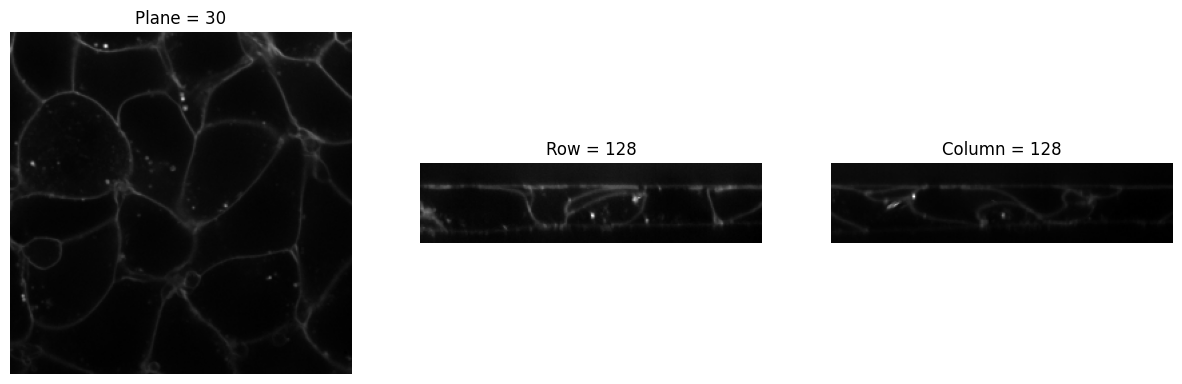

Output type: MetaTensor


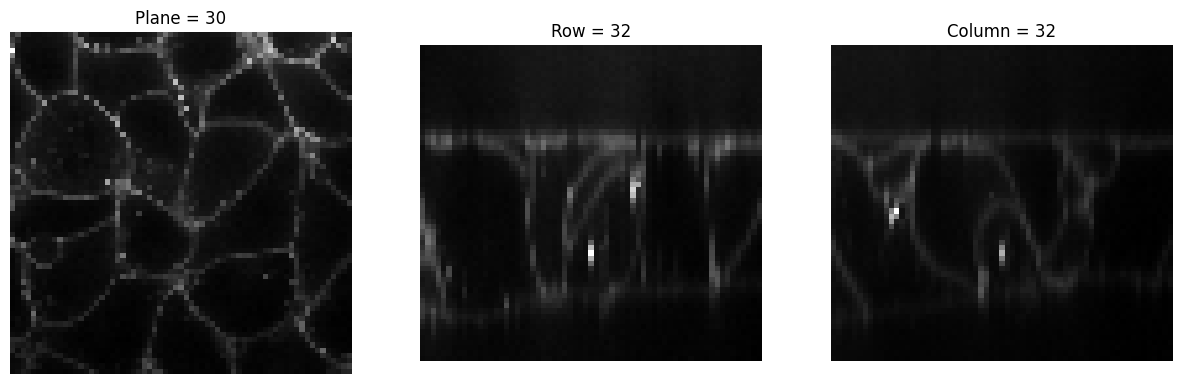

Output type: MetaTensor


/home/bm/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/monai/transforms/spatial/array.py:499: UserWarning: `data_array` is not of type MetaTensor, assuming affine to be identity.
  warnings.warn("`data_array` is not of type MetaTensor, assuming affine to be identity.")


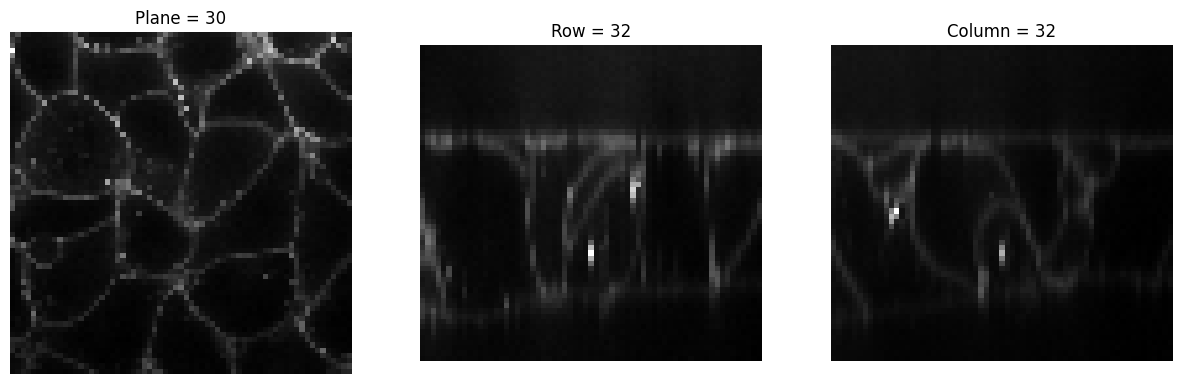

Output type: MetaTensor


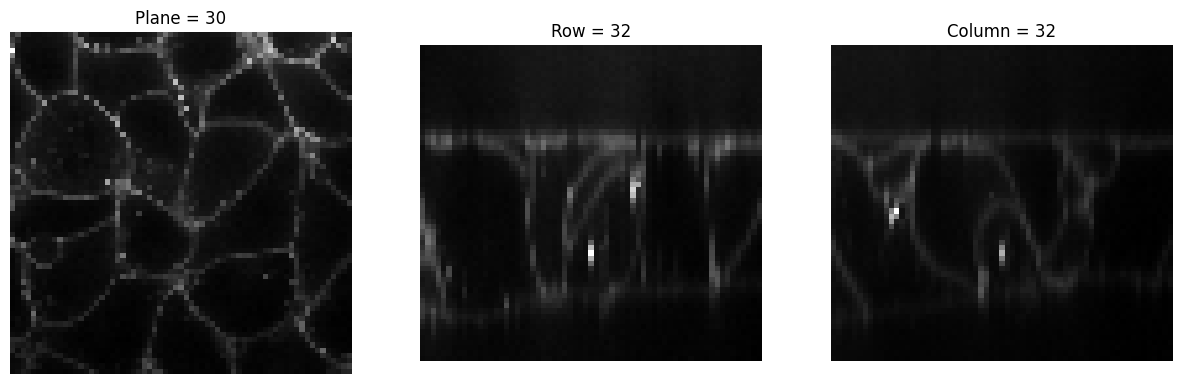

Output type: dict


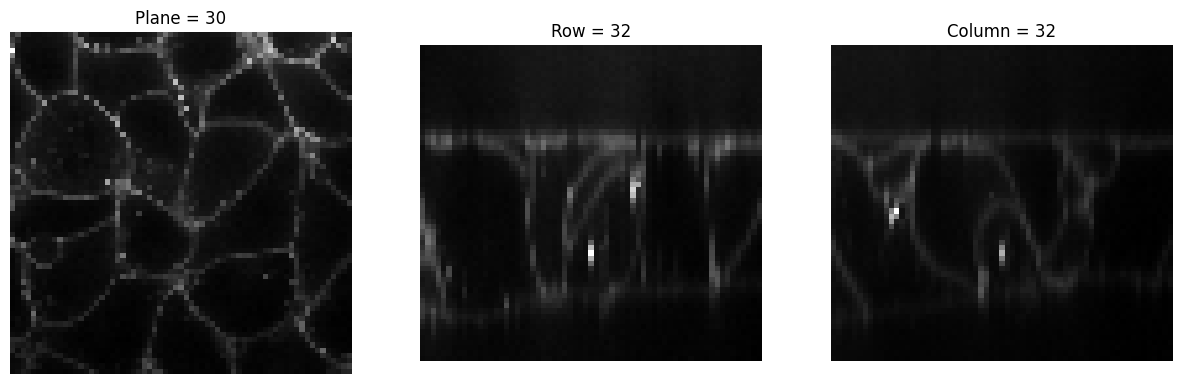

In [ ]:
# 1. Base initialization
img = BioVolume(torchTensor(cells3d()[:,0]))
print("Input")
show_slices(img, showlines=False)

# 2. Applying to a BioVolume structure
img2 = Resample(4)(img)
print("Output type:", type(img2).__name__)
show_slices(img2, showlines=False)

# 3. Applying to a raw multi-dimensional array
img2 = Resample(4)(cells3d()[:,0])
print("Output type:", type(img2).__name__)
show_slices(img2, showlines=False)

# 4. Applying to a MONAI MetaTensor
img2 = Resample(4)(MetaTensor(img))
print("Output type:", type(img2).__name__)
show_slices(img2, showlines=False)

# 5. Applying using the dictionary-based inference path
img2 = Resample(4, keys=["image"])({ "image": MetaTensor(img) })
print("Output type:", type(img2).__name__)
show_slices(img2['image'], showlines=False)

In [ ]:
#| hide

def test_resample_logic():
    # Test sampling parameter mapping
    tfm_samp = Resample(sampling=(2.0, 2.0), backend="monai")
    test_eq(isinstance(tfm_samp, mt.Spacing), True)
    test_eq(np.allclose(tfm_samp.pixdim, (2.0, 2.0)), True)
    
    # Test explicit pixdim fallback
    tfm_pix = Resample(pixdim=(1.0, 1.0, 1.0), backend="monai")
    test_eq(np.allclose(tfm_pix.pixdim, (1.0, 1.0, 1.0)), True)
    
    # Guard missing required parameters
    test_fail(
        lambda: Resample(backend="monai"), 
        contains="Provide either `sampling` or `pixdim`"
    )
    
    return "Passed"

test_eq(test_resample_logic(), "Passed")

#### `Resample` Class Attributes & Parameter Reference

This reference details the explicit configurations used to standardize structural dimensions across multi-modal scans.

**Returns:** A structural deterministic transformation pipeline calibrated to the requested execution `backend`.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`sampling`** | `tuple`, `float`, or `int` | `None` | The target voxel spacing dimensions (e.g., `4` or `(1.5, 1.5)`). Can be passed directly as the first positional argument. Automatically mapped to `pixdim` internally. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the creation of the dictionary-based transformation counterpart (`Spacingd`). |
| **`*args, **kwargs`** | `Any` | - | Arbitrary arguments and properties (such as `mode` for interpolation, or `pixdim` directly) forwarded to MONAI's foundational `Spacing` routine. |

In [ ]:
#| export 
class Spacing(MonaiTransform):
    """
    A wrapper around MONAI's Spacing transform that supports multiple input types and auto-infers dict transforms.

    """
    _monai_transform = mt.Spacing

    def __init__(
        self,
        pixdim=None,
        keys=None,
        **kwargs
    ):
       
        super().__init__(
            keys=keys,
            pixdim=pixdim,
            **kwargs
        )

In [ ]:
show_doc(Spacing)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L450){target="_blank" style="float:right; font-size:smaller"}

### Spacing

```python

def Spacing(
    pixdim:NoneType=None, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*A wrapper around MONAI's Spacing transform that supports multiple input types and auto-infers dict transforms.*

#### Example: Adjusting physical voxel spacing using the standard parameter convention


In [ ]:
# 1. Initialize the Spacing pipeline wrapper
spacing_tfm = Spacing(pixdim=(1.5, 1.5, 1.5))

# 2. Verify pipeline integration
print(f"Transform Instance: {type(spacing_tfm).__name__}")
print(f"Inherits from fastai Transform: {isinstance(spacing_tfm, Transform)}")

# 3. Generating a native MONAI operator via the backend switch
native_spacing = Spacing(pixdim=(2.0, 2.0), backend="monai")
print(f"Native Instance: {type(native_spacing).__name__}")

Transform Instance: Spacing
Inherits from fastai Transform: True
Native Instance: Spacing


In [ ]:
#| hide

def test_spacing_logic():
    # Transform inheritance (requires explicitly requesting the fastai wrapper)
    t = Spacing(1, backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception (native MONAI path)
    t_monai = Spacing(pixdim=(2, 2), backend="monai")
    test_eq(isinstance(t_monai, mt.Spacing), True)
    
    # Dict transform inference
    t_dict = Spacing(pixdim=(1, 1), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Spacingd), True)

    return "Passed"

test_eq(test_spacing_logic(), "Passed")

#### `Spacing` Class Attributes & Parameter Reference

This reference details the configurations used for physical coordinate and voxel dimension standardisation.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`pixdim`** | `tuple`, `float`, or `int` | `None` | The specific target physical voxel dimensions (e.g., `(1.0, 1.0, 1.0)`). Can be passed as the first positional argument. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the automated inference of the dictionary-based counterpart (`Spacingd`). |
| **`backend`** | `str` | `"monai"` | The execution context flag. Must be explicitly set to `"fastai"` to return the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional configurations forwarded to MONAI's core `Spacing` routine (e.g., `mode="bilinear"`, `align_corners=True`). |

In [ ]:
#| export
class Resize(MonaiTransform):
    """
    A wrapper around MONAI's Resize transform that supports multiple input types and auto-infers dict transforms.

    Args:
        size: output spatial size
        keys: keys for dict transforms (if applicable)
        **kwargs: additional arguments to pass to the underlying transform
    """
    _monai_transform = mt.Resize

    def __init__(
        self,
        spatial_size,        
        keys=None,
        **kwargs
    ):
        super().__init__(
            keys=keys,
            spatial_size=spatial_size,
            **kwargs
        )

In [ ]:
show_doc(Resize)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L471){target="_blank" style="float:right; font-size:smaller"}

### Resize

```python

def Resize(
    spatial_size, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*A wrapper around MONAI's Resize transform that supports multiple input types and auto-infers dict transforms.*

Args:
    size: output spatial size
    keys: keys for dict transforms (if applicable)
    **kwargs: additional arguments to pass to the underlying transform

#### Example: Forcing a specific absolute spatial dimension on a biological volume

Original Input Size: torch.Size([60, 256, 256])


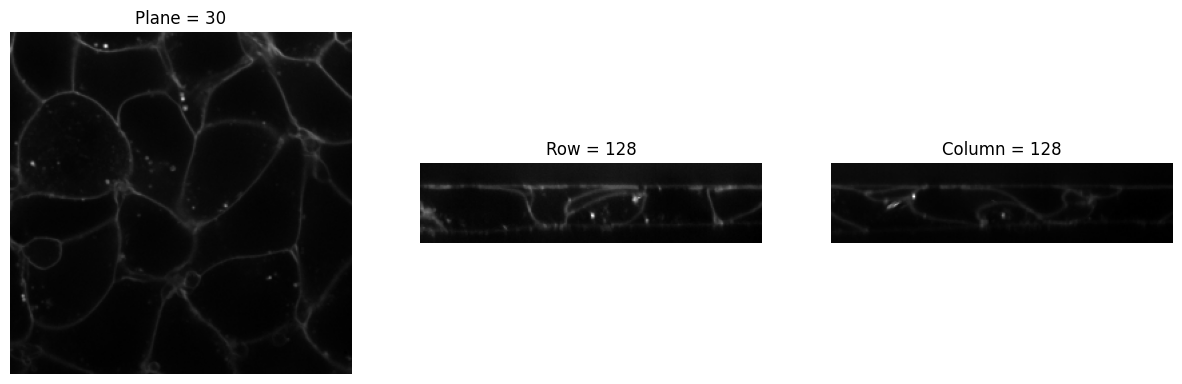

Resized Output Size: torch.Size([60, 50, 50])


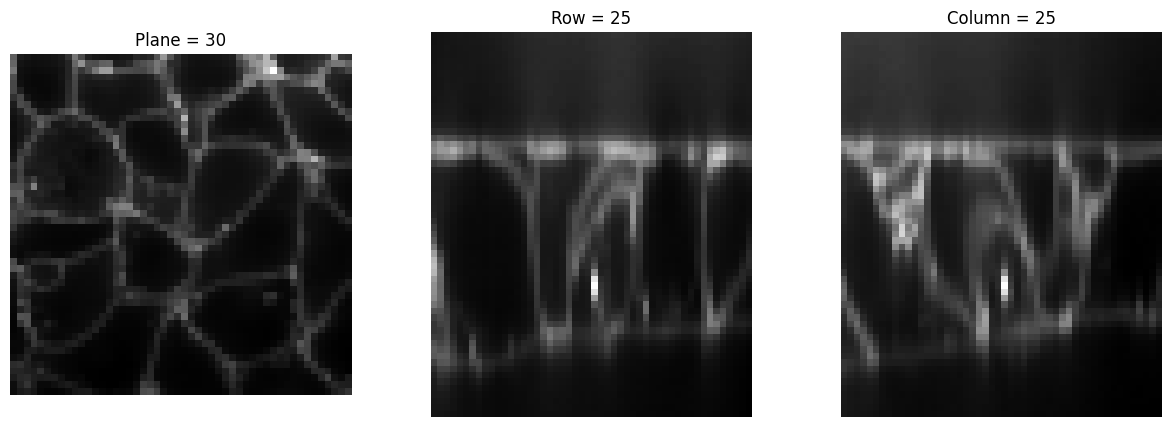

In [ ]:
# 1. Initialize the base volume
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply the Resize transform to forcefully interpolate to 50x50 spatial dimensions
# Note: The channel dimension remains untouched.
img2 = Resize((50, 50))(img)
print(f"Resized Output Size: {img2.shape}")
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_resize_logic():
    # Transform inheritance
    t = Resize((32, 32), backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception (Native MONAI path)
    t_monai = Resize((64, 64), backend="monai")
    test_eq(isinstance(t_monai, mt.Resize), True)
    
    # Dict transform inference
    t_dict = Resize((16, 16), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Resized), True)

    return "Passed"

test_eq(test_resize_logic(), "Passed")

#### `Resize` Class Attributes & Parameter Reference

This reference details the configurations used to force explicit target dimensions across multi-modal image arrays.

**Returns:** A dynamic fastai-compatible augmentation wrapper (`backend="fastai"`) or the native structural MONAI operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_size`** | `tuple` or `int` | *Required* | The absolute target spatial dimensions for the output tensor (e.g., `(50, 50)` or `(32, 32, 32)`). Passed as the first positional argument. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the automated inference of the dictionary-based counterpart (`Resized`). |
| **`backend`** | `str` | `"monai"` | The execution context flag. Set to `"fastai"` to return the stateful pipeline wrapper object. |
| **`**kwargs`** | `dict` | `{}` | Additional interpolation settings forwarded to MONAI's core `Resize` routine (e.g., `mode="area"`, `anti_aliasing=True`). |

In [ ]:
#| export
class Crop(MonaiTransform):
    """
    MONAI SpatialCrop wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (SpatialCropd auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.SpatialCrop

    def __init__(
        self,
        roi_center=None, 
        roi_size=None, 
        roi_start=None, 
        roi_end=None, 
        roi_slices=None,
        keys=None,
        **kwargs
    ):
        super().__init__(
            roi_center=roi_center,
            roi_size=roi_size,
            roi_start=roi_start,
            roi_end=roi_end,
            roi_slices=roi_slices,
            keys=keys,
            **kwargs
        )

In [ ]:
show_doc(Crop)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L495){target="_blank" style="float:right; font-size:smaller"}

### Crop

```python

def Crop(
    roi_center:NoneType=None, roi_size:NoneType=None, roi_start:NoneType=None, roi_end:NoneType=None,
    roi_slices:NoneType=None, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI SpatialCrop wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (SpatialCropd auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Performing a precise deterministic crop on a 2D slice

Original Input Size: torch.Size([60, 256, 256])


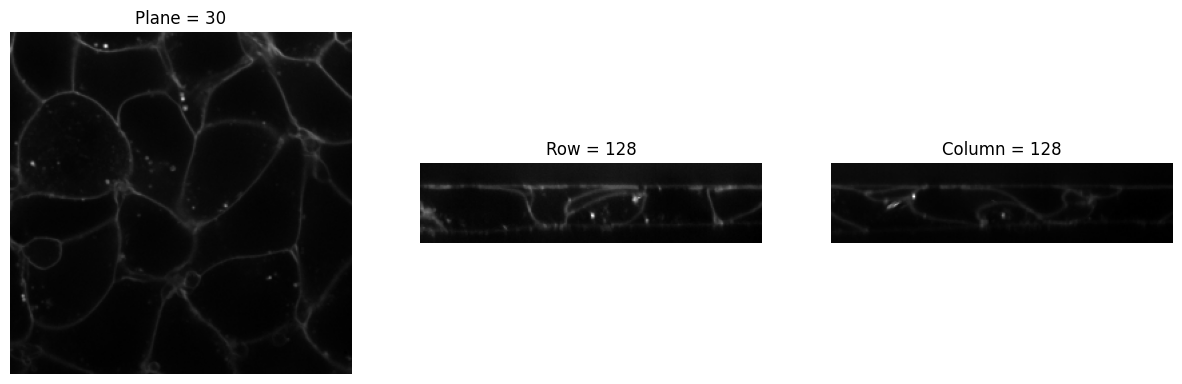

Cropped Output Size: torch.Size([60, 150, 150])


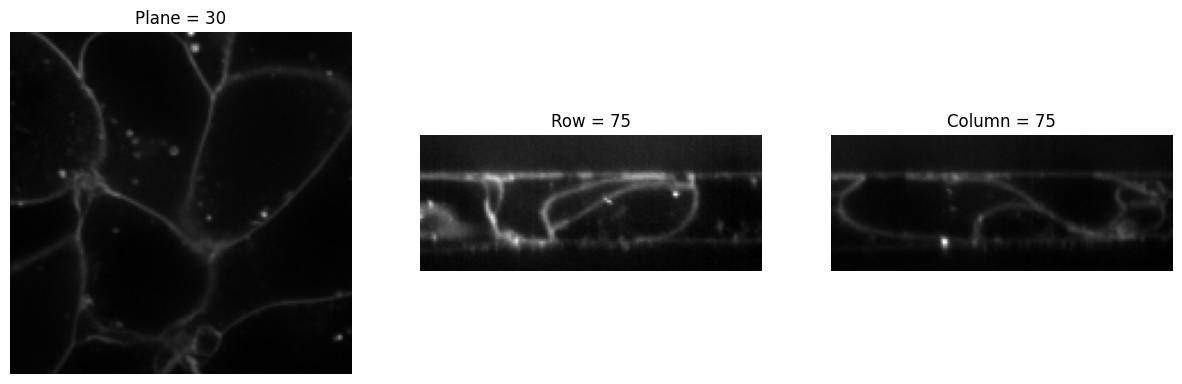

In [ ]:
# 1. Initialize the base image
# By slicing [:, 0], we extract a single 2D slice (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Extract a specific region using starting and ending coordinates
# Since our input is 2D (Y, X), we provide 2D coordinates.
crop_tfm = Crop(roi_start=(50, 50), roi_end=(200, 200))
img2 = crop_tfm(img)

print(f"Cropped Output Size: {img2.shape}")
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_crop_logic():
    # Transform inheritance
    t = Crop(roi_start=[0, 0], roi_end=[10, 10], backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to SpatialCrop
    t_monai = Crop(roi_start=[0, 0], roi_end=[10, 10], backend="monai")
    test_eq(isinstance(t_monai, mt.SpatialCrop), True)
    
    # Dict transform inference mapping to SpatialCropd
    t_dict = Crop(roi_start=[0, 0], roi_end=[10, 10], keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.SpatialCropd), True)

    return "Passed"

test_eq(test_crop_logic(), "Passed")

#### `Crop` Class Attributes & Parameter Reference

This reference details the configurations used to explicitly define bounding boxes for spatial extractions. 

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`roi_center`** | `tuple` or `list` | `None` | Voxel coordinates representing the center of the target crop region. |
| **`roi_size`** | `tuple` or `list` | `None` | The spatial extent (dimensions) of the bounding box to be extracted. |
| **`roi_start`** | `tuple` or `list` | `None` | Voxel coordinates for the starting corner of the bounding box. |
| **`roi_end`** | `tuple` or `list` | `None` | Voxel coordinates for the ending corner of the bounding box. |
| **`roi_slices`** | `tuple` of `slice` | `None` | Explicit Python slice objects defining the exact extraction region. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`SpatialCropd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |

In [ ]:
#| export
class SpatialCrop(MonaiTransform):
    """
    MONAI SpatialCrop wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (SpatialCropd auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.SpatialCrop

    def __init__(
        self,
        roi_center=None, 
        roi_size=None, 
        roi_start=None, 
        roi_end=None, 
        roi_slices=None,
        keys=None,
        **kwargs
    ):
        super().__init__(
            roi_center=roi_center,
            roi_size=roi_size,
            roi_start=roi_start,
            roi_end=roi_end,
            roi_slices=roi_slices,
            keys=keys,
            **kwargs
        )

In [ ]:
show_doc(SpatialCrop)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L528){target="_blank" style="float:right; font-size:smaller"}

### SpatialCrop

```python

def SpatialCrop(
    roi_center:NoneType=None, roi_size:NoneType=None, roi_start:NoneType=None, roi_end:NoneType=None,
    roi_slices:NoneType=None, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI SpatialCrop wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (SpatialCropd auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Targeting a specific anatomical region using a center coordinate and bounding box

Original Input Size: torch.Size([60, 256, 256])


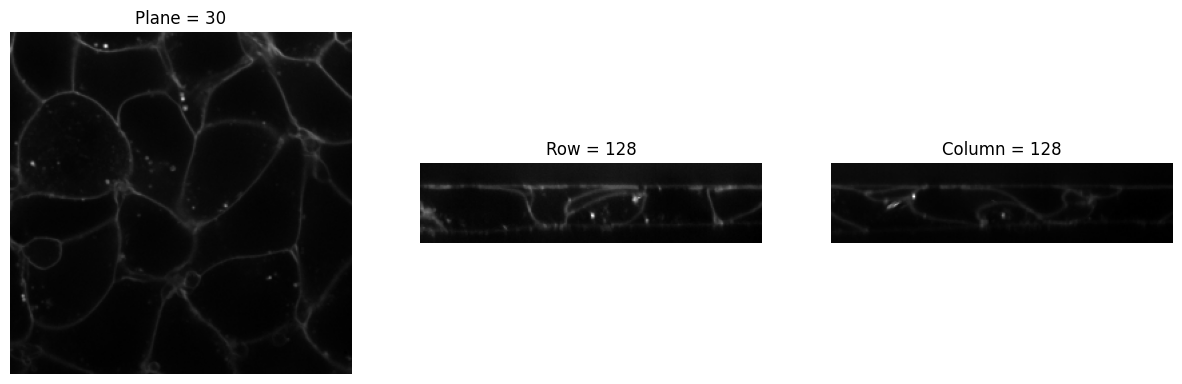

Cropped Output Size: torch.Size([60, 100, 100])


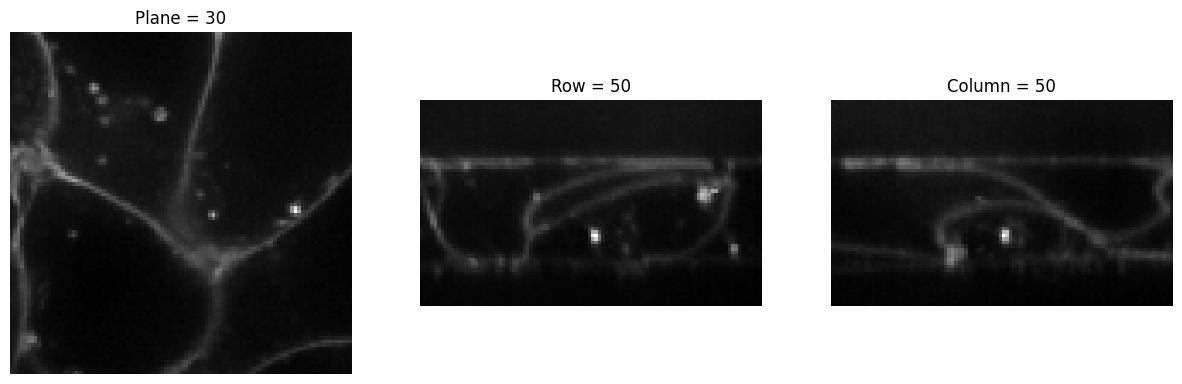

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Extract a specific patch around a central point
# Providing 2D coordinates for the center (Y, X) and the bounding box size (Y, X).
spatial_crop_tfm = SpatialCrop(roi_center=(128, 128), roi_size=(100, 100))
img2 = spatial_crop_tfm(img)

print(f"Cropped Output Size: {img2.shape}")
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_spatial_crop_logic():
    # Transform inheritance
    t = SpatialCrop(roi_center=[10, 10], roi_size=[5, 5], backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to SpatialCrop
    t_monai = SpatialCrop(roi_center=[10, 10], roi_size=[5, 5], backend="monai")
    test_eq(isinstance(t_monai, mt.SpatialCrop), True)
    
    # Dict transform inference mapping to SpatialCropd
    t_dict = SpatialCrop(roi_center=[10, 10], roi_size=[5, 5], keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.SpatialCropd), True)

    return "Passed"

test_eq(test_spatial_crop_logic(), "Passed")

#### `SpatialCrop` Class Attributes & Parameter Reference

This reference details the configurations used to explicitly define bounding boxes for spatial extractions. 

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`roi_center`** | `tuple` or `list` | `None` | Voxel coordinates representing the center point of the target crop region. |
| **`roi_size`** | `tuple` or `list` | `None` | The specific spatial extent (dimensions) of the bounding box to be extracted. |
| **`roi_start`** | `tuple` or `list` | `None` | Voxel coordinates for the starting corner of the bounding box. |
| **`roi_end`** | `tuple` or `list` | `None` | Voxel coordinates for the ending corner of the bounding box. |
| **`roi_slices`** | `tuple` of `slice` | `None` | Explicit Python slice objects defining the exact extraction region. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`SpatialCropd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the stateful pipeline wrapper. |

In [ ]:
#| export
class CenterSpatialCrop(MonaiTransform):
    """
    MONAI CenterSpatialCrop wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (CenterSpatialCropd auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.CenterSpatialCrop

    def __init__(
        self,
        roi_size=None,
        keys=None,
        **kwargs,
    ):
        """
        roi_size:
            - int → broadcast to all spatial dims
            - tuple/list → target spatial size
        """

        self.roi_size = roi_size

        super().__init__(
            keys=keys,
            roi_size=roi_size,   # MONAI expects this arg
            **kwargs,
        )

In [ ]:
show_doc(CenterSpatialCrop)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L561){target="_blank" style="float:right; font-size:smaller"}

### CenterSpatialCrop

```python

def CenterSpatialCrop(
    roi_size:NoneType=None, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI CenterSpatialCrop wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (CenterSpatialCropd auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Automatically cropping a central patch from a biological image

Original Input Size: torch.Size([60, 256, 256])


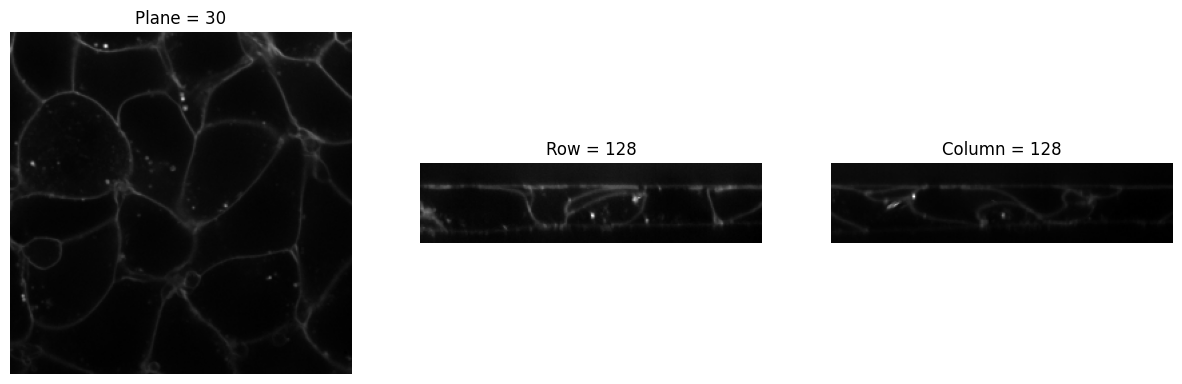

Cropped Output Size: torch.Size([60, 100, 100])


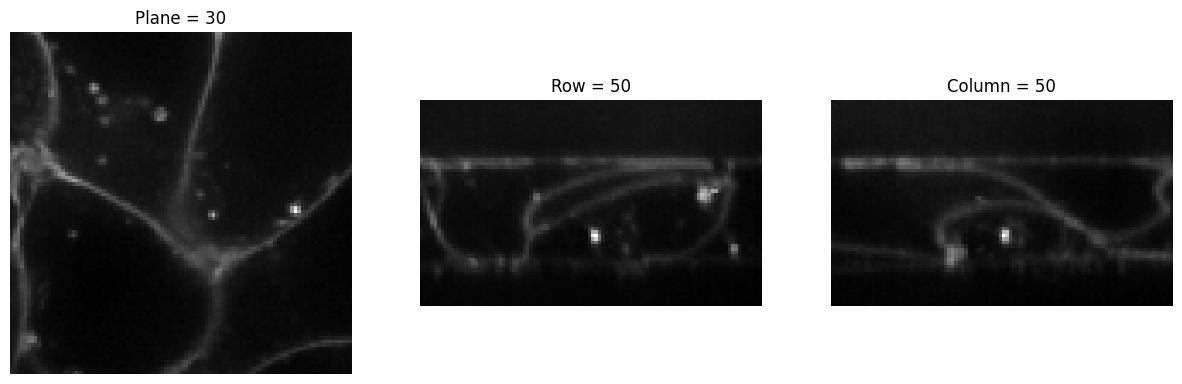

In [ ]:
# 1. Initialize the base image
# By slicing [:, 0], we extract a single 2D slice (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Extract a centered region
# Since our input is 2D, we provide a 2D roi_size (Y, X).
# We could also just pass `roi_size=100` and it would broadcast automatically.
center_crop_tfm = CenterSpatialCrop(roi_size=(100, 100))
img2 = center_crop_tfm(img)

print(f"Cropped Output Size: {img2.shape}")
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_center_spatial_crop_logic():
    # Transform inheritance
    t = CenterSpatialCrop(roi_size=16, backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to CenterSpatialCrop
    t_monai = CenterSpatialCrop(roi_size=(32, 32), backend="monai")
    test_eq(isinstance(t_monai, mt.CenterSpatialCrop), True)
    
    # Dict transform inference mapping to CenterSpatialCropd
    t_dict = CenterSpatialCrop(roi_size=32, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.CenterSpatialCropd), True)

    return "Passed"

test_eq(test_center_spatial_crop_logic(), "Passed")

#### `CenterSpatialCrop` Class Attributes & Parameter Reference

This reference details the configurations used to dynamically extract center-aligned regions from spatial arrays.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`roi_size`** | `tuple`, `list`, or `int` | `None` | The dimensions of the target bounding box. If an `int` is passed, it broadcasts isotropically across all spatial axes. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`CenterSpatialCropd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties passed directly to the MONAI base operator. |

In [ ]:
#| export
class CropForeground(MonaiTransform):
    """
    MONAI CropForeground wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (CropForeground*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.CropForeground

In [ ]:
show_doc(CropForeground)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L594){target="_blank" style="float:right; font-size:smaller"}

### CropForeground

```python

def CropForeground(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI CropForeground wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (CropForeground*d auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Dynamically removing black background borders from an image

Original Input Size: torch.Size([60, 256, 256])


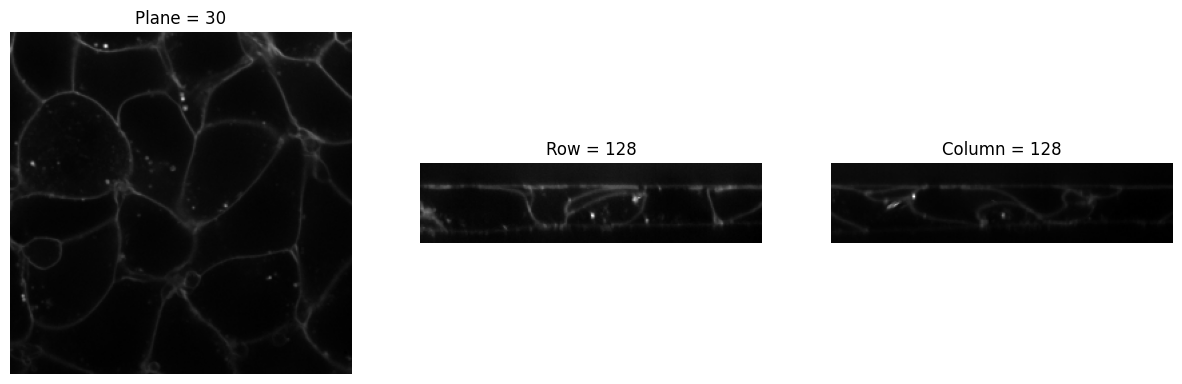

Foreground Cropped Size: torch.Size([60, 266, 266])


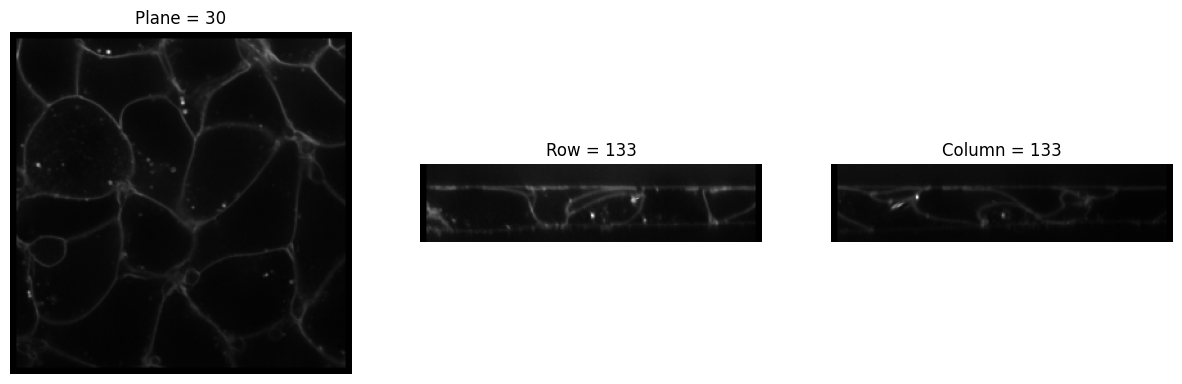

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Extract the foreground dynamically
# By default, MONAI considers any pixel > 0 as foreground.
# We can add a spatial margin (e.g., 5 pixels) around the detected bounding box.
crop_fg_tfm = CropForeground(margin=5)
img2 = crop_fg_tfm(img)

print(f"Foreground Cropped Size: {img2.shape}")
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_crop_foreground_logic():
    # Transform inheritance
    t = CropForeground(margin=1, backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to CropForeground
    t_monai = CropForeground(margin=2, backend="monai")
    test_eq(isinstance(t_monai, mt.CropForeground), True)
    
    # Dict transform inference mapping to CropForegroundd
    # Note: CropForegroundd strictly requires 'source_key' to compute the bounding box.
    t_dict = CropForeground(keys=["image", "label"], source_key="image", margin=1, backend="monai")
    test_eq(isinstance(t_dict, mt.CropForegroundd), True)

    return "Passed"

test_eq(test_crop_foreground_logic(), "Passed")

#### `CropForeground` Class Attributes & Parameter Reference

This reference details the configurations used to dynamically isolate active signal regions from background noise.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native dynamic cropping operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`select_fn`** | `callable` | `lambda x: x > 0` | A function that evaluates the tensor to identify foreground voxels (returns a boolean array). Passed via `**kwargs`. |
| **`margin`** | `int` or `tuple` | `0` | Extra padding/margin to retain around the calculated foreground bounding box. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Identifiers triggering the dictionary-based counterpart (`CropForegroundd`). |
| **`source_key`** | `str` | `None` | **Required if using `keys`.** Tells MONAI which dictionary key to evaluate to calculate the cropping bounding box. Passed via `**kwargs`. |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties passed directly to the MONAI base operator (e.g., `allow_smaller`, `return_coords`). |

In [ ]:
#| export
class BoundingRect(MonaiTransform):
    """
    MONAI BoundingRect wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (BoundingRect*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.BoundingRect

In [ ]:
show_doc(BoundingRect)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L607){target="_blank" style="float:right; font-size:smaller"}

### BoundingRect

```python

def BoundingRect(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI BoundingRect wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (BoundingRect*d auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Calculating the bounding box coordinates of an active signal

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")

# 2. Extract bounding rectangle coordinates
# By default, it finds the absolute limits of all pixels > 0.
# It returns a set of [min, max] coordinates for each spatial dimension.
bbox_tfm = BoundingRect()
coords = bbox_tfm(img)

print(f"Computed Bounding Box Coordinates [[Y_min, Y_max], [X_min, X_max]]:\n{coords}")

Original Input Size: torch.Size([60, 256, 256])
Computed Bounding Box Coordinates [[Y_min, Y_max], [X_min, X_max]]:
[[  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256 

In [ ]:
#| hide

def test_bounding_rect_logic():
    # Transform inheritance
    t = BoundingRect(backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping
    t_monai = BoundingRect(backend="monai")
    test_eq(isinstance(t_monai, mt.BoundingRect), True)
    
    # Dict transform inference
    # Note: BoundingRectd will evaluate the provided keys and output the coordinates
    # to a new key internally suffixed with '_bbox' (e.g., 'image_bbox').
    t_dict = BoundingRect(keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.BoundingRectd), True)

    return "Passed"

test_eq(test_bounding_rect_logic(), "Passed")

#### `BoundingRect` Class Attributes & Parameter Reference

This reference details the configurations used to analyze and extract the spatial coordinate limits of active regions.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`select_fn`** | `callable` | `lambda x: x > 0` | A function to evaluate which pixels belong to the foreground. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Identifiers triggering the dictionary counterpart (`BoundingRectd`). |
| **`bbox_key_postfix`** | `str` | `"bbox"` | **Only applicable if using `keys`.** The string appended to the original key to store the resulting coordinates in the dictionary (e.g., `"image_bbox"`). Passed via `**kwargs`. |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [ ]:
#| export
class CenterScaleCrop(MonaiTransform):
    """
    MONAI CenterScaleCrop wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (CenterScaleCrop*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.CenterScaleCrop

    def __init__(
        self,
        roi_scale=1.0,
        keys=None,
        **kwargs,
    ):

        self.roi_scale = roi_scale

        super().__init__(
            keys=keys,
            roi_scale=roi_scale, 
            **kwargs,
        )

In [ ]:
show_doc(CenterScaleCrop)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L620){target="_blank" style="float:right; font-size:smaller"}

### CenterScaleCrop

```python

def CenterScaleCrop(
    roi_scale:float=1.0, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI CenterScaleCrop wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (CenterScaleCrop*d auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Proportionally cropping the central 50% of an image

Original Input Size: torch.Size([60, 256, 256])


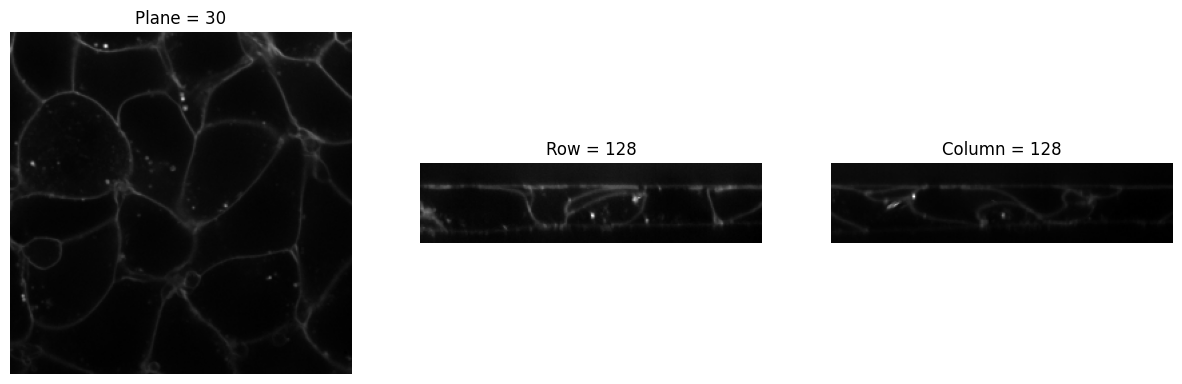

Proportionally Cropped Output Size: torch.Size([60, 128, 128])


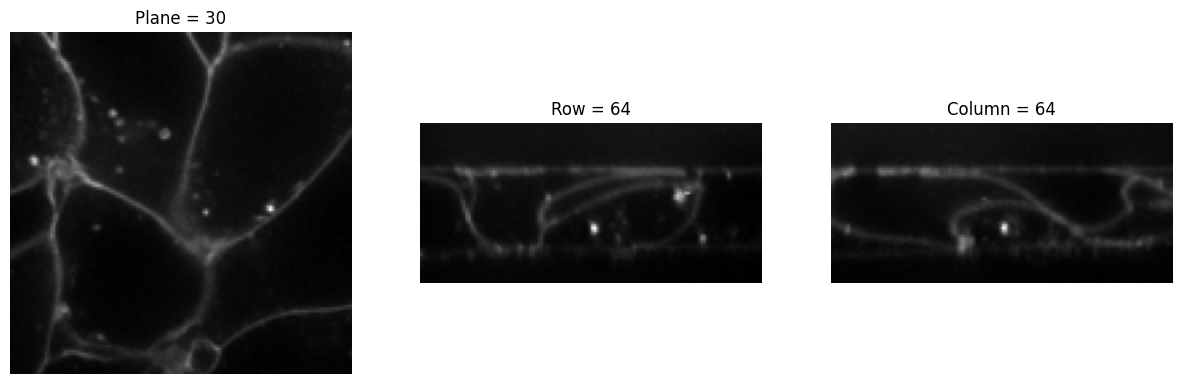

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Extract a proportionally scaled center region
# Passing 0.5 means we want to crop the central region covering exactly 50% 
# of the original spatial dimensions (Y and X).
scale_crop_tfm = CenterScaleCrop(roi_scale=0.5)
img2 = scale_crop_tfm(img)

print(f"Proportionally Cropped Output Size: {img2.shape}")
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_center_scale_crop_logic():
    # Transform inheritance
    t = CenterScaleCrop(roi_scale=0.8, backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to CenterScaleCrop
    t_monai = CenterScaleCrop(roi_scale=(0.5, 0.5), backend="monai")
    test_eq(isinstance(t_monai, mt.CenterScaleCrop), True)
    
    # Dict transform inference mapping to CenterScaleCropd
    t_dict = CenterScaleCrop(roi_scale=0.5, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.CenterScaleCropd), True)

    return "Passed"

test_eq(test_center_scale_crop_logic(), "Passed")

#### `CenterScaleCrop` Class Attributes & Parameter Reference

This reference details the configurations used to dynamically extract proportional regions based on original array sizes.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`roi_scale`** | `tuple`, `list`, or `float` | `1.0` | The fractional scale of the original size to extract. For example, `0.5` extracts the central 50% region. A single float broadcasts to all spatial axes. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`CenterScaleCropd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties passed directly to the MONAI base operator. |

In [ ]:
#| export

class CropND(fastTransform):
    """
    Crops an ND tensor along a specified dimension.

    This transform crops an ND tensor along specified dimensions, which could be a channel or spatial dimension.
    """
    
    def __init__(self, 
                 slices: list, # List of slice objects or tuples (start, end) for each dimension
                 dims: list = None, # List of dimensions to apply the slices. If None, slices are applied to all dimensions.
                 ):
        self.slices = [slice(*s) if isinstance(s, tuple) else s for s in slices]
        self.dims = dims
        
    def encodes(self, x: BioImageBase):
        """Apply cropping to a BioImageBase object."""
        bioimagetype = type(x)
        slices = [slice(None)] * x.ndim
        if self.dims is None:
            for i, s in enumerate(self.slices):
                if x.shape[i] >= s.stop - s.start:
                    slices[i] = s
        else:
            for dim, s in zip(self.dims, self.slices):
                if x.shape[dim] >= s.stop - s.start:
                    slices[dim] = s
        return bioimagetype(x[tuple(slices)])
    
    def encodes(self, x: np.ndarray):
        """Apply cropping to a NumPy array."""
        slices = [slice(None)] * x.ndim
        if self.dims is None:
            for i, s in enumerate(self.slices):
                if x.shape[i] >= s.stop - s.start:
                    slices[i] = s
        else:
            for dim, s in zip(self.dims, self.slices):
                if x.shape[dim] >= s.stop - s.start:
                    slices[dim] = s
        return x[tuple(slices)]

In [ ]:
show_doc(CropND)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L648){target="_blank" style="float:right; font-size:smaller"}

### CropND

```python

def CropND(
    slices:list, # List of slice objects or tuples (start, end) for each dimension
    dims:list=None, # List of dimensions to apply the slices. If None, slices are applied to all dimensions.
):


```

*Crops an ND tensor along a specified dimension.*

This transform crops an ND tensor along specified dimensions, which could be a channel or spatial dimension.

#### Example: Slicing specific dimensions natively via CropND

Original Input Size: torch.Size([60, 256, 256])


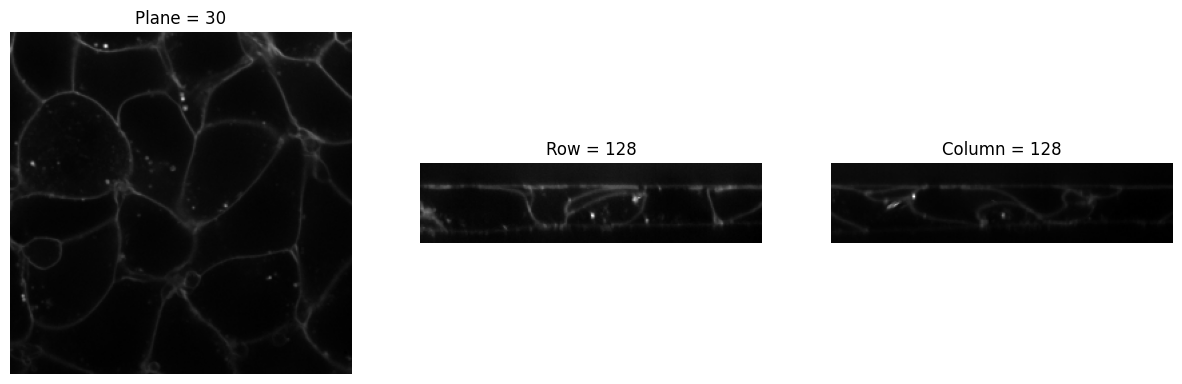

Sequentially Cropped Size:
torch.Size([20, 256, 256])


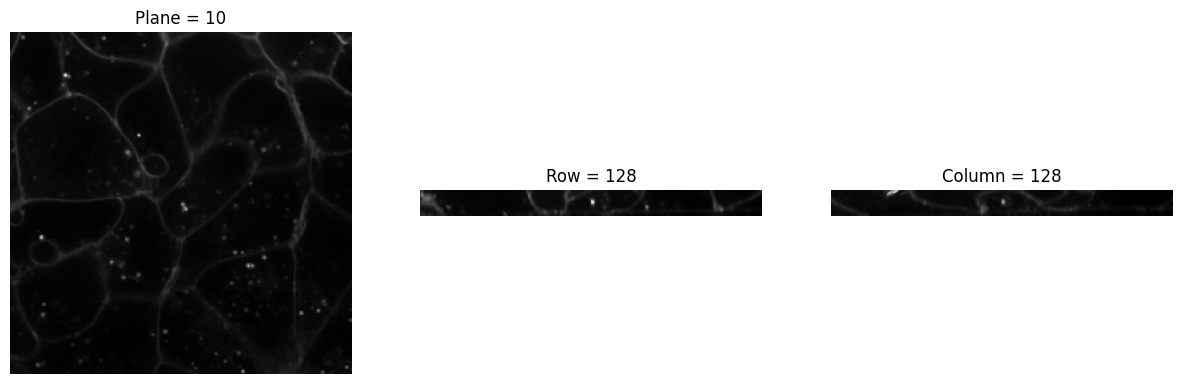

Targeted Cropped Size:
torch.Size([20, 256, 40])


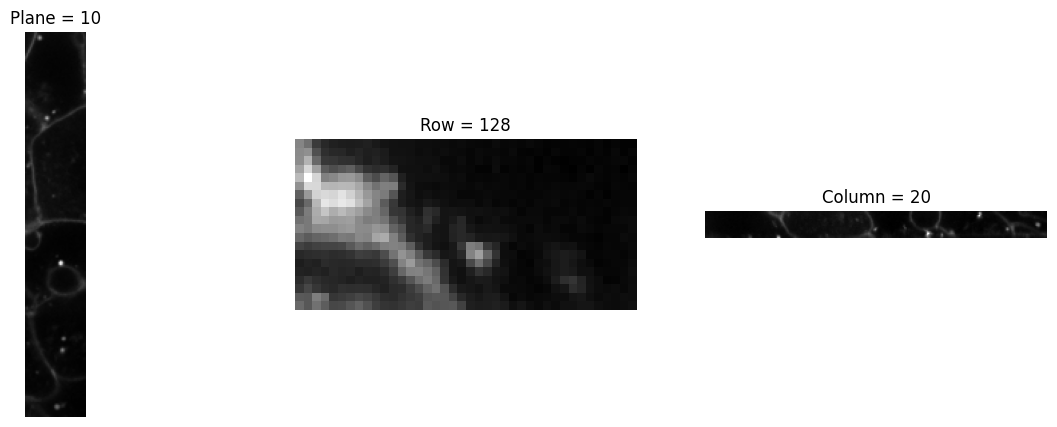

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# --- Scenario A: Sequential Cropping ---
# Define the slices for cropping (applied to the first dimension)
slices = [(30, 50)]

# Create an instance of CropND
crop_transform = CropND(slices=slices)

img3 = crop_transform(img)
print(f"Sequentially Cropped Size:")
print(img3.size())
show_slices(img3, showlines=False)


# --- Scenario B: Dimension-Targeted Cropping ---
# Define the slices for cropping
slices = [(30, 50), (0, 40)]
dims = [0, 2]
# Create an instance of CropND
crop_transform = CropND(slices=slices, dims=dims)

img4 = crop_transform(img)
print(f"Targeted Cropped Size:")
print(img4.size())
show_slices(img4, showlines=False)

In [ ]:
#| hide

def test_crop_nd_logic():
    # Create a dummy 3D array [C, Y, X] -> shape (5, 50, 50)
    dummy_data = np.zeros((5, 50, 50))
    
    # Test sequential slicing (dims=None)
    # Should slice dimension 0 from 1 to 4 -> length 3
    t_seq = CropND(slices=[(1, 4)])
    res_seq = t_seq(dummy_data)
    test_eq(res_seq.shape, (3, 50, 50))
    
    # Test dimension-targeted slicing
    # Should slice dim 1 (Y) to length 20, and dim 2 (X) to length 10
    t_dim = CropND(slices=[(10, 30), (0, 10)], dims=[1, 2])
    res_dim = t_dim(dummy_data)
    test_eq(res_dim.shape, (5, 20, 10))
    
    # Test protective mechanism (slice size > shape)
    # If requested slice is larger than dimension, it should ignore the slice
    t_protect = CropND(slices=[(0, 100)], dims=[1])
    res_protect = t_protect(dummy_data)
    test_eq(res_protect.shape, (5, 50, 50)) # Shape remains unchanged

    return "Passed"

test_eq(test_crop_nd_logic(), "Passed")

#### `CropND` Class Attributes & Parameter Reference

This reference details the configurations used for native, N-dimensional tensor slicing.

**Returns:** A sliced tensor matching the incoming data type (`BioImageBase` or `np.ndarray`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`slices`** | `list` | *Required* | A list of explicit Python `slice` objects or `(start, end)` tuples defining the boundaries for the crop. |
| **`dims`** | `list[int]` or `None` | `None` | The specific integer axes corresponding to each slice. If `None`, slices are applied sequentially starting from axis `0`. |

In [ ]:
#| export
class Pad(MonaiTransform):
    """
    MONAI Pad wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Padd auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Pad

    @classmethod
    def _create_dict_transform(cls, keys, *args, **kwargs):
        # MONAI's Padd is an architectural exception: it requires an instantiated 
        # 'padder' object rather than raw arguments like 'to_pad'.
        padder_obj = cls._monai_transform(*args, **kwargs)
        
        # Extract 'mode' if provided, as Padd also expects it at the dict level
        mode = kwargs.get("mode", "constant")
        
        return mt.Padd(keys=keys, padder=padder_obj, mode=mode)

In [ ]:
show_doc(Pad)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L690){target="_blank" style="float:right; font-size:smaller"}

### Pad

```python

def Pad(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI Pad wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (Padd auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Adding explicit borders to an image

Original Input Size: torch.Size([60, 256, 256])


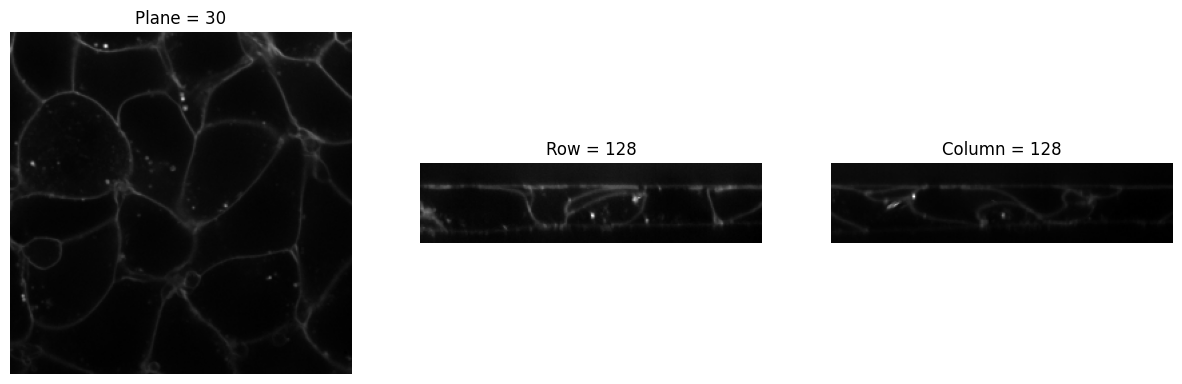

Padded Output Size:
torch.Size([60, 316, 316])


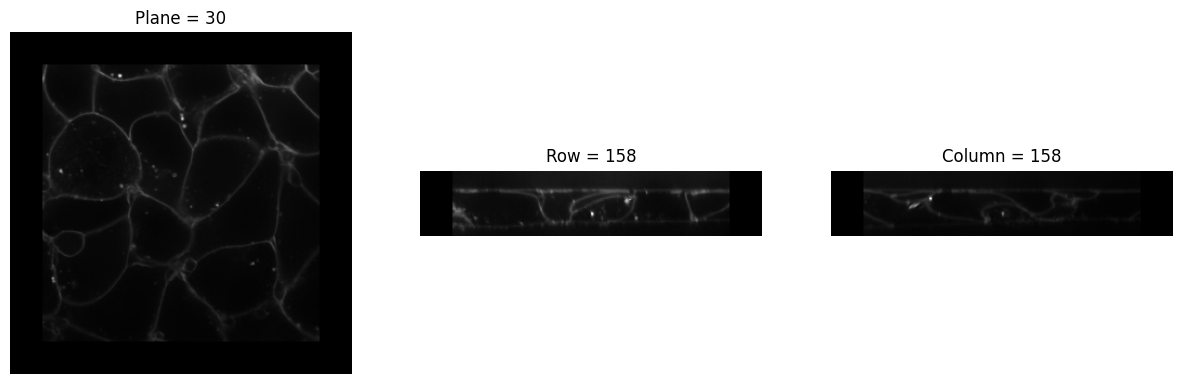

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Add symmetric padding to the spatial dimensions
# 'to_pad' expects a tuple of (pad_before, pad_after) for each dimension.
# Our shape is [Channels, Y, X]. We add 0 padding to Channels, 
# and 30 pixels of padding before and after the Y and X axes.
pad_tfm = Pad(to_pad=[(0, 0), (30, 30), (30, 30)])
img2 = pad_tfm(img)

print(f"Padded Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_pad_logic():
    # Transform inheritance
    t = Pad(to_pad=[(1, 1), (2, 2)], backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to Pad
    t_monai = Pad(to_pad=[(1, 1)], backend="monai")
    test_eq(isinstance(t_monai, mt.Pad), True)
    
    # Dict transform inference mapping to Padd
    t_dict = Pad(to_pad=[(1, 1)], keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Padd), True)

    return "Passed"

test_eq(test_pad_logic(), "Passed")

#### `Pad` Class Attributes & Parameter Reference

This reference details the explicit configurations used to expand tensor margins.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`to_pad`** | `list` of `tuple` | *Required* | A sequence of `(pad_before, pad_after)` integer pairs for each dimension of the input tensor. Passed via `**kwargs`. |
| **`mode`** | `str` | `"constant"` | The padding strategy to apply. Options typically include `"constant"`, `"reflect"`, `"replicate"`, or `"circular"`. Passed via `**kwargs`. |
| **`value`** | `float` or `int` | `0` | The fill value to use if `mode="constant"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Padd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |

In [ ]:
#| export
class SpatialPad(MonaiTransform):
    """
    MONAI SpatialPad wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (SpatialPad*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.SpatialPad

    def __init__(
        self,
        spatial_size,
        keys=None,
        **kwargs,
    ):
        self.spatial_size = spatial_size

        super().__init__(
            keys=keys,
            spatial_size=spatial_size, 
            **kwargs,
        )

In [ ]:
show_doc(SpatialPad)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L714){target="_blank" style="float:right; font-size:smaller"}

### SpatialPad

```python

def SpatialPad(
    spatial_size, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI SpatialPad wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (SpatialPad*d auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Smartly padding an image to guarantee a minimum absolute spatial shape

Original Input Size: torch.Size([60, 256, 256])


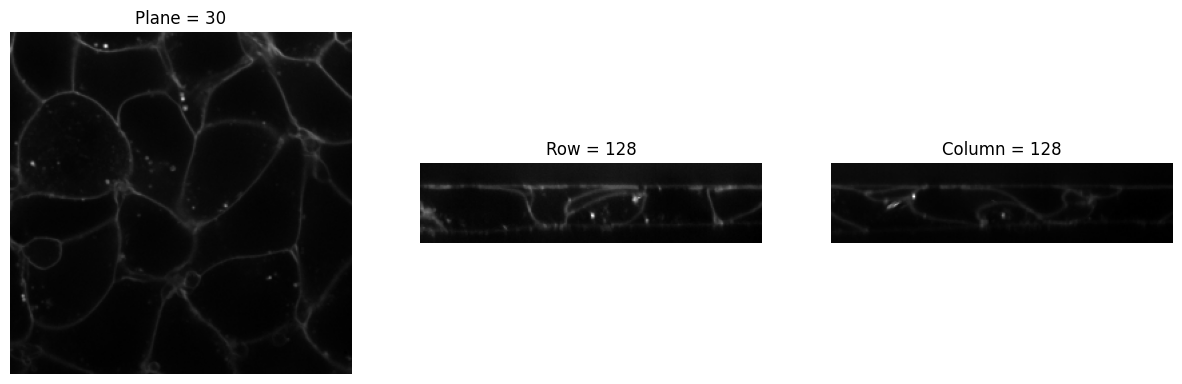

Spatially Padded Output Size:
torch.Size([60, 300, 300])


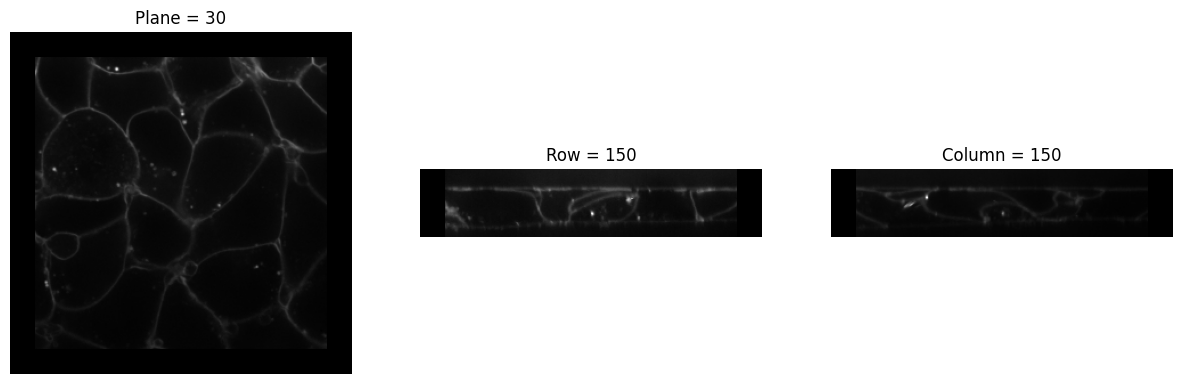

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Pad the image to a guaranteed absolute size
# We pass a target 2D spatial size (Y, X). For instance, if the original image 
# is 256x256, setting spatial_size to (300, 300) will add padding to reach it.
# By default, it pads symmetrically around the center.
spatial_pad_tfm = SpatialPad(spatial_size=(300, 300))
img2 = spatial_pad_tfm(img)

print(f"Spatially Padded Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_spatial_pad_logic():
    # Transform inheritance
    t = SpatialPad(spatial_size=(64, 64), backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to SpatialPad
    t_monai = SpatialPad(spatial_size=(32, 32), backend="monai")
    test_eq(isinstance(t_monai, mt.SpatialPad), True)
    
    # Dict transform inference mapping to SpatialPadd
    t_dict = SpatialPad(spatial_size=(32, 32), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.SpatialPadd), True)

    return "Passed"

test_eq(test_spatial_pad_logic(), "Passed")

#### `SpatialPad` Class Attributes & Parameter Reference

This reference details the configurations used to smartly guarantee minimum tensor shapes.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_size`** | `tuple`, `list`, or `int` | *Required* | The absolute target spatial dimensions for the output tensor (e.g., `(300, 300)`). Passed as the first positional argument. |
| **`method`** | `str` | `"symmetric"` | The padding method to calculate the margins. Options include `"symmetric"` (centers the image) or `"end"` (pads only at the right/bottom). Passed via `**kwargs`. |
| **`mode`** | `str` | `"constant"` | The value-filling strategy. Options include `"constant"`, `"reflect"`, `"replicate"`, or `"circular"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`SpatialPadd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [ ]:
#| export
class BorderPad(MonaiTransform):
    """
    MONAI BorderPad wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (BorderPad*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.BorderPad

    def __init__(
        self,
        spatial_border,
        keys=None,
        **kwargs,
    ):
        self.border_size = spatial_border

        super().__init__(
            keys=keys,
            spatial_border=spatial_border, 
            **kwargs,
        )

In [ ]:
show_doc(BorderPad)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L741){target="_blank" style="float:right; font-size:smaller"}

### BorderPad

```python

def BorderPad(
    spatial_border, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI BorderPad wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (BorderPad*d auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Adding a uniform margin around the entire spatial boundary

Original Input Size: torch.Size([60, 256, 256])


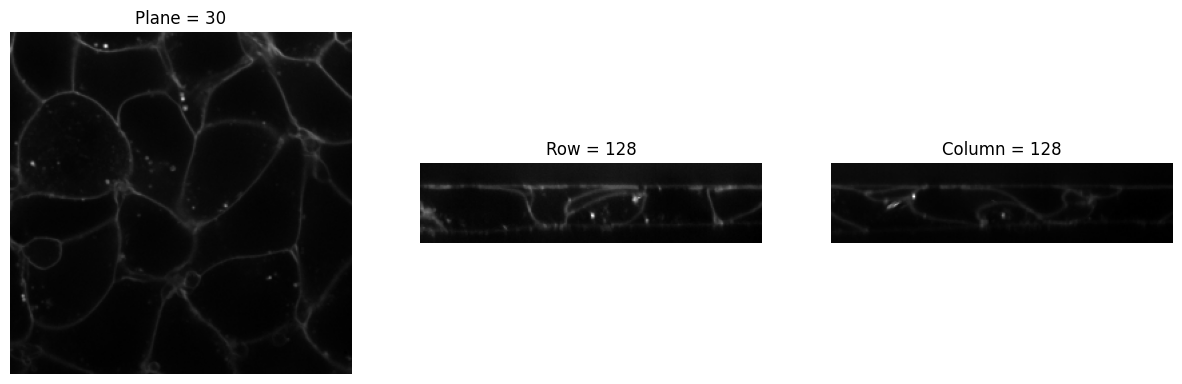

Border-Padded Output Size:
torch.Size([60, 296, 296])


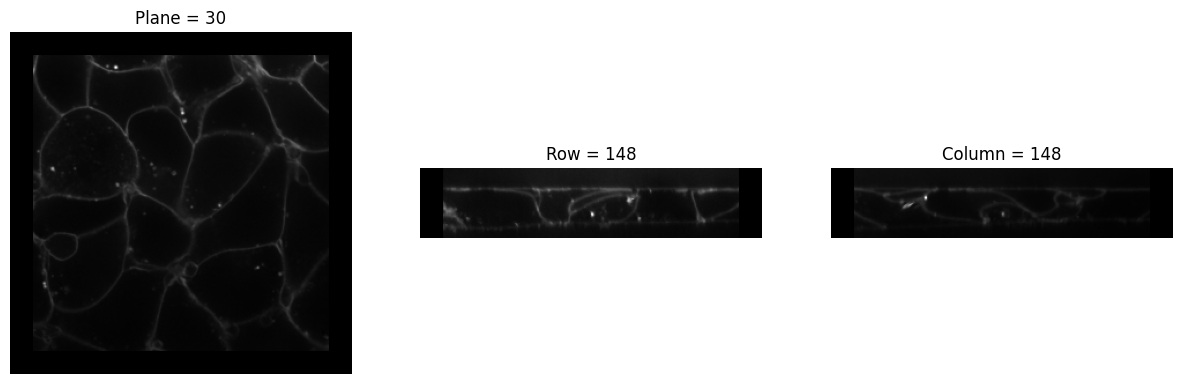

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply a uniform border pad
# Passing an integer adds that exact amount of padding to both sides 
# of all spatial dimensions. (e.g., +20 pixels to top, bottom, left, and right).
border_pad_tfm = BorderPad(spatial_border=20)
img2 = border_pad_tfm(img)

print(f"Border-Padded Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_border_pad_logic():
    # Transform inheritance
    t = BorderPad(spatial_border=10, backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to BorderPad
    t_monai = BorderPad(spatial_border=5, backend="monai")
    test_eq(isinstance(t_monai, mt.BorderPad), True)
    
    # Dict transform inference mapping to BorderPadd
    t_dict = BorderPad(spatial_border=5, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.BorderPadd), True)

    return "Passed"

test_eq(test_border_pad_logic(), "Passed")

#### `BorderPad` Class Attributes & Parameter Reference

This reference details the configurations used to dynamically attach margins to spatial axes.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_border`** | `int` or `tuple` | *Required* | The number of pixels/voxels to pad at the boundaries. An integer applies symmetrically to all spatial axes. A tuple allows dimension-specific borders. Passed as a positional argument. |
| **`mode`** | `str` | `"constant"` | The value-filling strategy. Options include `"constant"`, `"reflect"`, `"replicate"`, or `"circular"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`BorderPadd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [ ]:
#| export
class DivisiblePad(MonaiTransform):
    """
    MONAI DivisiblePad wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (DivisiblePad*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.DivisiblePad

    def __init__(
        self,
        k,
        keys=None,
        **kwargs,
    ):

        super().__init__(
            keys=keys,
            k=k, 
            **kwargs,
        )

In [ ]:
show_doc(DivisiblePad)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L768){target="_blank" style="float:right; font-size:smaller"}

### DivisiblePad

```python

def DivisiblePad(
    k, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI DivisiblePad wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (DivisiblePad*d auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Automatically padding an oddly shaped image for U-Net compatibility

Original Odd Input Size: torch.Size([60, 100, 125])


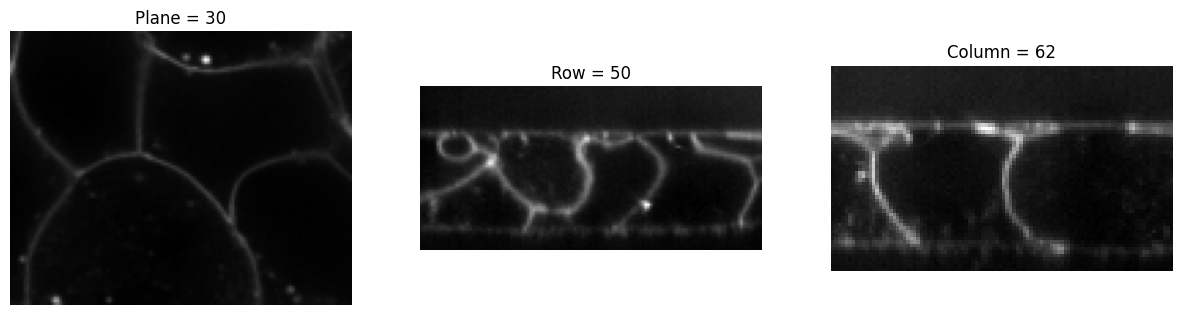

Divisible-Padded Output Size:
torch.Size([60, 128, 128])


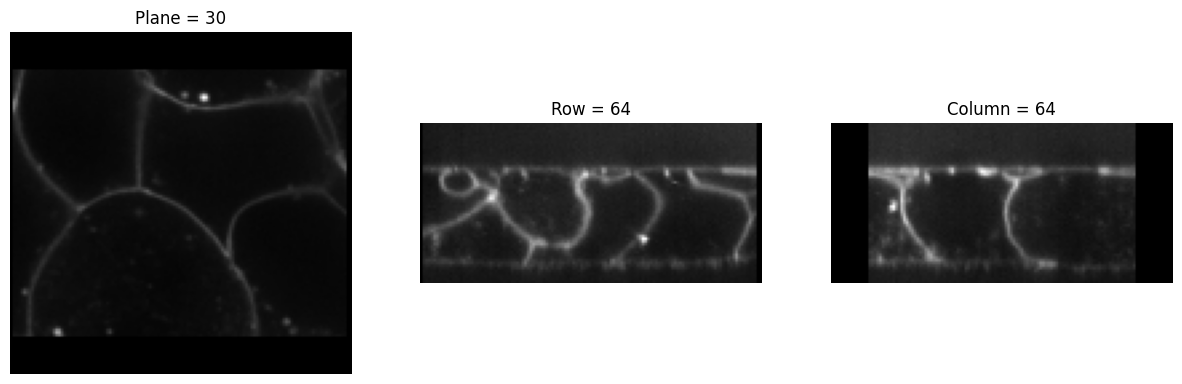

In [ ]:
# 1. Initialize a base image and artificially crop it to an odd shape (Shape: [Channels, 100, 125])
img_full = BioVolume(torchTensor(cells3d()[:,0]))
img_odd = img_full[:, :100, :125]
print(f"Original Odd Input Size: {img_odd.shape}")
show_slices(img_odd, showlines=False)

# 2. Pad to make spatial dimensions divisible by 32
# A standard U-Net with 5 pooling operations requires spatial sizes to be multiples of 2^5 = 32.
# Here, the Y-axis (100) will be padded to 128, and the X-axis (125) will be padded to 128.
div_pad_tfm = DivisiblePad(k=32)
img2 = div_pad_tfm(img_odd)

print(f"Divisible-Padded Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_divisible_pad_logic():
    # Transform inheritance
    t = DivisiblePad(k=16, backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to DivisiblePad
    t_monai = DivisiblePad(k=32, backend="monai")
    test_eq(isinstance(t_monai, mt.DivisiblePad), True)
    
    # Dict transform inference mapping to DivisiblePadd
    t_dict = DivisiblePad(k=32, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.DivisiblePadd), True)

    return "Passed"

test_eq(test_divisible_pad_logic(), "Passed")

#### `DivisiblePad` Class Attributes & Parameter Reference

This reference details the configurations used to dynamically pad arrays to architectural multiples.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`k`** | `int` or `tuple` | *Required* | The target divisor. If an `int` is provided, all spatial axes will be padded until they are divisible by this number. A `tuple` allows dimension-specific divisors. Passed as a positional argument. |
| **`mode`** | `str` | `"constant"` | The padding strategy. Options include `"constant"`, `"reflect"`, `"replicate"`, or `"circular"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`DivisiblePadd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [ ]:
#| export
class ResizeWithPadOrCrop(MonaiTransform):

    _monai_transform = mt.ResizeWithPadOrCrop

    def __init__(
        self,
        spatial_size,
        keys=None,
        **kwargs,
    ):
        self.spatial_size = spatial_size

        super().__init__(
            keys=keys,
            spatial_size=spatial_size,
            **kwargs,
        )

In [ ]:
show_doc(ResizeWithPadOrCrop)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L794){target="_blank" style="float:right; font-size:smaller"}

### ResizeWithPadOrCrop

```python

def ResizeWithPadOrCrop(
    spatial_size, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*A transform with a `__repr__` that shows its attrs*

#### Example: Forcing a specific absolute size regardless of the input dimensions

Original Input Size: torch.Size([60, 256, 256])


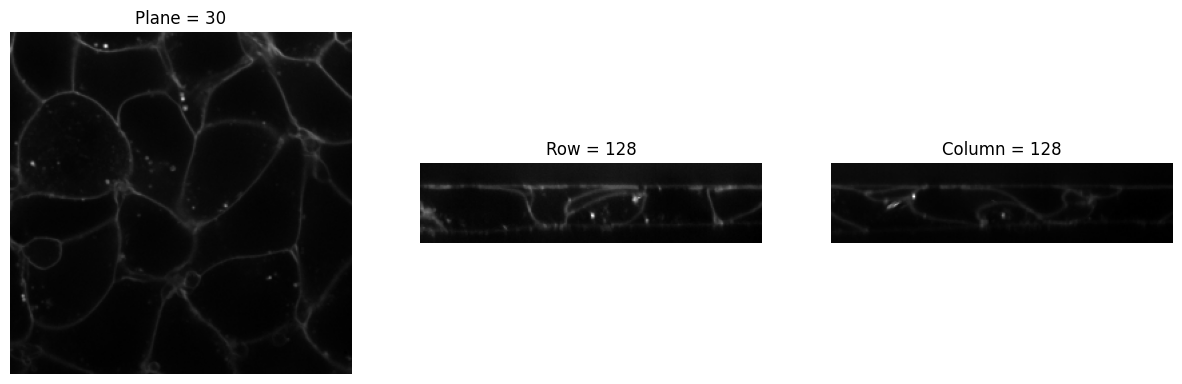

Standardized Output Size:
torch.Size([60, 150, 300])


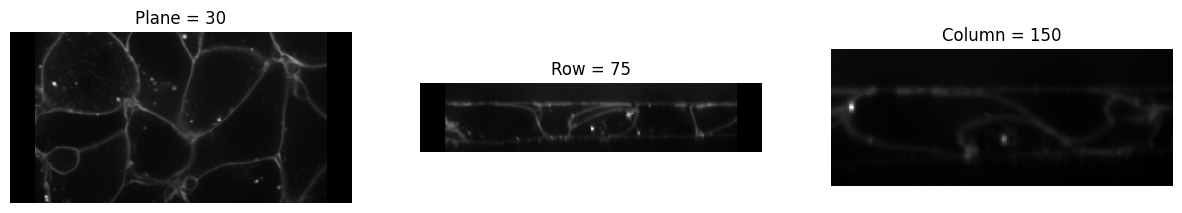

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Force an exact spatial size
# Suppose the original size is roughly 256x256.
# By requesting (150, 300), the transform will automatically CROP the Y-axis 
# down to 150, and PAD the X-axis up to 300, all in a single step.
standardize_tfm = ResizeWithPadOrCrop(spatial_size=(150, 300))
img2 = standardize_tfm(img)

print(f"Standardized Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_resize_pad_crop_logic():
    # Transform inheritance
    t = ResizeWithPadOrCrop(spatial_size=(64, 64), backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to ResizeWithPadOrCrop
    t_monai = ResizeWithPadOrCrop(spatial_size=(32, 32), backend="monai")
    test_eq(isinstance(t_monai, mt.ResizeWithPadOrCrop), True)
    
    # Dict transform inference mapping to ResizeWithPadOrCropd
    t_dict = ResizeWithPadOrCrop(spatial_size=(32, 32), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.ResizeWithPadOrCropd), True)

    return "Passed"

test_eq(test_resize_pad_crop_logic(), "Passed")

#### `ResizeWithPadOrCrop` Parameter ReferenceClass Attributes & Parameter Reference

This reference details the configurations used to force arrays into an exact spatial footprint.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_size`** | `tuple`, `list`, or `int` | *Required* | The absolute target spatial dimensions (e.g., `(256, 256)`). An integer broadcasts to all spatial axes. Passed as a positional argument. |
| **`method`** | `str` | `"symmetric"` | The strategy used for both padding and cropping. Options include `"symmetric"` (centers the operation) or `"end"`. Passed via `**kwargs`. |
| **`mode`** | `str` | `"constant"` | The value-filling strategy used if padding is required. Options include `"constant"`, `"reflect"`, `"replicate"`, or `"circular"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`ResizeWithPadOrCropd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

### Spatial Orientation & Deformation

In biomedical image analysis, absolute spatial coherence is the foundation upon which all reliable deep learning models are built. Unlike standard 2D photographs, medical and biological volumes possess a real physical coordinate framework, specific anatomical orientations, and metric resolutions (voxel spacing) that vary across different scanners and institutions.

This section groups the tools responsible for standardizing the physical space of the images and applying advanced geometric deformations—both linear and non-linear, as well as interpolation-independent operations. These are essential to simulate natural morphological variability during *Data Augmentation* and ensure data interoperability.

**Classes included in this module:**

#### 1. Grid Transformations and Regression

* **`GridPatch`**: Divides a volume into a structured pattern of geometric patches. Essential for patch-based learning algorithms, managing large volumetric datasets efficiently.
* **`GridSplit`**: Separates or decomposes the image into its individual spatial axes or channel planes.

#### 2. Standardization and Resampling

* **`SpatialResample`**: Normalizes the physical resolution (voxel spacing) by resampling the image. Ensures that the neural network processes anatomy at a consistent and uniform metric scale across datasets.
* **`ResampleToMatch`**: Aligns and resamples a moving image (source) to match the resolution, size, and spatial context of a fixed image (target).

#### 3. Orientation and Symmetry

* **`Orientation`**: Automatically reorients the spatial axes of the volume to match an industry-standard anatomical coordinate system (such as `"RAS"` or `"LPS"`).
* **`Flip`**: Applies a mirror effect or inversion of spatial axes, simulating natural anatomical symmetries (left-right, anterior-posterior).

#### 4. Linear and Geometric Transformations

* **`Affine`**: The "Swiss Army knife" that applies multiple spatial geometric transformations (rotation, scaling, translation, and shearing) in a single, highly optimized mathematical pass to preserve image quality.
* **`Rotate`**: Applies arbitrary rotations of specific angles around defined spatial axes to increase geometric variability.
* **`Rotate90`**: Performs strict rotations in multiples of 90 degrees. This operation is **highly efficient** as it does not require interpolation (it's an array index manipulation), preserving data integrity.
* **`Zoom`**: Applies metric scaling, zooming the image in or out while preserving the aspect ratio, fundamental for normalizing the scale of structures.

#### 5. Generation and Non-Linear Deformation

* **`AffineGrid`**: Generates the underlying mathematical coordinate maps needed to calculate geometric deformations from scratch, without directly processing image data.
* **`GridDistortion`**: Applies local, elastic, and non-linear spatial deformations. It uses a grid of independently displaced nodes to realistically simulate the natural flexibility of living biological tissue, ideal for biologically plausible *Data Augmentation*.

In [ ]:
#| export
class Rotate(MonaiTransform):
    """
    MONAI Rotate wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Rotate*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Rotate

    def __init__(
        self,
        angle=0.0,
        keys=None,
        **kwargs,
    ):

        self.angle = angle

        super().__init__(
            keys=keys,
            angle=angle, 
            **kwargs,
        )

In [ ]:
show_doc(Rotate)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L813){target="_blank" style="float:right; font-size:smaller"}

### Rotate

```python

def Rotate(
    angle:float=0.0, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI Rotate wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (Rotate*d auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Rotating an image by 45 degrees

Original Input Size: torch.Size([60, 256, 256])


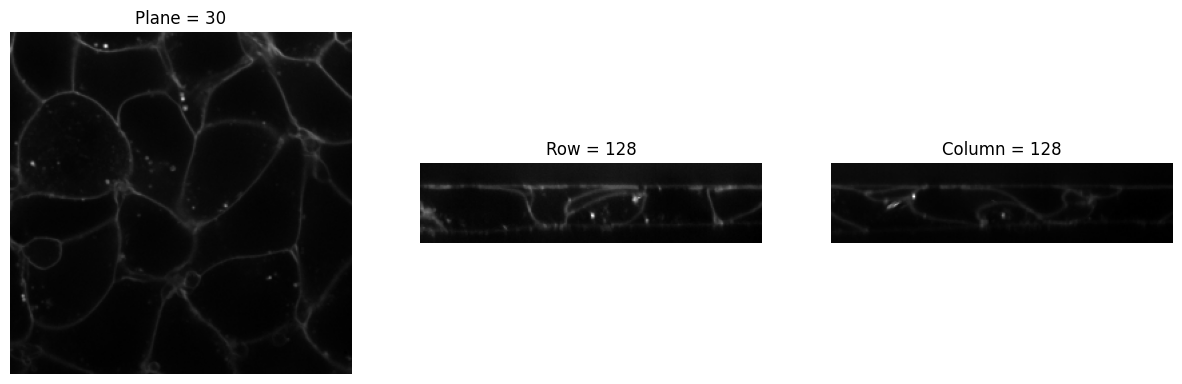

Rotated Output Size:
torch.Size([60, 362, 362])


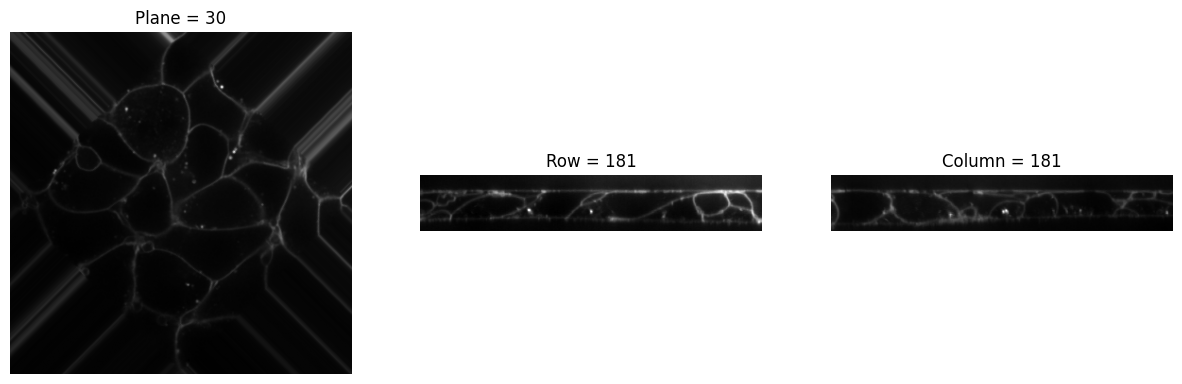

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply a 45-degree rotation
# MONAI strictly expects angles in radians (45 degrees = pi/4).
# We set keep_size=False so the canvas expands to fit the rotated corners 
# without cropping the original biological signal.
rotate_tfm = Rotate(angle=np.pi/4, keep_size=False)
img2 = rotate_tfm(img)

print(f"Rotated Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_rotate_logic():
    # Transform inheritance
    t = Rotate(angle=np.pi/4, backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to Rotate
    t_monai = Rotate(angle=np.pi, backend="monai")
    test_eq(isinstance(t_monai, mt.Rotate), True)
    
    # Dict transform inference mapping to Rotated
    t_dict = Rotate(angle=np.pi, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Rotated), True)

    return "Passed"

test_eq(test_rotate_logic(), "Passed")

#### `Rotate` Class Attributes & Parameter Reference

This reference details the configurations used to rotate arrays and handle coordinate grid interpolations.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native orientation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`angle`** | `float` or `Sequence[float]` | `0.0` | The rotation angle(s) in **radians**. For 2D, a single float is used. For 3D, a sequence of up to 3 floats specifies rotation around each spatial axis. |
| **`keep_size`** | `bool` | `True` | If `True`, the output tensor matches the input shape (which might crop the corners). If `False`, the canvas expands to fit the entire rotated image. Passed via `**kwargs`. |
| **`mode`** | `str` | `"bilinear"` | Interpolation mode. Options typically include `"nearest"`, `"bilinear"`, or `"bicubic"`. Passed via `**kwargs`. |
| **`padding_mode`** | `str` | `"border"` | Strategy for filling newly created empty spaces outside the rotated bounds. Options: `"zeros"`, `"border"`, `"reflection"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Rotated`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |

In [ ]:
#| export
class Rotate90(MonaiTransform):
    """
    MONAI Rotate90 wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Rotate90*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Rotate90

    def __init__(
        self,
        spatial_axes=(0, 1),
        keys=None,
        **kwargs,
    ):

        self.spatial_axes = spatial_axes

        super().__init__(
            keys=keys,
            spatial_axes=spatial_axes, 
            **kwargs,
        )

In [ ]:
show_doc(Rotate90)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L841){target="_blank" style="float:right; font-size:smaller"}

### Rotate90

```python

def Rotate90(
    spatial_axes:tuple=(0, 1), keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI Rotate90 wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (Rotate90*d auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Fast, lossless 90-degree rotation


Original Input Size: torch.Size([60, 256, 256])


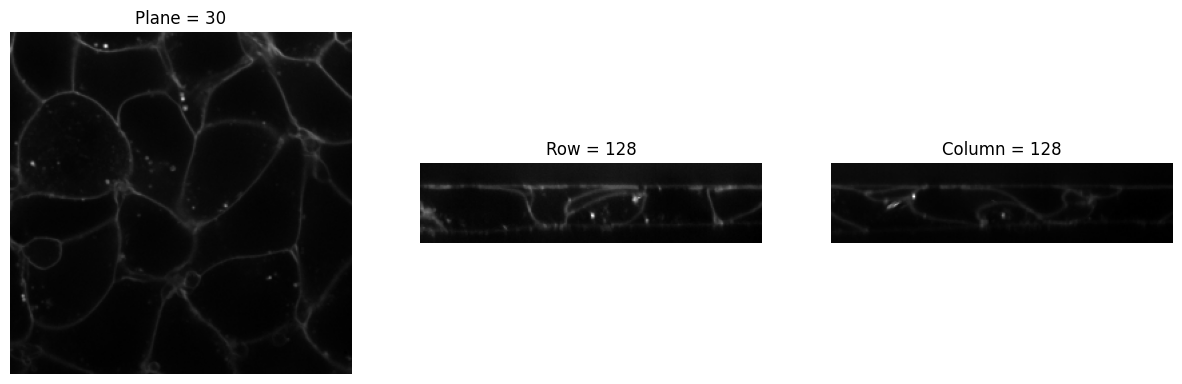

Rotate90 Output Size:
torch.Size([60, 256, 256])


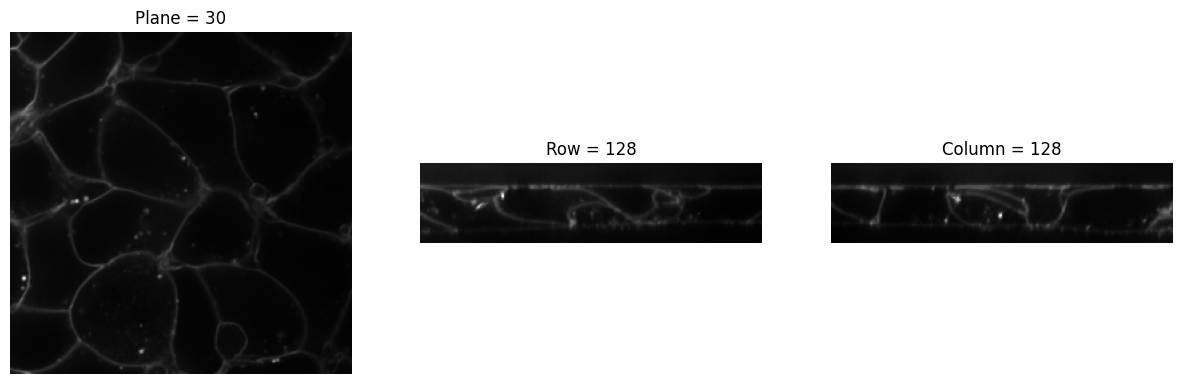

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply a 90-degree rotation in the spatial plane
# By default, it rotates 1 time (k=1) in the plane defined by axes (0, 1) -> Y, X.
# If we passed k=2, it would rotate 180 degrees.
rotate90_tfm = Rotate90(spatial_axes=(0, 1), k=1)
img2 = rotate90_tfm(img)

print(f"Rotate90 Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_rotate90_logic():
    # Transform inheritance
    t = Rotate90(spatial_axes=(0, 1), backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to Rotate90
    t_monai = Rotate90(spatial_axes=(1, 2), k=2, backend="monai")
    test_eq(isinstance(t_monai, mt.Rotate90), True)
    
    # Dict transform inference mapping to Rotate90d
    t_dict = Rotate90(spatial_axes=(0, 1), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Rotate90d), True)

    return "Passed"

test_eq(test_rotate90_logic(), "Passed")

#### `Rotate90` Class Attributes & Parameter Reference

This reference details the configurations used for fast, plane-specific right-angle rotations.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native orientation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_axes`** | `tuple` | `(0, 1)` | The two spatial dimensions defining the plane of rotation. For a standard 2D image `[C, Y, X]`, the spatial axes are `(0, 1)`. |
| **`k`** | `int` | `1` | The number of times to rotate by 90 degrees. For example, `k=2` equals 180 degrees, `k=3` equals 270 degrees. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Rotate90d`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |

In [ ]:
#| export
class Zoom(MonaiTransform):
    """
    MONAI Zoom wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Zoom*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Zoom

    def __init__(
        self,
        zoom=1.0,
        keys=None,
        **kwargs,
    ):

        self.zoom = zoom

        super().__init__(
            keys=keys,
            zoom=zoom, 
            **kwargs,
        )

In [ ]:
show_doc(Zoom)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L869){target="_blank" style="float:right; font-size:smaller"}

### Zoom

```python

def Zoom(
    zoom:float=1.0, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI Zoom wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (Zoom*d auto-inferred)
- BioImageBase
- NumPy arrays

#### Example: Applying a digital zoom to a biological sample

Original Input Size: torch.Size([60, 256, 256])


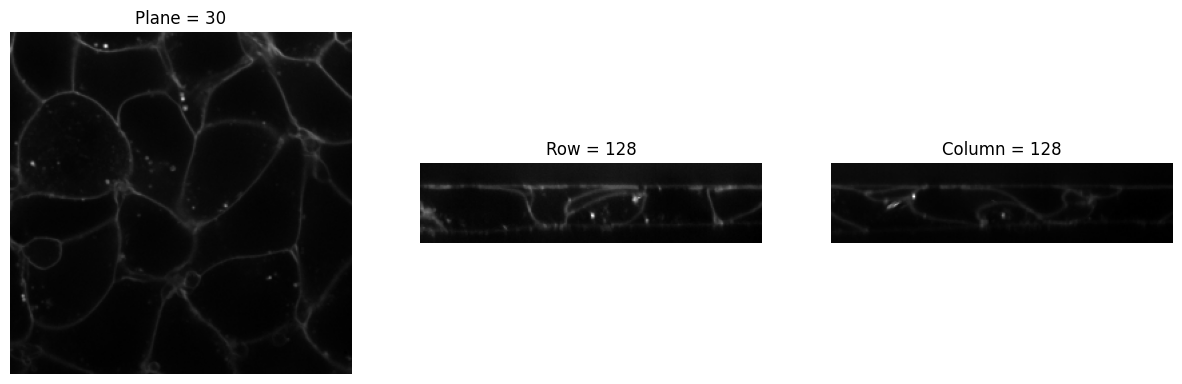

Zoomed Output Size (Notice it remains the same as the original):
torch.Size([60, 256, 256])


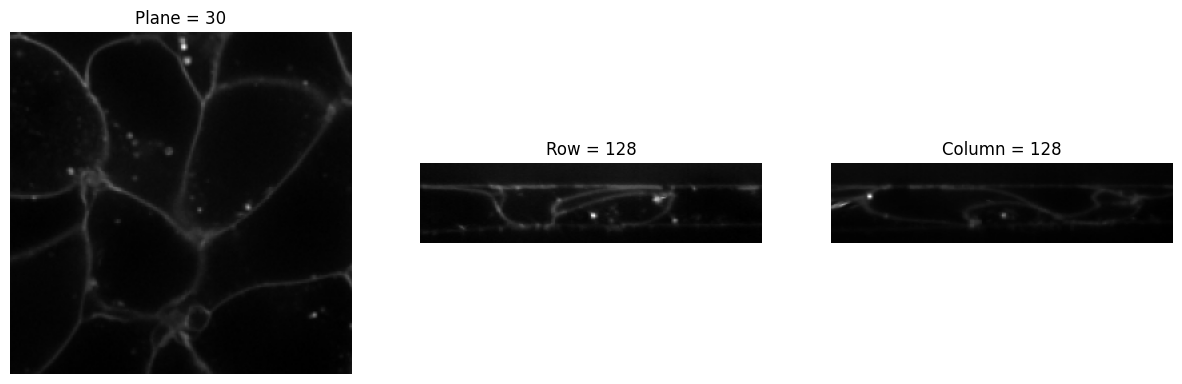

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply a 1.5x zoom
# By keeping the default keep_size=True, the transform scales the image by 1.5x
# and then crops the boundaries, ensuring the final shape matches the original.
# If we set keep_size=False, the canvas would expand to fit the new zoomed dimensions.
zoom_tfm = Zoom(zoom=1.5)
img2 = zoom_tfm(img)

print(f"Zoomed Output Size (Notice it remains the same as the original):")
print(img2.size())
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_zoom_logic():
    # Transform inheritance
    t = Zoom(zoom=1.2, backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to Zoom
    t_monai = Zoom(zoom=0.8, backend="monai")
    test_eq(isinstance(t_monai, mt.Zoom), True)
    
    # Dict transform inference mapping to Zoomd
    t_dict = Zoom(zoom=1.5, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Zoomd), True)

    return "Passed"

test_eq(test_zoom_logic(), "Passed")

#### `Zoom` Class Attributes & Parameter Reference

This reference details the configurations used to apply relative spatial scaling.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native deformation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`zoom`** | `float` or `Sequence[float]` | `1.0` | The multiplier to scale the spatial dimensions. E.g., `1.5` increases size by 50%. A sequence allows different zoom factors for each axis. |
| **`keep_size`** | `bool` | `True` | If `True`, crops or pads the output to strictly match the input's original size. If `False`, the output tensor dimensions change based on the zoom factor. Passed via `**kwargs`. |
| **`mode`** | `str` | `"area"` / `"bilinear"` | Interpolation mode used to calculate new voxel values. Options include `"nearest"`, `"bilinear"`, `"bicubic"`, or `"area"`. Passed via `**kwargs`. |
| **`padding_mode`** | `str` | `"constant"` | If zooming out (`zoom < 1.0`) with `keep_size=True`, defines how to fill the new empty borders. Options: `"constant"`, `"reflect"`, `"replicate"`, `"circular"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Zoomd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |

In [ ]:
#| export
class Flip(MonaiTransform):
    """
    MONAI Flip wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Flip*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """

    _monai_transform = mt.Flip

In [ ]:
show_doc(Flip)

#### Example: Mirroring an image horizontally (flipping along the X-axis)

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply a spatial flip
# Assuming spatial dimensions are (Y, X), axis 0 is Y (vertical), and axis 1 is X (horizontal).
# Passing spatial_axis=1 will flip the image horizontally (left-to-right).
# If spatial_axis=None (the default), it flips all spatial axes simultaneously.
flip_tfm = Flip(spatial_axis=1)
img2 = flip_tfm(img)

print(f"Flipped Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [ ]:
#| hide

def test_flip_logic():
    # Transform inheritance
    t = Flip(spatial_axis=0, backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to Flip
    t_monai = Flip(spatial_axis=1, backend="monai")
    test_eq(isinstance(t_monai, mt.Flip), True)
    
    # Dict transform inference mapping to Flipd
    t_dict = Flip(spatial_axis=0, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Flipd), True)

    return "Passed"

test_eq(test_flip_logic(), "Passed")

#### `Flip` Class Attributes & Parameter Reference

This reference details the configurations used to mirror tensors along specific axes.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native orientation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_axis`** | `int`, `tuple`, or `None` | `None` | The spatial axis (or axes) to flip along. If `None`, it flips all spatial dimensions simultaneously. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Flipd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [ ]:
#| export
class GridPatch(MonaiTransform):
    """
    MONAI GridPatch wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (GridPatch*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.GridPatch

    def __init__(
        self,
        patch_size=None,
        keys=None,
        **kwargs,
    ):

        self.patch_size = patch_size

        super().__init__(
            keys=keys,
            patch_size=patch_size, 
            **kwargs,
        )

In [ ]:
show_doc(GridPatch)

#### Example: Decomposing a large image into a grid of smaller patches

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply the GridPatch operation
# We divide the image into smaller spatial patches of 64x64.
# The transform returns a generator/iterable, so we convert it to a list.
grid_tfm = GridPatch(patch_size=(64, 64))
patches = list(grid_tfm(img))

print(f"Generated a grid of {len(patches)} patches.")
print(f"Shape of the first extracted patch: {patches[0].shape}")

# Visualize just the very first patch of the grid
show_slices(patches[0], showlines=False)

In [ ]:
#| hide

def test_grid_patch_logic():
    # Transform inheritance
    t = GridPatch(patch_size=(32, 32), backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to GridPatch
    t_monai = GridPatch(patch_size=(16, 16), backend="monai")
    test_eq(isinstance(t_monai, mt.GridPatch), True)
    
    # Dict transform inference mapping to GridPatchd
    t_dict = GridPatch(patch_size=(16, 16), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.GridPatchd), True)

    return "Passed"

test_eq(test_grid_patch_logic(), "Passed")

#### `GridPatch` Class Attributes & Parameter Reference

This reference details the configurations used to decompose large arrays into manageable grids.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native patching operator (`backend="monai"`). *Note: The runtime output is an iterable of patched tensors.*

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`patch_size`** | `tuple` | *Required* | The absolute spatial dimensions for each generated patch (e.g., `(64, 64)`). Passed as a positional argument. |
| **`overlap`** | `float` or `tuple` | `0.0` | The amount of overlap between adjacent patches, expressed as a fraction of the patch size (e.g., `0.5` means 50% overlap). Passed via `**kwargs`. |
| **`pad_mode`** | `str` | `"constant"` | If the original image is not perfectly divisible by the patch size, dictates how to pad the boundaries. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`GridPatchd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [ ]:
#| export
class GridSplit(MonaiTransform):
    """
    MONAI GridSplit wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (GridSplit*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.GridSplit

In [ ]:
show_doc(GridSplit)

#### Example: Splitting an image into a 2x2 grid of proportional patches

In [ ]:
# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply the GridSplit operation
# We ask the transform to divide the spatial canvas into a 2x2 grid.
# This will yield 4 evenly divided patches (top-left, top-right, bottom-left, bottom-right).
# The transform returns a generator/iterable, so we convert it to a list.
grid_tfm = GridSplit(grid=(2, 2))
patches = list(grid_tfm(img))

print(f"Generated a grid of {len(patches)} patches.")
print(f"Shape of the first extracted patch: {patches[0].shape}")

# Visualize just the very first segment of the split (Top-Left)
show_slices(patches[0], showlines=False)

In [ ]:
#| hide

def test_gridsplit_logic():
    # Transform inheritance
    t = GridSplit(grid=(2, 2), backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to GridSplit
    t_monai = GridSplit(grid=(3, 3), backend="monai")
    test_eq(isinstance(t_monai, mt.GridSplit), True)
    
    # Dict transform inference mapping to GridSplitd
    t_dict = GridSplit(grid=(2, 2), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.GridSplitd), True)

    return "Passed"

test_eq(test_gridsplit_logic(), "Passed")

#### `GridSplit` Class Attributes & Parameter Reference

This reference details the configurations used to divide an array into fixed proportional segments.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native splitting operator (`backend="monai"`). *Note: The runtime output is an iterable of split tensors.*

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`grid`** | `tuple` or `None` | `None` | The number of splits along each spatial dimension (e.g., `(2, 2)` splits a 2D image into 4 patches). Passed via `**kwargs`. |
| **`size`** | `tuple` or `None` | `None` | The absolute size of each split chunk. You must provide either `grid` or `size` (but not both). Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`GridSplitd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [ ]:
#| export
class _StaticSpatialResample(mt.SpatialResample):
    """Internal patch to allow static initialization of spatial_size and dst_affine."""
    def __init__(self, spatial_size=None, dst_affine=None, **kwargs):
        super().__init__(**kwargs)
        self.spatial_size = spatial_size
        self.dst_affine = dst_affine
        
    def __call__(self, img, **kwargs):
        # Inject our static parameters automatically during the pipeline execution
        kwargs.setdefault("spatial_size", self.spatial_size)
        kwargs.setdefault("dst_affine", self.dst_affine)
        return super().__call__(img, **kwargs)

class _StaticSpatialResampled(mt.SpatialResampled):
    """Internal patch for dictionary-based static initialization."""
    def __init__(self, keys, spatial_size=None, dst_affine=None, **kwargs):
        super().__init__(keys, **kwargs)
        self.spatial_size = spatial_size
        self.dst_affine = dst_affine
        
    def __call__(self, data, **kwargs):
        kwargs.setdefault("spatial_size", self.spatial_size)
        kwargs.setdefault("dst_affine", self.dst_affine)
        return super().__call__(data, **kwargs)

class SpatialResample(MonaiTransform):
    """
    MONAI SpatialResample wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (SpatialResample*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = _StaticSpatialResample

    @classmethod
    def _create_dict_transform(cls, keys, *args, **kwargs):
        # Override to ensure the dict inference uses our patched dictionary subclass
        return _StaticSpatialResampled(keys, *args, **kwargs)

In [ ]:
show_doc(SpatialResample)

In [ ]:
# Example: Resampling the spatial coordinate grid of an image
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply Spatial Resampling
# We force the image to resample its coordinate grid to a new 128x128 footprint.
# Unlike a standard 'Resize', SpatialResample can also accept complex target affine matrices.
resample_tfm = SpatialResample(spatial_size=(128, 128))
img2 = resample_tfm(img)

print(f"Resampled Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [ ]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_spatial_resample_logic():
    # Transform inheritance
    t = SpatialResample(spatial_size=(64, 64), backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to SpatialResample
    t_monai = SpatialResample(spatial_size=(32, 32), backend="monai")
    test_eq(isinstance(t_monai, mt.SpatialResample), True)
    
    # Dict transform inference mapping to SpatialResampled
    t_dict = SpatialResample(spatial_size=(32, 32), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.SpatialResampled), True)

    return "Passed"

test_eq(test_spatial_resample_logic(), "Passed")

#### `SpatialResample` Class Attributes & Parameter Reference

This reference details the configurations used to recalculate the physical or spatial grid of the array.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native deformation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_size`** | `tuple`, `list`, or `None` | `None` | The target spatial dimensions to resample into (e.g., `(128, 128)`). Explicitly supported during initialization via our static patch. |
| **`dst_affine`** | `array-like` or `None` | `None` | The target affine matrix defining the new coordinate space. Explicitly supported during initialization via our static patch. |
| **`mode`** | `str` | `"bilinear"` | The interpolation mode used to estimate the new grid values. Options typically include `"nearest"`, `"bilinear"`, or `"bicubic"`. Passed via `**kwargs`. |
| **`padding_mode`** | `str` | `"border"` | Strategy for filling out-of-bounds pixels during resampling. Options include `"zeros"`, `"border"`, or `"reflection"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`SpatialResampled`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator (e.g., `align_corners`). |

In [ ]:
#| export
class ResampleToMatch(MonaiTransform):
    """
    MONAI ResampleToMatch wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (ResampleToMatch*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.ResampleToMatch

In [ ]:
show_doc(ResampleToMatch)

In [ ]:
# Example: Aligning a low-res mask to perfectly match a high-res image grid
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Let's simulate a scenario with mismatched spatial resolutions
img_high_res = BioVolume(torchTensor(cells3d()[:,0]))

# Create an artificially smaller "mask" to simulate mismatched acquisition
mismatched_mask = SpatialResample(spatial_size=(64, 64))(img_high_res) 

# Package them into a dictionary representing a single patient's data
data_dict = {"image": img_high_res, "mask": mismatched_mask}

print(f"Mismatched Shapes -> Image: {data_dict['image'].shape}, Mask: {data_dict['mask'].shape}")

# 2. Apply dictionary-based ResampleToMatch
# We configure it to resample the 'mask' using the 'image' as the spatial reference.
# We use mode="nearest" to preserve discrete class values in masks.
match_tfm = ResampleToMatch(keys=["mask"], key_dst="image", mode="nearest")
matched_dict = match_tfm(data_dict)

print(f"Matched Shapes    -> Image: {matched_dict['image'].shape}, Mask: {matched_dict['mask'].shape}")
show_slices(matched_dict['mask'], showlines=False)

In [ ]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_resample_to_match_logic():
    # Transform inheritance
    t = ResampleToMatch(backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to ResampleToMatch
    t_monai = ResampleToMatch(backend="monai")
    test_eq(isinstance(t_monai, mt.ResampleToMatch), True)
    
    # Dict transform inference mapping to ResampleToMatchd
    # Note: 'key_dst' is required by MONAI to point to the reference dictionary key
    t_dict = ResampleToMatch(keys=["mask"], key_dst="image", backend="monai")
    test_eq(isinstance(t_dict, mt.ResampleToMatchd), True)

    return "Passed"

test_eq(test_resample_to_match_logic(), "Passed")

#### `ResampleToMatch` Class Attributes & Parameter Reference

This reference details the configurations used to align and interpolate arrays to a reference grid.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native deformation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`keys`** | `list[str]` or `None` | `None` | Identifiers triggering the dictionary-based counterpart (`ResampleToMatchd`). Defines which arrays will be resampled. |
| **`key_dst`** | `str` | `None` | **Required if using `keys`.** The dictionary key pointing to the reference image. The transform will extract its spatial metadata to govern the resampling. Passed via `**kwargs`. |
| **`mode`** | `str` | `"bilinear"` | Interpolation mode used for resampling. E.g., use `"nearest"` for segmentation masks or `"bilinear"`/`"bicubic"` for images. Passed via `**kwargs`. |
| **`padding_mode`** | `str` | `"border"` | Strategy for filling out-of-bounds pixels during resampling. Options include `"zeros"`, `"border"`, or `"reflection"`. Passed via `**kwargs`. |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [ ]:
#| export
import warnings
import monai.transforms as mt

class _QuietOrientation(mt.Orientation):
    """Internal patch to suppress MONAI's FutureWarning regarding labels."""
    def __init__(self, *args, **kwargs):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            super().__init__(*args, **kwargs)

class _QuietOrientationd(mt.Orientationd):
    """Internal patch to suppress MONAI's FutureWarning for dictionary inputs."""
    def __init__(self, *args, **kwargs):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            super().__init__(*args, **kwargs)


class Orientation(MonaiTransform):
    """
    MONAI Orientation wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Orientation*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = _QuietOrientation

    @classmethod
    def _create_dict_transform(cls, keys, *args, **kwargs):
        # Override to ensure the dict inference uses our quiet dictionary subclass
        return _QuietOrientationd(keys, *args, **kwargs)

In [ ]:
show_doc(Orientation)

In [ ]:
# Example: Standardizing the physical orientation of a volume
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base volume (Shape: [Channels, Z, Y, X])
# cells3d()[:,0] gives us [60, 256, 256] (Z, Y, X).
# We use .unsqueeze(0) to explicitly add the Channel dimension -> [1, 60, 256, 256]
img = BioVolume(torchTensor(cells3d()[:,0]).unsqueeze(0))
print(f"Original Input Size: {img.shape}")

# show_slices strictly expects a 3D spatial volume. 
# We pass img[0] to temporarily strip the channel dimension for plotting.
show_slices(img[0], showlines=False)

# 2. Apply Anatomical Orientation
# We specify the target orientation using axis codes.
# 'RAS' is a very common 3D standard representing Right, Anterior, Superior.
# The transform automatically calculates the necessary transpositions/flips 
# to rearrange the spatial axes into this specific coordinate space.
orientation_tfm = Orientation(axcodes="RAS")
img2 = orientation_tfm(img)

print(f"Re-oriented Output Size:")
print(img2.size())

# Again, strip the channel dimension for the final visualization
show_slices(img2[0], showlines=False)

In [ ]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_orientation_logic():
    # Transform inheritance
    t = Orientation(axcodes="RAS", backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to Orientation
    t_monai = Orientation(axcodes="LPS", backend="monai")
    test_eq(isinstance(t_monai, mt.Orientation), True)
    
    # Dict transform inference mapping to Orientationd
    t_dict = Orientation(axcodes="RAS", keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Orientationd), True)

    return "Passed"

test_eq(test_orientation_logic(), "Passed")

#### `Orientation` Class Attributes & Parameter Reference

This reference details the configurations used to align physical spatial axes to standardized anatomical codes.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native orientation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`axcodes`** | `str` | `None` | The target axis codes representing the desired physical orientation (e.g., `"RAS"`, `"LPS"`, `"SPL"`). Passed via `**kwargs`. |
| **`as_closest_canonical`** | `bool` | `False` | If `True`, ignores the specific `axcodes` and automatically snaps the orientation to the closest standard canonical orientation (like RAS). Passed via `**kwargs`. |
| **`labels`** | `tuple` | `None` | Optional identifiers for the original spatial dimensions if the affine metadata is missing. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Orientationd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [ ]:
#| export
class Affine(MonaiTransform):
    """
    MONAI Affine wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Affine*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Affine

In [ ]:
show_doc(Affine)

In [ ]:
# Example: Applying a combined Rotate + Scale + Translate in a single pass
import numpy as np
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base volume (Shape: [Channels, Z, Y, X])
# We explicitly add the Channel dimension -> [1, 60, 256, 256]
img = BioVolume(torchTensor(cells3d()[:,0]).unsqueeze(0))
print(f"Original Input Size: {img.shape}")
show_slices(img[0], showlines=False)

# 2. Apply a complex Affine transformation
# Since our volume has 3 spatial dimensions (Z, Y, X), we pass a tuple of 3 values.
# - No change to Z (axis 0)
# - Rotate 45 degrees (pi/4) in the YX plane
# - Scale Y and X by 1.5x (zoom in)
# - Translate/shift Y by 20 pixels and X by -20 pixels
# IMPORTANT: image_only=True forces MONAI to return just the tensor, not the affine matrix tuple
affine_tfm = Affine(
    rotate_params=(0.0, 0.0, np.pi/4),
    scale_params=(1.0, 1.5, 1.5),
    translate_params=(0, 20, -20),
    padding_mode="zeros",
    image_only=True
)

img2 = affine_tfm(img)

print(f"Affine Output Size:")
print(img2.size())

# Strip the channel dimension for the final visualization
show_slices(img2[0], showlines=False)

In [ ]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt
import numpy as np

def test_affine_logic():
    # Transform inheritance
    t = Affine(rotate_params=np.pi/4, backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to Affine
    t_monai = Affine(scale_params=1.5, backend="monai")
    test_eq(isinstance(t_monai, mt.Affine), True)
    
    # Dict transform inference mapping to Affined
    t_dict = Affine(translate_params=(10, 10), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Affined), True)

    return "Passed"

test_eq(test_affine_logic(), "Passed")

#### `Affine` Class Attributes & Parameter Reference

This reference details the configurations used to build and apply multi-dimensional affine matrices.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native deformation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`affine`** | `array-like` | `None` | A custom square matrix (e.g., 3x3 for 2D, 4x4 for 3D) defining the exact mathematical transformation. Passed via `**kwargs`. |
| **`rotate_params`** | `float` or `Sequence` | `None` | Rotation angles in **radians**. For 3D, a sequence of 3 floats specifies rotation around the Z, Y, and X axes. Passed via `**kwargs`. |
| **`scale_params`** | `float` or `Sequence` | `None` | Scale multipliers (e.g., `1.5` increases size by 50%). Passed via `**kwargs`. |
| **`translate_params`**| `float` or `Sequence` | `None` | Translation offsets in pixels/voxels. Passed via `**kwargs`. |
| **`shear_params`** | `float` or `Sequence` | `None` | Shearing factors for the spatial axes. Passed via `**kwargs`. |
| **`spatial_size`** | `tuple` | `None` | The absolute target output size. If `None`, the output retains the input's spatial dimensions. Passed via `**kwargs`. |
| **`mode`** | `str` | `"bilinear"` | Interpolation mode used to calculate new voxel values. Options include `"nearest"`, `"bilinear"`, or `"bicubic"`. Passed via `**kwargs`. |
| **`padding_mode`** | `str` | `"reflection"`| Strategy for filling empty spaces created by the deformation. Options: `"zeros"`, `"border"`, or `"reflection"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Affined`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator (e.g., `image_only`). |

In [ ]:
#| export
import monai.transforms as mt

class _StaticAffineGrid(mt.AffineGrid):
    """Internal patch to allow static initialization of spatial_size."""
    def __init__(self, spatial_size=None, **kwargs):
        super().__init__(**kwargs)
        self.spatial_size = spatial_size
        
    def __call__(self, spatial_size=None, **kwargs):
        # If spatial_size is passed during the call (dynamic), use it.
        # Otherwise, fall back to the one defined during __init__ (static).
        target_size = spatial_size if spatial_size is not None else self.spatial_size
        return super().__call__(spatial_size=target_size, **kwargs)

class AffineGrid(MonaiTransform):
    """
    MONAI AffineGrid wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = _StaticAffineGrid

In [ ]:
show_doc(AffineGrid)

In [ ]:
# Example: Generating a mathematical deformation grid
import numpy as np

# 1. Initialize the grid generator
# We configure it to apply a 45-degree rotation (pi/4 radians).
grid_tfm = AffineGrid(rotate_params=(np.pi/4,))

# 2. Generate the coordinate grid
# IMPORTANT: We pass the size as a LIST [64, 64], not a tuple.
# If we pass a tuple (64, 64), fastai assumes it's a multimodal batch (like image & mask)
# and tries to process the numbers 64 and 64 separately!
output = grid_tfm([64, 64])

# AffineGrid returns a tuple of (grid, affine_matrix). We safely extract the grid [0].
deformation_grid = output[0] if isinstance(output, tuple) else output

print(f"Deformation Grid Output Size:")
print(deformation_grid.size())

# For a 2D spatial size (64, 64), it returns a tensor of shape [2, 64, 64].
# The 2 channels represent the independent X and Y coordinate shifts for every pixel.

In [ ]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt
import numpy as np

def test_affine_grid_logic():
    # Transform inheritance
    t = AffineGrid(rotate_params=np.pi/4, backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to AffineGrid
    t_monai = AffineGrid(spatial_size=(32, 32), backend="monai")
    test_eq(isinstance(t_monai, mt.AffineGrid), True)
    
    # NOTE: We explicitly omit the dictionary inference test here because 
    # AffineGrid does not process data dictionaries, and mt.AffineGridd does not exist.

    return "Passed"

test_eq(test_affine_grid_logic(), "Passed")

#### `AffineGrid` Class Attributes & Parameter Reference

This reference details the configurations used to generate mathematical deformation coordinate maps.

**Returns:** A fastai-compatible wrapper (`backend="fastai"`) or a native grid generator (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`affine`** | `array-like` | `None` | A custom square matrix defining the exact mathematical transformation. Passed via `**kwargs`. |
| **`rotate_params`** | `float` or `Sequence` | `None` | Rotation angles in **radians**. For 3D grids, a sequence of 3 floats. Passed via `**kwargs`. |
| **`scale_params`** | `float` or `Sequence` | `None` | Scale multipliers (e.g., `1.5` for zooming in). Passed via `**kwargs`. |
| **`translate_params`**| `float` or `Sequence` | `None` | Translation offsets in pixels/voxels. Passed via `**kwargs`. |
| **`shear_params`** | `float` or `Sequence` | `None` | Shearing factors for the spatial axes. Passed via `**kwargs`. |
| **`spatial_size`** | `tuple` or `list` | `None` | The absolute target output size for the grid. **Explicitly supported during initialization via our static patch**, or can be passed dynamically during execution. |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator (e.g., `device`, `align_corners`). |

*(Note: The `keys` parameter is intentionally omitted from this transform because a dictionary counterpart does not exist in the MONAI library for grid generation).*

In [ ]:
#| export
import monai.transforms as mt

class _SafeGridDistortion(mt.GridDistortion):
    """Internal patch to handle MONAI's strictly required arguments in proper positional order."""
    def __init__(self, num_cells=5, distort_steps=None, **kwargs):
        # We guarantee a value exists. If omitted, we pass an empty list.
        steps = [] if distort_steps is None else distort_steps
        # Pass num_cells and steps strictly in their required positional order
        super().__init__(num_cells, steps, **kwargs)

class _SafeGridDistortiond(mt.GridDistortiond):
    """Internal patch for dict-based GridDistortion."""
    def __init__(self, keys, num_cells=5, distort_steps=None, **kwargs):
        steps = [] if distort_steps is None else distort_steps
        # Pass keys, num_cells, and steps strictly in their required positional order
        super().__init__(keys, num_cells, steps, **kwargs)


class GridDistortion(MonaiTransform):
    """
    MONAI GridDistortion wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (GridDistortion*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = _SafeGridDistortion

    @classmethod
    def _create_dict_transform(cls, keys, *args, **kwargs):
        # Override to ensure the dict inference uses our patched dictionary subclass
        return _SafeGridDistortiond(keys, *args, **kwargs)

In [ ]:
show_doc(GridDistortion)

In [ ]:
# Example: Applying a non-linear, elastic grid distortion to a volume
import numpy as np
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base volume (Shape: [Channels, Z, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]).unsqueeze(0))
print(f"Original Input Size: {img.shape}")
show_slices(img[0], showlines=False)

# 2. Prepare the deterministic grid displacements (distort_steps)
num_cells = 4
spatial_dims = 3

# CORRECT DEFORMATION MULTIPLIERS:
# MONAI interprets `distort_steps` as the relative scale/length of each cell.
# Normal size is 1.0. We randomly stretch (e.g., 1.1) or shrink (e.g., 0.9) each cell.
# We generate `num_cells` multipliers per spatial dimension.
steps = tuple(
    np.random.uniform(0.5, 1.5, size=(num_cells,)).tolist() 
    for _ in range(spatial_dims)
)

# 3. Apply the Grid Distortion
distortion_tfm = GridDistortion(
    num_cells=num_cells, 
    distort_steps=steps, 
    padding_mode="border"
)

img2 = distortion_tfm(img)

print(f"Distorted Output Size:")
print(img2.size())

# Strip the channel dimension for the final visualization
show_slices(img2[0], showlines=False)

In [ ]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_grid_distortion_logic():
    # Transform inheritance (using our empty list protection if distort_steps is omitted)
    t = GridDistortion(num_cells=4, backend="fastai")
    test_eq(isinstance(t, fastTransform), True)
    
    # Backend interception mapping to GridDistortion
    t_monai = GridDistortion(num_cells=5, backend="monai")
    test_eq(isinstance(t_monai, mt.GridDistortion), True)
    
    # Dict transform inference mapping to GridDistortiond
    t_dict = GridDistortion(num_cells=4, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.GridDistortiond), True)

    return "Passed"

test_eq(test_grid_distortion_logic(), "Passed")

#### `GridDistortion` Class Attributes & Parameter Reference

This reference details the configurations used to apply non-linear, elastic-like tissue deformations.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native deformation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`num_cells`** | `int` or `tuple` | `5` | The number of grid cells per spatial dimension (e.g., `4` means a 4x4 or 4x4x4 grid). Explicitly supported in initialization. |
| **`distort_steps`** | `tuple` or `None` | `None` | Multipliers representing the relative scale/length of each cell (1.0 = normal size). We safely intercept this parameter to prevent initialization crashes if omitted. |
| **`mode`** | `str` | `"bilinear"` | Interpolation mode used to calculate the elastically stretched voxel values. Options include `"nearest"`, `"bilinear"`, or `"bicubic"`. Passed via `**kwargs`. |
| **`padding_mode`** | `str` | `"border"` | Strategy for filling empty spaces created by pulling the grid inward. Options: `"zeros"`, `"border"`, or `"reflection"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`GridDistortiond`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

### Noise & Intensity Shift

While spatial transformations alter the *where* (the physical geometry of the anatomy), intensity shifts and noise injections alter the *what* (the pixel or voxel values themselves). 

In medical imaging, scanner artifacts, variations in contrast protocols, and different sensor sensitivities can drastically change the appearance of identical tissue. This section provides tools to inject noise, smooth out high-frequency artifacts, enhance structural edges, and shift global intensity distributions to build models that are robust to sensor-level variations.

**Classes included in this module:**

#### 1. Smoothing & Blurring Operations
Smoothing filters are typically used to denoise images, soften sharp boundaries, or simulate the lower resolution of certain imaging modalities.

* **`GaussianSmooth` (Alias: `Blur`)**: Applies a standard Gaussian blur. Excellent for simulating out-of-focus artifacts or generalizing high-frequency noise.
* **`MedianSmooth`**: Replaces each pixel with the median of its neighboring pixels. Highly effective at removing "salt-and-pepper" noise while preserving the sharpness of actual structural edges (unlike Gaussian blur).
* **`SavitzkyGolaySmooth`**: A specialized mathematical filter used to smooth data by fitting successive sub-sets of adjacent data points with a low-degree polynomial.

#### 2. Sharpening & Edge Enhancement
While smoothing removes high-frequency details, sharpening amplifies them to highlight structural boundaries and membranes.

* **`GaussianSharpen`**: Enhances fine details using an *Unsharp Masking* approach. It calculates the difference between a slightly blurred base image and a heavily blurred mask to isolate the edges, and then adds those edges back to the image scaled by a strength multiplier ($\alpha$).

#### 3. Intensity Shifting
These operations alter the global baseline brightness of the volume, compensating for different scanner calibrations or exposure times.

* **`ShiftIntensity`**: Adds a constant, absolute offset value to all pixels/voxels in the image.
* **`StdShiftIntensity`**: Adds a dynamic, relative offset based on the image's inherent contrast. It shifts the brightness by a factor of the volume's standard deviation ($v = v + \text{factor} \times \sigma$), making it highly robust for harmonizing datasets from multiple sources.

In [ ]:
#| export
class GaussianSmooth(MonaiTransform):
    """
    Apply Gaussian smoothing to the input image.

    Parameters
    ----------
    sigma : float or sequence
        Standard deviation of the Gaussian kernel.
    approx : str
        Kernel approximation method.
    """
    _monai_transform = mt.GaussianSmooth

    def __init__(self, sigma=1.0, approx="erf", **kwargs):
        super().__init__(
            sigma=sigma,
            approx=approx,
            **kwargs
        )


class MedianSmooth(MonaiTransform):
    """
    Apply median filtering to the input image.

    Parameters
    ----------
    radius : int or sequence
        Radius of the median filter kernel.
    """
    _monai_transform = mt.MedianSmooth

    def __init__(self, radius=1, **kwargs):
        super().__init__(
            radius=radius,
            **kwargs
        )


class SavitzkyGolaySmooth(MonaiTransform):
    """
    Smooth data using a Savitzky-Golay filter.

    Parameters
    ----------
    window_length : int
        Length of the filter window.
    order : int
        Polynomial order.
    axis : int
        Axis along which smoothing is applied.
    mode : str
        Padding mode.
    """
    _monai_transform = mt.SavitzkyGolaySmooth

    def __init__(self, window_length, order, axis=1, mode="zeros", **kwargs):
        super().__init__(
            window_length=window_length,
            order=order,
            axis=axis,
            mode=mode,
            **kwargs
        )

In [ ]:
#| export
Blur = GaussianSmooth

In [ ]:
# Example: Applying Smoothing Transforms
import numpy as np
from bioMONAI.visualize import show_image

# Generate a random NumPy array simulating high-frequency static noise (Shape: [1, 64, 64])
random_array = np.random.rand(1, 64, 64)

# Apply a standard Blur (Gaussian) transform
blur_transform = Blur() 
blurred_nparray = blur_transform(random_array)

print("Original Noise:")
show_image(random_array[0])

print("Blurred Noise (Sigma=1.0):")
show_image(blurred_nparray[0])


# Apply the blur to the ENTIRE 3D volume. 
# We use a slightly softer sigma (3.0 instead of 5.0) so it doesn't completely erase the cells
heavy_blur = Blur(sigma=3.0) 
blurred_img = heavy_blur(img)

print("Original Tissue (Middle Slice Z=30):")
# We extract channel 0, and the 30th slice in the Z axis to show a 2D plane
show_image(img[0, 30])

print("Heavy Blur (Middle Slice Z=30):")
show_image(blurred_img[0, 30])

In [ ]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_smoothing_logic():
    # 1. GaussianSmooth & Blur Alias
    t_blur = Blur(sigma=1.0, backend="fastai")
    test_eq(isinstance(t_blur, Transform), True)
    
    t_gauss_monai = GaussianSmooth(sigma=2.0, backend="monai")
    test_eq(isinstance(t_gauss_monai, mt.GaussianSmooth), True)
    
    t_gauss_dict = GaussianSmooth(sigma=2.0, keys=["image"], backend="monai")
    test_eq(isinstance(t_gauss_dict, mt.GaussianSmoothd), True)
    
    # 2. MedianSmooth
    t_median_monai = MedianSmooth(radius=2, backend="monai")
    test_eq(isinstance(t_median_monai, mt.MedianSmooth), True)
    
    # 3. SavitzkyGolaySmooth
    t_sg_monai = SavitzkyGolaySmooth(window_length=5, order=2, backend="monai")
    test_eq(isinstance(t_sg_monai, mt.SavitzkyGolaySmooth), True)
    
    return "Passed"

test_eq(test_smoothing_logic(), "Passed")

#### `GaussianSmooth` Class Attributes & Parameter Reference

| Class | Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- | :--- |
| **`GaussianSmooth`** | `sigma` | `float` or `Sequence` | `1.0` | Standard deviation of the Gaussian kernel. Higher values create a stronger blur. Can be a single float (isotropic) or a sequence for each spatial axis. |
| | `approx` | `str` | `"erf"` | Approximation method for the Gaussian kernel. Options: `"erf"` or `"sampled"`. |
| **`MedianSmooth`** | `radius` | `int` or `Sequence` | `1` | Radius of the kernel (e.g., a radius of 1 means a 3x3 window in 2D). Larger radii remove larger noise spikes but compute slower. |
| **`SavitzkyGolaySmooth`**| `window_length` | `int` | *Required* | The length of the filter window (must be a positive **odd** integer). |
| | `order` | `int` | *Required* | The order of the polynomial used to fit the samples (must be less than `window_length`). |
| | `axis` | `int` | `1` | The spatial axis along which the 1D smoothing is applied. |
| | `mode` | `str` | `"zeros"` | Padding mode for the edges. Options include `"zeros"`, `"reflect"`, `"nearest"`, etc. |
| **All** | `backend` | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **All** | `**kwargs` | `dict` | `{}` | Arguments passed directly to the base MONAI transform. |

In [ ]:
#| export
class GaussianSharpen(MonaiTransform):
    """
    Sharpen images using Gaussian filtering.

    Parameters
    ----------
    sigma1 : float or sequence
        Sigma of the first Gaussian kernel.
    sigma2 : float or sequence
        Sigma of the second Gaussian kernel.
    alpha : float
        Sharpening strength.
    approx : str
        Kernel approximation method.
    """
    _monai_transform = mt.GaussianSharpen

    def __init__(self, sigma1=0.5, sigma2=3.0, alpha=10.0, approx="erf", **kwargs):
        super().__init__(
            sigma1=sigma1,
            sigma2=sigma2,
            alpha=alpha,
            approx=approx,
            **kwargs
        )

In [ ]:
show_doc(GaussianSharpen)

In [ ]:
# Example: Enhancing structural edges with Gaussian Sharpen

# CORRECT PARAMETERS:
# sigma1 (Base image) must be SMALLER than sigma2 (Mask) to extract high frequencies.
sharpen_tfm = GaussianSharpen(sigma1=0.5, sigma2=3.0, alpha=10.0)
sharp_img = sharpen_tfm(img)

print("Original Tissue (Middle Slice Z=30):")
show_image(img[0, 30])

print("Sharpened Tissue (Sigma1=0.1, Sigma2=1.0, Alpha=1.5):")
show_image(sharp_img[0, 30])

#### `GaussianSharpen` Class Attributes & Parameter Reference

| Class | Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- | :--- |
| **`GaussianSharpen`** | `sigma1` | `float` or `Sequence` | `0.5` | Standard deviation for the first Gaussian kernel. |
| | `sigma2` | `float` or `Sequence` | `3.0` | Standard deviation for the second Gaussian kernel. The difference between the two kernels isolates the edges. |
| | `alpha` | `float` | `10.0` | The multiplier/strength of the sharpening effect. Higher values result in more aggressively contrasted edges. |
| | `approx` | `str` | `"erf"` | Approximation method for the Gaussian kernel. Options: `"erf"` or `"sampled"`. |
| **All** | `backend` | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **All** | `**kwargs` | `dict` | `{}` | Arguments passed directly to the base MONAI transform. |

In [ ]:
#| hide
def test_sharpening_logic():
    # Transform inheritance
    t_sharp = GaussianSharpen(alpha=10.0, backend="fastai")
    test_eq(isinstance(t_sharp, Transform), True)
    
    # Backend interception mapping
    t_sharp_monai = GaussianSharpen(alpha=10.0, backend="monai")
    test_eq(isinstance(t_sharp_monai, mt.GaussianSharpen), True)
    
    # Dict transform inference
    t_sharp_dict = GaussianSharpen(keys=["image"], backend="monai")
    test_eq(isinstance(t_sharp_dict, mt.GaussianSharpend), True)
    
    return "Passed"

test_eq(test_sharpening_logic(), "Passed")

In [ ]:
# | export

class ShiftIntensity(MonaiTransform):
    """
    Shift the intensity values of the entire image by a constant offset.

    This transform uniformly adds an offset to all pixel/voxel values.

    Parameters
    ----------
    offset : float
        Offset value added to the image intensity.
    safe : bool, optional
        If True, performs safe dtype conversion when overflow occurs.
    """
    _monai_transform = mt.ShiftIntensity

    def __init__(self, offset, safe=False, **kwargs):
        super().__init__(
            offset=offset,
            safe=safe,
            **kwargs
        )


class StdShiftIntensity(MonaiTransform):
    """
    Shift intensity values using the image standard deviation.

    The transform modifies intensity values using:
        v = v + factor * std(v)

    Parameters
    ----------
    factor : float
        Multiplicative factor applied to the image standard deviation.
    nonzero : bool, optional
        If True, compute statistics only on non-zero values.
    channel_wise : bool, optional
        Compute statistics separately for each channel.
    dtype : data-type, optional
        Output data type.
    """
    _monai_transform = mt.StdShiftIntensity
    
    def __init__(self, factor, nonzero=False, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            factor=factor,
            nonzero=nonzero,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )

In [ ]:
show_doc(ShiftIntensity)

In [ ]:
show_doc(StdShiftIntensity)

In [ ]:
# Example: Shifting overall image brightness dynamically
import torch

# Let's dynamically find the max value of your specific image
max_val = img.max().item()

# 1. Absolute Shift: Adding a noticeable value (20% of your max value)
abs_offset = max_val * 0.2
abs_shift_tfm = ShiftIntensity(offset=abs_offset)
bright_img_abs = abs_shift_tfm(img)

# 2. Relative Shift: Shifting by 1.5 times its Standard Deviation
std_shift_tfm = StdShiftIntensity(factor=1.5)
bright_img_std = std_shift_tfm(img)

# THE MATHEMATICAL PROOF
print(f"Original Mean: {img.float().mean().item():.2f}")
print(f"Absolute Shift Mean: {bright_img_abs.float().mean().item():.2f} (+{abs_offset:.2f} applied)")
print(f"Relative Shift Mean: {bright_img_std.float().mean().item():.2f}\n")

# THE VISUAL PROOF
# We lock the visual scale dynamically (vmin=0, vmax=Original Max)
print(f"Original Tissue (Locked Scale 0 to {max_val:.2f}):")
show_image(img[0, 30], vmin=0, vmax=max_val)

print(f"Absolute Shift (Offset={abs_offset:.2f}):")
# By using the SAME vmax as the original, the added brightness will properly "burn" the image
show_image(bright_img_abs[0, 30], vmin=0, vmax=max_val)

print("Relative Shift (Factor=1.5x StdDev):")
show_image(bright_img_std[0, 30], vmin=0, vmax=max_val)

In [ ]:
#| hide
def test_intensity_shift_logic():
    # 1. ShiftIntensity validations
    t_shift_fast = ShiftIntensity(offset=0.1, backend="fastai")
    test_eq(isinstance(t_shift_fast, Transform), True)
    
    t_shift_monai = ShiftIntensity(offset=0.1, backend="monai")
    test_eq(isinstance(t_shift_monai, mt.ShiftIntensity), True)
    
    t_shift_dict = ShiftIntensity(offset=0.1, keys=["image"], backend="monai")
    test_eq(isinstance(t_shift_dict, mt.ShiftIntensityd), True)
    
    # 2. StdShiftIntensity validations
    t_std_fast = StdShiftIntensity(factor=1.0, backend="fastai")
    test_eq(isinstance(t_std_fast, Transform), True)
    
    t_std_monai = StdShiftIntensity(factor=1.0, backend="monai")
    test_eq(isinstance(t_std_monai, mt.StdShiftIntensity), True)
    
    return "Passed"

test_eq(test_intensity_shift_logic(), "Passed")

#### `ShiftIntensity` and `StdShiftIntensity` Class Attributes & Parameter Reference

| Class | Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- | :--- |
| **`ShiftIntensity`** | `offset` | `float` | *Required* | The absolute constant value added to every pixel/voxel in the image. |
| | `safe` | `bool` | `False` | If `True`, performs safe data-type conversion to prevent numerical overflow/underflow when shifting. |
| **`StdShiftIntensity`**| `factor` | `float` | *Required* | The multiplier applied to the image's standard deviation to determine the shift amount. |
| | `nonzero` | `bool` | `False` | If `True`, calculates the standard deviation ignoring background zeros, focusing only on actual tissue. |
| | `channel_wise` | `bool` | `False` | If `True`, computes statistics and shifts each channel independently. |
| | `dtype` | `numpy.dtype` | `np.float32` | The desired data type of the output image after the shift is applied. |
| **All** | `backend` | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **All** | `keys` | `list[str]` | `None` | Triggers the dictionary-based transform wrapper if provided. |
| **All** | `**kwargs` | `dict` | `{}` | Additional arguments passed directly to the base MONAI transform. |

### Intensity Normalization

In biomedical image processing, pixel (or voxel) intensity values can vary drastically depending on the acquisition device, protocol, or the presence of artifacts. This lack of standardization can severely hinder the convergence and performance of neural networks. 

This section provides a comprehensive set of tools—combining native transformations and MONAI wrappers—to standardize, remap, and enhance image contrast robustly.

To facilitate their use, the transformations are divided into three main mathematical approaches:

### 1. Native and Statistical Scaling
Transformations oriented towards the fast and direct manipulation of the image tensor:
* **`ScaleImage`**: Scales image intensities by a constant multiplicative factor.
* **`ScaleImagePercentiles`**: Scales the image using the lower and upper percentile values, providing a fast normalization that is resistant to extreme outliers.
* **`ScaleImageVariance`**: Normalizes intensities based on pixel variance.

### 2. Range-to-Range Mapping (MONAI-based)
Transformations designed to map intensities into strict numerical ranges:
* **`ScaleIntensity`**: Scales the image by a factor (and, by default, compresses the intensity to the `[0, 1]` range).
* **`ScaleIntensityFixedMean`**: Applies a scaling factor to the contrast, but adds or subtracts a constant to ensure the original mean of the image remains unchanged.
* **`ScaleIntensityRange`**: Linearly maps an exact input intensity range (min/max) to a new target output range.
* **`ScaleIntensityRangePercentiles`**: Uses percentiles (e.g., 1% to 99%) instead of absolute values to define the input range, effectively ignoring metallic artifacts or extreme noise before mapping the healthy tissue to the target range.

### 3. Non-Linear and Z-Score Normalization (MONAI-based)
Transformations that alter the global distribution of the data to maximize mathematical stability or reveal hidden visual details:
* **`NormalizeIntensity`**: Applies Z-Score standardization (subtracts the mean and divides by the standard deviation), mathematically zero-centering the image with a standard deviation of one.
* **`HistogramNormalize`**: Performs histogram equalization (a non-linear transformation) that flattens the pixel distribution, forcing extremely high global contrast to uncover structures in dark backgrounds.
* **`AdjustContrast`**: Applies Gamma correction (a non-linear transformation). It allows for selectively expanding dark or light regions to enhance subtle anatomical textures.

In [ ]:
#| export
def _scale_intensity_range(x,   # The input image to scale.
                           mi,  # The minimum intensity value.
                           ma,  # The maximum intensity value.
                           eps=1e-20, # A small value to prevent division by zero.
                           dtype=np_float32, # The data type to use for the output image.
                           ):
    if dtype is not None:
        x = x.astype(dtype, copy=False)
        mi = dtype(mi) if isscalar(mi) else mi.astype(dtype, copy=False)
        ma = dtype(ma) if isscalar(ma) else ma.astype(dtype, copy=False)
        eps = dtype(eps)
        x = (x - mi) / (ma - mi + eps)
    return x

In [ ]:
#| hide
from fastcore.test import test_close
import numpy as np

def test_scale_intensity_range():
    # Create a dummy image array ranging from -100 to 300
    img = np.array([-100., 0., 100., 300.], dtype=np.float32)
    
    # 1. Standard Min-Max Scaling (Scale -100..300 to 0..1)
    scaled = _scale_intensity_range(img, mi=-100, ma=300)
    
    # The minimum should now be 0.0, the maximum 1.0
    test_close(scaled.min(), 0.0, eps=1e-5)
    test_close(scaled.max(), 1.0, eps=1e-5)
    test_close(scaled[1], 0.25, eps=1e-5) # 0 is 25% of the way between -100 and 300
    
    # 2. Testing Flat Contrast (Prevention of ZeroDivisionError)
    flat_img = np.array([50., 50., 50.], dtype=np.float32)
    # If mi == ma, the eps prevents division by zero. Result should be close to 0.
    scaled_flat = _scale_intensity_range(flat_img, mi=50, ma=50, eps=1e-5)
    test_close(scaled_flat.max(), 0.0, eps=1e-4) 

    # 3. Dtype handling
    scaled_16 = _scale_intensity_range(img, mi=-100, ma=300, dtype=np.float16)
    test_eq(scaled_16.dtype, np.float16)

    return "Passed"

test_eq(test_scale_intensity_range(), "Passed")

In [ ]:
#| export
class ScaleImage(Transform):
    """Image normalization."""
    def __init__(self,              # The Transform configuration.
                 min=0.0,           # The minimum intensity value of the output.
                 max=1.0,           # The maximum intensity value of the output.
                 axis=None,         # The axis or axes along which to compute the min/max values.
                 eps=1e-20,         # A small value to prevent division by zero.
                 dtype=np_float32,  # The data type to use for the output image.
                 ):
        store_attr()

    def encodes(self, x: BioImageBase):
        """Apply intensity scaling to a BioImageBase object."""
        bioimagetype = type(x)
        y = _scale_intensity_range(x, x.min(), x.max(), eps=self.eps, dtype=self.dtype)
        # Correctly scale from [0, 1] to the target [self.min, self.max] range
        y = y * (self.max - self.min) + self.min 
        return bioimagetype(y)
    
    def encodes(self, x: np.ndarray):
        """Apply intensity scaling to a NumPy array."""
        mi = x.min(axis=self.axis, keepdims=True)
        ma = x.max(axis=self.axis, keepdims=True)
        y = (x - mi) / (ma - mi + self.eps)  # Normalize to [0, 1]
        y = y * (self.max - self.min) + self.min  # Scale to [min, max]
        return y.astype(self.dtype)

In [ ]:
show_doc(ScaleImage)

In [ ]:
# Example: Scaling image intensity to specific ranges

# 1. Scale to the standard deep learning range [0, 1]
scaler_01 = ScaleImage(min=0.0, max=1.0)
scaled_img_01 = scaler_01(img)

# 2. Scale to a custom symmetric range [-1, 1]
scaler_neg1_1 = ScaleImage(min=-1.0, max=1.0)
scaled_img_neg1_1 = scaler_neg1_1(img)

# THE MATHEMATICAL PROOF
print(f"Original Range:      Min = {img.min().item():.2f}, Max = {img.max().item():.2f}")
print(f"Scaled [0, 1] Range:  Min = {scaled_img_01.min().item():.2f}, Max = {scaled_img_01.max().item():.2f}")
print(f"Scaled [-1, 1] Range: Min = {scaled_img_neg1_1.min().item():.2f}, Max = {scaled_img_neg1_1.max().item():.2f}\n")

# THE VISUAL PROOF
print("Original Tissue (Middle Slice Z=30):")
show_image(img[0, 30])

print("Scaled Tissue [0, 1] (Middle Slice Z=30):")
# Now it is perfectly bounded between 0 and 1, standardizing your pipeline
show_image(scaled_img_01[0, 30])

In [ ]:
#| hide
from fastcore.test import test_close, test_eq
import numpy as np

def test_scale_image_transform():
    # Test 1: Standard scaling to [0, 1] using numpy array
    t_standard = ScaleImage(min=0.0, max=1.0)
    arr = np.array([-50, 0, 100], dtype=np.float32)
    scaled_arr = t_standard(arr)
    test_close(scaled_arr.min(), 0.0, eps=1e-5)
    test_close(scaled_arr.max(), 1.0, eps=1e-5)
    
    # Test 2: Scaling to custom range [-1.0, 1.0]
    t_custom = ScaleImage(min=-1.0, max=1.0)
    scaled_custom = t_custom(arr)
    test_close(scaled_custom.min(), -1.0, eps=1e-5)
    test_close(scaled_custom.max(), 1.0, eps=1e-5)
    
    # Test 3: Type preservation check (Basic numpy)
    test_eq(isinstance(scaled_arr, np.ndarray), True)
    
    return "Passed"

test_eq(test_scale_image_transform(), "Passed")

#### `ScaleImage` Class Attributes & Parameter Reference

This transform dynamically squashes and shifts the intensity values of the image to fit exactly within a predefined range (defaulting to $[0, 1]$). By utilizing `TypeDispatch` (via multiple `encodes` methods), `ScaleImage` can seamlessly process both raw `NumPy` arrays and encapsulated biomedical objects (`BioImageBase`), always returning the original data type.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`min`** | `float` | `0.0` | The lower bound of the desired output intensity range. |
| **`max`** | `float` | `1.0` | The upper bound of the desired output intensity range. |
| **`axis`** | `int` or `tuple` | `None` | (NumPy only) Spatial axis along which the min/max is computed. If `None`, computes globally across the entire array. |
| **`eps`** | `float` | `1e-20` | A microscopically small constant added to the denominator to mathematically prevent `ZeroDivisionError` on uniform arrays. |
| **`dtype`** | `numpy.dtype` | `np.float32` | The data type of the resulting scaled image. |

In [ ]:
#| export
class ScaleImagePercentiles(Transform):
    """Percentile-based image normalization."""
    def __init__(self,              # The Transform configuration.
                 pmin=3.0,          # The minimum percentile value (0-100).
                 pmax=99.8,         # The maximum percentile value (0-100).
                 axis=None,         # The axis or axes along which to compute the min/max percentiles.
                 clip=True,         # If True, clips the output values to the specified [b_min, b_max] range.
                 b_min=0.0,         # The minimum intensity bound after scaling.
                 b_max=1.0,         # The maximum intensity bound after scaling.
                 eps=1e-20,         # A small value to prevent division by zero.
                 dtype=np_float32,  # The data type to use for the output image.
                 ):
        store_attr()

    def encodes(self, x: BioImageBase):
        """Apply percentile-based normalization to a BioImageBase object."""
        bioimagetype = type(x)
        # Convert to numpy for stable percentile calculation if it's a tensor
        x_np = x.cpu().numpy() if hasattr(x, 'cpu') else x
        mi = np.percentile(x_np, self.pmin, axis=self.axis, keepdims=True)
        ma = np.percentile(x_np, self.pmax, axis=self.axis, keepdims=True)
        
        scaled = _scale_intensity_range(x, mi, ma, eps=self.eps, dtype=self.dtype)
        if self.clip:
            scaled = np.clip(scaled, self.b_min, self.b_max)
        return bioimagetype(scaled)
    
    def encodes(self, x: np.ndarray):
        """Apply percentile-based normalization to a NumPy array."""
        mi = np.percentile(x, self.pmin, axis=self.axis, keepdims=True)
        ma = np.percentile(x, self.pmax, axis=self.axis, keepdims=True)
        
        scaled = (x - mi) / (ma - mi + self.eps)
        scaled = scaled.astype(self.dtype)

        if self.clip:
            return np.clip(scaled, self.b_min, self.b_max)
        return scaled

In [ ]:
show_doc(ScaleImagePercentiles)

In [ ]:
# Example: Robust percentile scaling ignoring outliers

# Let's inject an artificial "hot pixel" (outlier) into a copy of our image
img_with_artifact = img.clone()
img_with_artifact[0, 30, 10, 10] = 50000.0  # Massive brightness spike

# 1. Standard Min-Max Scaling (Fails because of the outlier)
scaler_standard = ScaleImage(min=0.0, max=1.0)
img_standard_fail = scaler_standard(img_with_artifact)

# 2. Percentile Scaling (Succeeds by ignoring the top 1% of pixels)
scaler_percentile = ScaleImagePercentiles(pmin=1.0, pmax=99.0, clip=True)
img_percentile_success = scaler_percentile(img_with_artifact)

# THE MATHEMATICAL PROOF
print(f"Max value of standard scaled image: {img_standard_fail.max().item():.4f}")
print(f"Tissue mean (Standard): {img_standard_fail.float().mean().item():.6f} (Washed out!)")
print(f"Tissue mean (Percentile): {img_percentile_success.float().mean().item():.6f} (Preserved!)\n")

# THE VISUAL PROOF
print("Standard Min-Max Scaling (Destroyed by artifact):")
# Tissue becomes nearly black because the 50,000 value crushed the scale
show_image(img_standard_fail[0, 30], vmin=0.0, vmax=1.0)

print("Percentile Scaling [1% - 99%] (Tissue recovered):")
# Tissue contrast is perfectly preserved, ignoring the artifact
show_image(img_percentile_success[0, 30], vmin=0.0, vmax=1.0)

In [ ]:
#| hide
from fastcore.test import test_close, test_eq
import numpy as np

def test_scale_image_percentiles():
    # Array with an extreme outlier: 1000
    arr = np.array([-10, 0, 50, 100, 1000], dtype=np.float32)
    
    # 1. Scale using 20th and 80th percentiles. 
    # Calculation: 
    # 20th percentile ≈ -2.0
    # 80th percentile ≈ 280.0
    t_perc = ScaleImagePercentiles(pmin=20, pmax=80, clip=True, b_min=0.0, b_max=1.0)
    scaled_arr = t_perc(arr)
    
    # The -10 should clip to 0.0 (since -10 < -2.0)
    test_close(scaled_arr[0], 0.0, eps=1e-5) 
    # The 1000 should clip to 1.0 (since 1000 > 280.0)
    test_close(scaled_arr[-1], 1.0, eps=1e-5) 
    
    # The 50 should scale to approximately 0.1844
    test_close(scaled_arr[2], 0.1844, eps=1e-3) 
    
    # 2. Check unclipped behavior
    t_noclip = ScaleImagePercentiles(pmin=20, pmax=80, clip=False)
    scaled_noclip = t_noclip(arr)
    
    # Without clipping, 1000 will be greater than 1.0
    test_eq(scaled_noclip[-1] > 1.0, True)

    return "Passed"

test_eq(test_scale_image_percentiles(), "Passed")

#### `ScaleImagePercentiles` Class Attributes & Parameter Reference

This transform robustly normalizes image intensities by ignoring extreme outliers (such as hot dead-pixels, scanner artifacts, or metallic implants). Instead of using the absolute minimum and maximum values of the array, it calculates statistical percentiles (e.g., the 3rd and 99.8th percentiles) to determine the true dynamic range of the biological tissue. Values falling outside these percentiles are safely squashed using the `clip` parameter.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`pmin`** | `float` | `3.0` | The lower percentile threshold (0 to 100). Pixels below this intensity will be treated as the minimum. |
| **`pmax`** | `float` | `99.8` | The upper percentile threshold (0 to 100). Pixels above this intensity will be treated as the maximum. |
| **`axis`** | `int` or `tuple` | `None` | Spatial axis along which the percentiles are computed. If `None`, computes globally. |
| **`clip`** | `bool` | `True` | If `True`, forces any pixel that falls outside the percentile range to strictly equal `b_min` or `b_max`. |
| **`b_min`** | `float` | `0.0` | The absolute minimum value of the returned array (used when `clip=True`). |
| **`b_max`** | `float` | `1.0` | The absolute maximum value of the returned array (used when `clip=True`). |
| **`eps`** | `float` | `1e-20` | Protects against `ZeroDivisionError` in uniform areas. |
| **`dtype`** | `numpy.dtype` | `np.float32` | The data type of the resulting scaled image. |

In [ ]:
#| export
class ScaleImageVariance(fastTransform):
    """
    Scales the intensity variance of an ND image to a target value.
    """
    def __init__(self, target_variance=1.0, # The desired variance for the scaled intensities.
                 ndim=2, # Number of spatial dimensions in the image.
                 ):
        store_attr()
        
    def encodes(self, x: BioImageBase):
        """Apply intensity variance scaling to a BioImageBase object."""
        bioimagetype = type(x)
        # We assume x is a tensor; using standard torch methods
        mean, variance = x.mean(), x.var()
        if variance == 0:
            return bioimagetype(x)
        
        scale_factor = (self.target_variance / variance).sqrt()
        
        # Apply scaling. If image is multi-channel (C, Z, Y, X), we subtract the global mean 
        # or channel mean depending on expected behavior. Here we follow your logic:
        if x.ndim == self.ndim + 1:
            for i in range(x.shape[0]):
                x[i] = (x[i] - x[i].mean()) * scale_factor
        else:
            x = (x - mean) * scale_factor
        return bioimagetype(x)
    
    def encodes(self, x: np.ndarray):
        """Apply intensity variance scaling to a NumPy array."""
        mean = np.mean(x)
        variance = np.var(x)
        if variance == 0:
            return x
        scale_factor = np.sqrt(self.target_variance / variance)
        return (x - mean) * scale_factor

In [ ]:
show_doc(ScaleImageVariance)

In [ ]:
# Example: Scale variance to 1.0
rand_tensor = BioImageBase(torch.rand(1, 3, 256, 256))
transform = ScaleImageVariance(target_variance=1.0, ndim=4)

scaled_tensor = transform(rand_tensor)

print(f'Original Tensor Variance: {rand_tensor.var().item():.4f}')
print(f'Scaled Tensor Variance:   {scaled_tensor.var().item():.4f}')

In [ ]:
#| hide
def test_scale_variance():
    # Generate high variance data
    arr = np.random.randn(10, 10) * 5 
    t_var = ScaleImageVariance(target_variance=1.0)
    
    # Scale and verify
    scaled = t_var(arr)
    test_close(np.var(scaled), 1.0, eps=1e-5)
    return "Passed"

test_eq(test_scale_variance(), "Passed")

#### `ScaleImageVariance` Class Attributes & Parameter Reference


This transform ensures that the intensity spread of an image matches a specific target variance. This is crucial for deep learning models where consistent input contrast levels across an entire dataset significantly improve convergence stability.

* **`ScaleImageVariance`**: Centers the image data around zero (by subtracting the mean) and scales the intensity values so that the resulting variance matches the `target_variance` parameter. This effectively "normalizes the contrast" without distorting the underlying structural patterns.

#### ScaleImageVariance Parameters Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`target_variance`** | `float` | `1.0` | The desired statistical variance for the image intensities. |
| **`ndim`** | `int` | `2` | The number of spatial dimensions (e.g., 2 for 2D, 3 for 3D volumes). Helps identify multi-channel inputs. |

In [ ]:
#| export
class ScaleIntensity(MonaiTransform):
    """
    Scale image intensity to a specified range or by a multiplicative factor.

    Parameters
    ----------
    minv : float, optional
        Minimum output intensity value.
    maxv : float, optional
        Maximum output intensity value.
    factor : float, optional
        Scaling factor applied as v = v * (1 + factor).
    channel_wise : bool, optional
        If True, scale each channel independently.
    dtype : data-type, optional
        Output data type.
    """
    _monai_transform = mt.ScaleIntensity

    def __init__(self, minv=0.0, maxv=1.0, factor=None, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            minv=minv,
            maxv=maxv,
            factor=factor,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )


In [ ]:
show_doc(ScaleIntensity)

In [ ]:
# Example: Scale image by a factor: v = v * (1 + factor)
print("--- Example: Scale Intensity ---")

# To ONLY apply the factor and not squash the image to [0, 1], 
# we must explicitly set minv=None and maxv=None
scaler = ScaleIntensity(minv=None, maxv=None, factor=0.5)
scaled_img = scaler(img)

# THE MATHEMATICAL PROOF
print(f"Original Mean: {img.float().mean().item():.4f}")
print(f"Scaled Mean:   {scaled_img.float().mean().item():.4f} (Exactly 1.5x the original!)")

# GET ORIGINAL LIMITS TO LOCK VISUALIZATION
v_min, v_max = img.min().item(), img.max().item()

# THE VISUAL PROOF
print("Original Intensity (Middle Slice Z=30):")
show_image(img[0, 30], cmap='gray', vmin=v_min, vmax=v_max)

print("Scaled Intensity (50% Brighter, same visual scale):")
show_image(scaled_img[0, 30], cmap='gray', vmin=v_min, vmax=v_max)

In [ ]:
#| hide
from fastcore.test import test_close
import numpy as np

# Multiply by (1+1) = 2. Set minv/maxv to None to strictly test the factor scaling.
t_scale = ScaleIntensity(minv=None, maxv=None, factor=1.0) 
arr_scale = np.array([1.0, 2.0], dtype=np.float32)

res = t_scale(arr_scale)
# If MONAI returned a Tensor, safely convert it back to numpy for the test
if hasattr(res, 'numpy'):
    res = res.cpu().numpy()

test_close(res, np.array([2.0, 4.0], dtype=np.float32))

#### `ScaleIntensity` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`minv`** | `float` | `0.0` | Minimum output intensity value. |
| **`maxv`** | `float` | `1.0` | Maximum output intensity value. |
| **`factor`** | `float` | `None` | Multiplicative factor applied as $v = v * (1 + factor)$. |
| **`channel_wise`** | `bool` | `False` | If `True`, scale each channel independently. |
| **`dtype`** | `numpy.dtype` | `np.float32` | Output data type. |

In [ ]:
#| export
class ScaleIntensityFixedMean(MonaiTransform):
    """
    Scale intensity while preserving the original mean.

    After scaling intensities, the transform shifts the output so that
    the mean intensity remains equal to the input mean.

    Parameters
    ----------
    factor : float
        Scaling factor applied to the image.
    preserve_range : bool
        Clip the output to the original intensity range.
    fixed_mean : bool
        Preserve the original image mean after scaling.
    channel_wise : bool
        Apply scaling independently to each channel.
    dtype : data-type
        Output data type.
    """

    _monai_transform = mt.ScaleIntensityFixedMean

    def __init__(self, factor=0, preserve_range=False, fixed_mean=True, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            factor=factor,
            preserve_range=preserve_range,
            fixed_mean=fixed_mean,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )



In [ ]:
show_doc(ScaleIntensityFixedMean)

In [ ]:
# Example: Scale intensity but shift it back to maintain original mean
print("--- Example: Scale Intensity Fixed Mean ---")

scaler_fixed = ScaleIntensityFixedMean(factor=0.5, fixed_mean=True)
scaled_img_fixed = scaler_fixed(img)

# THE MATHEMATICAL PROOF
print(f"Original Mean: {img.float().mean().item():.4f}")
print(f"Scaled Mean (Fixed): {scaled_img_fixed.float().mean().item():.4f}")

# GET ORIGINAL LIMITS TO LOCK VISUALIZATION
v_min, v_max = img.min().item(), img.max().item()

# THE VISUAL PROOF
print("Original Intensity (Middle Slice Z=30):")
show_image(img[0, 30], cmap='gray', vmin=v_min, vmax=v_max)

print("Scaled Intensity Fixed Mean (Increased contrast, preserved mean):")
show_image(scaled_img_fixed[0, 30], cmap='gray', vmin=v_min, vmax=v_max)

In [ ]:
#| hide
from fastcore.test import test_close
import numpy as np

t_fixed = ScaleIntensityFixedMean(factor=0.5, fixed_mean=True)
arr_fixed = np.array([10.0, 20.0], dtype=np.float32) # Mean = 15.0

res_fixed = t_fixed(arr_fixed)
# Testing with test_close due to floating point arithmetic in mean calculations
test_close(res_fixed.mean(), 15.0, eps=1e-5)

#### `ScaleIntensityFixedMean` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`factor`** | `float` | `0.0` | Scaling factor applied to the image. |
| **`preserve_range`** | `bool` | `False` | Clip the output to the original intensity range. |
| **`fixed_mean`** | `bool` | `True` | Preserve the original image mean after scaling. |
| **`channel_wise`** | `bool` | `False` | Apply scaling independently to each channel. |
| **`dtype`** | `numpy.dtype` | `np.float32` | Output data type. |

In [ ]:
#| export
class ScaleIntensityRange(MonaiTransform):
    """
    Linearly rescale intensities from one range to another.

    Parameters
    ----------
    a_min : float
        Minimum value of the input intensity range.
    a_max : float
        Maximum value of the input intensity range.
    b_min : float, optional
        Minimum value of the target intensity range.
    b_max : float, optional
        Maximum value of the target intensity range.
    clip : bool
        Clip intensities after scaling.
    dtype : data-type
        Output data type.
    """

    _monai_transform = mt.ScaleIntensityRange

    def __init__(self, a_min, a_max, b_min=None, b_max=None, clip=False, dtype=np.float32, **kwargs):
        super().__init__(
            a_min=a_min,
            a_max=a_max,
            b_min=b_min,
            b_max=b_max,
            clip=clip,
            dtype=dtype,
            **kwargs
        )


In [ ]:
show_doc(ScaleIntensityRange)

In [ ]:
# Example: Linearly map a specific intensity range to [0, 1]
print("--- Example: Scale Intensity Range ---")

# Let's map the original min/max exactly to 0.0 and 1.0
a_min, a_max = img.min().item(), img.max().item()
scaler_range = ScaleIntensityRange(a_min=a_min, a_max=a_max, b_min=0.0, b_max=1.0, clip=True)
scaled_img_range = scaler_range(img)

# THE MATHEMATICAL PROOF
print(f"Original Range: [Min = {a_min:.2f}, Max = {a_max:.2f}]")
print(f"Scaled Range:   [Min = {scaled_img_range.min().item():.2f}, Max = {scaled_img_range.max().item():.2f}]")

# THE VISUAL PROOF
print("Original Intensity:")
show_image(img[0, 30], cmap='gray')

print("Scaled Intensity Range [0, 1]:")
# We force vmin=0 and vmax=1 to see the exact 0-1 scale visually
show_image(scaled_img_range[0, 30], cmap='gray', vmin=0.0, vmax=1.0)

In [ ]:
#| hide
from fastcore.test import test_close
import numpy as np

# Map 0-100 to 0-1
t_range = ScaleIntensityRange(a_min=0.0, a_max=100.0, b_min=0.0, b_max=1.0, clip=True)
arr_range = np.array([0.0, 50.0, 100.0], dtype=np.float32)

res_range = t_range(arr_range)
if hasattr(res_range, 'numpy'):
    res_range = res_range.cpu().numpy()

test_close(res_range, np.array([0.0, 0.5, 1.0], dtype=np.float32))

#### `ScaleIntensityRange` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`a_min`** | `float` | *Req* | Minimum value of the input intensity range. |
| **`a_max`** | `float` | *Req* | Maximum value of the input intensity range. |
| **`b_min`** | `float` | `None` | Minimum value of the target intensity range. |
| **`b_max`** | `float` | `None` | Maximum value of the target intensity range. |
| **`clip`** | `bool` | `False` | Whether to clip values that fall outside the target range after scaling. |
| **`dtype`** | `numpy.dtype` | `np.float32` | Output data type. |

In [ ]:
#| export
class ScaleIntensityRangePercentiles(MonaiTransform):
    """
    Scale intensity values based on image percentiles.

    The transform maps the intensity range defined by two percentiles
    to a target range.

    Parameters
    ----------
    lower : float
        Lower intensity percentile.
    upper : float
        Upper intensity percentile.
    b_min : float
        Target minimum intensity.
    b_max : float
        Target maximum intensity.
    clip : bool
        Clip intensities after scaling.
    relative : bool
        Scale relative to the output range percentiles.
    channel_wise : bool
        Apply independently to each channel.
    dtype : data-type
        Output data type.
    """

    _monai_transform = mt.ScaleIntensityRangePercentiles
    _dict_transform = mt.ScaleIntensityRangePercentilesD

    def __init__(self, lower, upper, b_min, b_max, clip=False, relative=False, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            lower=lower,
            upper=upper,
            b_min=b_min,
            b_max=b_max,
            clip=clip,
            relative=relative,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )

In [ ]:
show_doc(ScaleIntensityRangePercentiles)

In [ ]:
# Example: Map percentiles to a target range (ignoring outliers)
import matplotlib.pyplot as plt
print("--- Example: Scale Intensity Range Percentiles with Histograms ---")

# Let's inject a fake metal artifact (massive brightness spike)
img_with_artifact = img.clone()
img_with_artifact[0, 30, 10, 10] = 50000.0 

# Scale mapping the 1st-99th percentiles to 0.0-1.0
scaler_perc = ScaleIntensityRangePercentiles(lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True)
scaled_img_perc = scaler_perc(img_with_artifact)

# Convert to numpy for plotting
slice_idx = 30
img_orig_np = img_with_artifact[0, slice_idx].cpu().numpy() if hasattr(img_with_artifact, 'cpu') else img_with_artifact[0, slice_idx]
img_scaled_np = scaled_img_perc[0, slice_idx].cpu().numpy() if hasattr(scaled_img_perc, 'cpu') else scaled_img_perc[0, slice_idx]

# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Original Image (squashed by artifact)
axes[0, 0].imshow(img_orig_np, cmap='gray')
axes[0, 0].set_title("Original with Artifact (Z=30)")
axes[0, 0].axis('off')

# 2. Original Histogram (Notice the massive X-axis scale)
# We use log=True on the Y-axis so the single artifact pixel is visible
axes[0, 1].hist(img_orig_np.ravel(), bins=256, color='gray', alpha=0.75, log=True)
axes[0, 1].set_title("Original Histogram (Ruined by Outlier, Log Scale)")
axes[0, 1].set_xlabel("Intensity Value")
axes[0, 1].set_ylabel("Pixel Count (Log)")

# 3. Scaled Image (Tissue recovered)
axes[1, 0].imshow(img_scaled_np, cmap='gray', vmin=0.0, vmax=1.0)
axes[1, 0].set_title("Percentile Scaled [0, 1]")
axes[1, 0].axis('off')

# 4. Scaled Histogram (Healthy distribution)
axes[1, 1].hist(img_scaled_np.ravel(), bins=256, range=(0.0, 1.0), color='gray', alpha=0.75, log=True)
axes[1, 1].set_title("Scaled Histogram (Artifact Clipped)")
axes[1, 1].set_xlabel("Intensity Value")
axes[1, 1].set_ylabel("Pixel Count")

plt.tight_layout()
plt.show()

# THE MATHEMATICAL PROOF
print(f"Max value with artifact: {img_with_artifact.max().item():.2f}")
print(f"Scaled Mean (Robustly normalized): {scaled_img_perc.float().mean().item():.4f}")

In [ ]:
#| hide
from fastcore.test import test_close
import numpy as np

# Map the 10th and 90th percentiles to 0.0 and 1.0
t_perc = ScaleIntensityRangePercentiles(lower=10.0, upper=90.0, b_min=0.0, b_max=1.0, clip=True)

# Generate a uniform linear array from 0 to 100 for stable percentile testing
arr_perc = np.linspace(0, 100, 101, dtype=np.float32)

res_perc = t_perc(arr_perc)
if hasattr(res_perc, 'numpy'):
    res_perc = res_perc.cpu().numpy()

# The 10th percentile (value 10.0) should map to 0.0
test_close(res_perc[10], 0.0, eps=1e-4)
# The 90th percentile (value 90.0) should map to 1.0
test_close(res_perc[90], 1.0, eps=1e-4)

#### `ScaleIntensityRangePercentiles` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`lower`** | `float` | *Req* | Lower intensity percentile (0-100). |
| **`upper`** | `float` | *Req* | Upper intensity percentile (0-100). |
| **`b_min`** | `float` | *Req* | Target minimum intensity value. |
| **`b_max`** | `float` | *Req* | Target maximum intensity value. |
| **`clip`** | `bool` | `False` | Clip intensities after scaling. |
| **`relative`** | `bool` | `False` | Scale relative to the output range percentiles instead of absolute values. |
| **`channel_wise`** | `bool` | `False` | Apply independently to each channel. |
| **`dtype`** | `numpy.dtype` | `np.float32` | Output data type. |

In [ ]:
#| export
class NormalizeIntensity(MonaiTransform):
    """
    Normalize image intensity using mean and standard deviation.

    The transform performs:
        (img - subtrahend) / divisor

    Parameters
    ----------
    subtrahend : float or sequence, optional
        Value subtracted from the image (usually mean).
    divisor : float or sequence, optional
        Value used for division (usually std).
    nonzero : bool
        Normalize only non-zero values.
    channel_wise : bool
        Compute statistics independently per channel.
    dtype : data-type
        Output data type.
    """
    _monai_transform = mt.NormalizeIntensity

    def __init__(self, subtrahend=None, divisor=None, nonzero=False, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            subtrahend=subtrahend,
            divisor=divisor,
            nonzero=nonzero,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )


In [ ]:
show_doc(NormalizeIntensity)

In [ ]:
# Example: Standardize image (Z-Score Normalization)
print("--- Example: Normalize Intensity (Z-Score) ---")

# By default, it calculates the mean and std of the input dynamically
norm_z = NormalizeIntensity()
img_z = norm_z(img)

# THE MATHEMATICAL PROOF
print(f"Original: Mean = {img.float().mean().item():.2f}, Std = {img.float().std().item():.2f}")
print(f"Z-Scored: Mean = {img_z.float().mean().item():.4f}, Std = {img_z.float().std().item():.4f}")

# THE VISUAL PROOF
print("\nOriginal Intensity:")
show_image(img[0, 30], cmap='gray')

print("Z-Score Normalized (Zero-centered):")
# Note: Since Z-score creates negative values, we let Matplotlib adapt 
# to the new [-N, +N] range. The structural contrast looks identical, 
# but the underlying math is now perfectly centered at 0 for the neural network.
show_image(img_z[0, 30], cmap='gray')

In [ ]:
#| hide
from fastcore.test import test_close
import numpy as np

# Test default Z-score behavior
t_norm = NormalizeIntensity()
arr_norm = np.array([0.0, 50.0, 100.0], dtype=np.float32)

res_norm = t_norm(arr_norm)
if hasattr(res_norm, 'numpy'):
    res_norm = res_norm.cpu().numpy()

# Expected mean should be 0.0 and std should be 1.0 (with a small margin for float32)
test_close(res_norm.mean(), 0.0, eps=1e-5)
test_close(res_norm.std(), 1.0, eps=1e-5)

#### `NormalizeIntensity` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`subtrahend`** | `float` or `seq` | `None` | Value subtracted from the image. If `None`, uses the image mean. |
| **`divisor`** | `float` or `seq` | `None` | Value used for division. If `None`, uses the image standard deviation. |
| **`nonzero`** | `bool` | `False` | If `True`, normalizes using only non-zero values (useful for masked images). |
| **`channel_wise`** | `bool` | `False` | If `True`, compute and apply statistics independently per channel. |
| **`dtype`** | `numpy.dtype` | `np.float32` | Output data type. |

In [ ]:
#| export
class HistogramNormalize(MonaiTransform):
    """
    Normalize image intensity using histogram equalization.

    Parameters
    ----------
    num_bins : int
        Number of histogram bins.
    min : float
        Minimum intensity value.
    max : float
        Maximum intensity value.
    mask : ndarray, optional
        Optional mask defining valid histogram regions.
    dtype : data-type
        Output data type.
    """
    _monai_transform = mt.HistogramNormalize
    def __init__(self, num_bins=256, min=0, max=255, mask=None, dtype=np.float32, **kwargs):
        super().__init__(
            num_bins=num_bins,
            min=min,
            max=max,
            mask=mask,
            dtype=dtype,
            **kwargs
        )

In [ ]:
show_doc(HistogramNormalize)

In [ ]:
# Example: Non-linear Histogram Equalization with Histogram Visualization
import matplotlib.pyplot as plt
print("--- Example: Histogram Normalize with Histograms ---")

# Apply histogram equalization
norm_hist = HistogramNormalize(num_bins=256, min=0.0, max=255.0)
img_hist = norm_hist(img)

# Convert the 2D slice (Middle Slice Z=30) to numpy arrays for plotting
slice_idx = 30
img_np = img[0, slice_idx].cpu().numpy() if hasattr(img, 'cpu') else img[0, slice_idx]
img_hist_np = img_hist[0, slice_idx].cpu().numpy() if hasattr(img_hist, 'cpu') else img_hist[0, slice_idx]

# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Original Image
axes[0, 0].imshow(img_np, cmap='gray')
axes[0, 0].set_title("Original Tissue (Z=30)")
axes[0, 0].axis('off')

# 2. Original Histogram
axes[0, 1].hist(img_np.ravel(), bins=256, color='gray', alpha=0.75, rwidth=0.9)
axes[0, 1].set_title("Original Histogram (Frequency of Intensities)")
axes[0, 1].set_xlabel("Intensity Value")
axes[0, 1].set_ylabel("Pixel Count")

# 3. Equalized Image
axes[1, 0].imshow(img_hist_np, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title("Equalized Tissue (Z=30)")
axes[1, 0].axis('off')

# 4. Equalized Histogram
axes[1, 1].hist(img_hist_np.ravel(), bins=256, range=(0, 255), color='gray', alpha=0.6, rwidth=0.9)
axes[1, 1].set_title("Equalized Histogram (Flattened/Uniform)")
axes[1, 1].set_xlabel("Intensity Value")
axes[1, 1].set_ylabel("Pixel Count")

plt.tight_layout()
plt.show()

# THE MATHEMATICAL PROOF
print(f"Original Range: [{img.min().item():.2f}, {img.max().item():.2f}]")
print(f"Equalized Range: [{img_hist.min().item():.2f}, {img_hist.max().item():.2f}]")

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np

# Test histogram bounds
t_hist = HistogramNormalize(num_bins=256, min=0.0, max=255.0)
# Create a skewed array
arr_hist = np.array([10.0, 12.0, 15.0, 100.0], dtype=np.float32)

res_hist = t_hist(arr_hist)
if hasattr(res_hist, 'numpy'):
    res_hist = res_hist.cpu().numpy()

# After equalization, the values should span the min and max strictly
test_eq(res_hist.min() >= 0.0, True)
test_eq(res_hist.max() <= 255.0, True)

#### `HistogramNormalize ` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`num_bins`** | `int` | `256` | Number of histogram bins used to calculate the distribution. |
| **`min`** | `float` | `0` | Minimum intensity value of the output array. |
| **`max`** | `float` | `255` | Maximum intensity value of the output array. |
| **`mask`** | `ndarray` | `None` | Optional mask defining which valid regions should be used to compute the histogram. |
| **`dtype`** | `numpy.dtype` | `np.float32` | Output data type. |

In [ ]:
#| export
class AdjustContrast(MonaiTransform):
    """
    Adjust image contrast using gamma transformation.

    Each pixel intensity is transformed using a gamma function.

    Parameters
    ----------
    gamma : float
        Gamma value controlling contrast.
    invert_image : bool
        Invert image before applying gamma.
    retain_stats : bool
        Preserve mean and standard deviation after transform.
    """
    _monai_transform = mt.AdjustContrast
    
    def __init__(self, gamma, invert_image=False, retain_stats=False, **kwargs):
        super().__init__(
            gamma=gamma,
            invert_image=invert_image,
            retain_stats=retain_stats,
            **kwargs
        )

In [ ]:
show_doc(AdjustContrast)

In [ ]:
# Example: Non-linear contrast adjustment using Gamma correction
import matplotlib.pyplot as plt
print("--- Example: Adjust Contrast (Gamma Correction) ---")

# Gamma < 1 expands dark regions (brightens midtones)
# Gamma > 1 expands light regions (darkens midtones)
gamma_val = 0.5 
adjuster = AdjustContrast(gamma=gamma_val)

# Apply gamma correction
img_gamma = adjuster(img)

# Convert to numpy for plotting
slice_idx = 30
img_orig_np = img[0, slice_idx].cpu().numpy() if hasattr(img, 'cpu') else img[0, slice_idx]
img_gamma_np = img_gamma[0, slice_idx].cpu().numpy() if hasattr(img_gamma, 'cpu') else img_gamma[0, slice_idx]

# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Original Image
axes[0, 0].imshow(img_orig_np, cmap='gray')
axes[0, 0].set_title("Original Tissue (Z=30)")
axes[0, 0].axis('off')

# 2. Original Histogram
axes[0, 1].hist(img_orig_np.ravel(), bins=256, color='gray', alpha=0.75)
axes[0, 1].set_title("Original Histogram (Frequency of Intensities)")
axes[0, 1].set_xlabel("Intensity Value")
axes[0, 1].set_ylabel("Pixel Count")

# 3. Gamma Corrected Image
# Note: Gamma correction usually operates on normalized ranges [0, 1]. 
# We lock the view to the image's new min/max to see the structural change.
v_min, v_max = img_gamma_np.min(), img_gamma_np.max()
axes[1, 0].imshow(img_gamma_np, cmap='gray', vmin=v_min, vmax=v_max)
axes[1, 0].set_title(f"Gamma Corrected (gamma={gamma_val})")
axes[1, 0].axis('off')

# 4. Gamma Corrected Histogram
axes[1, 1].hist(img_gamma_np.ravel(), bins=256, color='gray', alpha=0.75)
axes[1, 1].set_title("Gamma Histogram (Distribution Skewed)")
axes[1, 1].set_xlabel("Intensity Value")
axes[1, 1].set_ylabel("Pixel Count")

plt.tight_layout()
plt.show()

# THE MATHEMATICAL PROOF
print(f"Original Mean: {img.float().mean().item():.4f}")
print(f"Gamma ({gamma_val}) Mean:  {img_gamma.float().mean().item():.4f}")

In [ ]:
#| hide
from fastcore.test import test_close
import numpy as np

# Test Gamma = 2.0 (squaring the values)
# We use a normalized array [0, 1] because Gamma relies on V^gamma
t_gamma = AdjustContrast(gamma=2.0)
arr_gamma = np.array([0.0, 0.5, 1.0], dtype=np.float32)

res_gamma = t_gamma(arr_gamma)
if hasattr(res_gamma, 'numpy'):
    res_gamma = res_gamma.cpu().numpy()

# 0.5 ^ 2.0 = 0.25
test_close(res_gamma, np.array([0.0, 0.25, 1.0], dtype=np.float32))

#### `AdjustContrast` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`gamma`** | `float` | *Req* | Gamma value controlling contrast. $\gamma < 1$ brightens the image, $\gamma > 1$ darkens it. |
| **`invert_image`** | `bool` | `False` | If `True`, the image is inverted before applying the gamma transformation. |
| **`retain_stats`** | `bool` | `False` | If `True`, shifts and scales the output to match the mean and standard deviation of the original image. |

### Label Mapping

In instance segmentation tasks—particularly in digital pathology, where hundreds of cells or nuclei can be densely packed together—standardizing image intensities is only half the battle. The ground-truth labels (masks) also require specialized formatting to help neural networks understand complex topologies.

This section provides tools to clean up instance IDs and generate advanced topological maps (such as distance transforms and spatial gradients) that are essential for teaching models to separate touching, clustered, or overlapping objects.

The available transformations are:

#### 1. Label Cleanup and Formatting
* **`RelabelInstances`**: Cleans up instance masks by remapping non-consecutive labels into consecutive integers (e.g., `[0, 5, 12, 42] → [0, 1, 2, 3]`). This is heavily required during preprocessing or post-processing, especially after filtering out small artifacts or specific cells from a mask, which leaves "gaps" in the ID sequence.

#### 2. Topological and Distance Maps
These transforms convert flat instance labels into rich spatial representations that guide the neural network toward the geometric center of each object:
* **`InstanceToMaskAndDistance`**: Converts a single-channel instance mask into a two-channel tensor (Binary Mask + Distance Transform). The distance map creates a gradient that peaks exactly at the core of each object, strongly improving the network's ability to localize cell centers rather than just their borders.
* **`ComputeHoVerMaps`**: Generates Horizontal and Vertical (HoVer) distance gradients directly from instance masks. This is the mathematical core of advanced architectures like HoVer-Net. By creating distinct topological footprints (gradients ranging from `-1.0` to `1.0` on the X and Y axes) for every individual cell, it forces the network to detect the exact boundaries where two clustered nuclei touch.

In [ ]:
#| export
from fasttransform import Transform
from fastcore.basics import store_attr
import numpy as np

class RelabelInstances(Transform):
    """Remap instance mask labels to consecutive integers.
    
    Example:
        [0, 1, 3, 7, 18] → [0, 1, 2, 3, 4]
    """

    def __init__(self,
                 background=0,        # Label considered background
                 dtype=np.int32,      # Output dtype
                 ):
        store_attr()

    def encodes(self, x):
        """Relabel instance mask (Handles both ndarray and BioImageBase)."""
        # 1. Ensure we are working with a numpy array
        arr = np.asarray(x)

        # 2. Find unique labels and exclude background
        unique_labels = np.unique(arr)
        fg_labels = unique_labels[unique_labels != self.background]

        # 3. Create mapping dictionary
        new_ids = np.arange(1, len(fg_labels) + 1, dtype=self.dtype)
        mapping = dict(zip(fg_labels, new_ids))

        # 4. Apply mapping to a new empty array
        y = np.full_like(arr, self.background, dtype=self.dtype)
        for old_id, new_id in mapping.items():
            y[arr == old_id] = new_id

        # 5. Return the same type we received
        if isinstance(x, np.ndarray) and type(x) is np.ndarray:
            return y
        return type(x)(y)

In [ ]:
show_doc(RelabelInstances)

In [ ]:
# Example: Relabeling an instance mask with missing IDs
import matplotlib.pyplot as plt
print("--- Example: Relabel Instances ---")

# Let's create a synthetic mask with non-consecutive labels 
# (e.g., simulating what happens after filtering out small cells)
# Background=0, Cell A=5, Cell B=12, Cell C=42
mask = np.zeros((100, 100), dtype=np.int32)
mask[10:40, 10:40] = 5
mask[60:90, 10:40] = 12
mask[30:70, 60:90] = 42

relabeler = RelabelInstances(background=0)
new_mask = relabeler(mask)

# THE MATHEMATICAL PROOF
print(f"Original unique labels:  {np.unique(mask)}")
print(f"Relabeled unique labels: {np.unique(new_mask)}")

# THE VISUAL PROOF
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# We use nipy_spectral and nearest interpolation to clearly see distinct instances
im1 = axes[0].imshow(mask, cmap='nipy_spectral', interpolation='nearest')
axes[0].set_title("Original Mask (Labels: 0, 5, 12, 42)")
axes[0].axis('off')

im2 = axes[1].imshow(new_mask, cmap='nipy_spectral', interpolation='nearest')
axes[1].set_title("Relabeled Mask (Labels: 0, 1, 2, 3)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq

t_relabel = RelabelInstances(background=0)

# Simulate a flattened array of pixels: 0 is bg, 5/12/42 are cells
arr_in = np.array([0, 5, 0, 42, 12, 5], dtype=np.int32)

# Expected behavior:
# 5  -> 1 (smallest foreground ID)
# 12 -> 2 (second smallest)
# 42 -> 3 (largest)
# Result should be: [0, 1, 0, 3, 2, 1]
res_relabel = t_relabel(arr_in)

test_eq(res_relabel, np.array([0, 1, 0, 3, 2, 1], dtype=np.int32))

#### `RelabelInstances` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`background`** | `int` | `0` | The label value considered as background. This value is ignored during remapping and remains unchanged. |
| **`dtype`** | `numpy.dtype` | `np.int32` | The data type of the returned, relabeled array. |

In [ ]:
#| export
from fasttransform import Transform
from fastcore.basics import store_attr
import numpy as np
from scipy.ndimage import distance_transform_edt

class InstanceToMaskAndDistance(Transform):
    """
    Converts a single-channel instance segmentation map (CHW or CDHW)
    into a 2-channel image:

    Channel 0: Binary mask (instances > 0)
    Channel 1: Distance transform (inside objects, globally normalized)
    """

    def __init__(self, 
                 normalize=True,     # Normalize distance map globally to [0, 1]
                 ):
        store_attr()

    def encodes(self, img):
        # 1. Store original type
        is_ndarray = isinstance(img, np.ndarray) and type(img) is np.ndarray
        orig_type = type(img)
        
        # 2. Convert to numpy and validate
        arr = np.asarray(img)
        assert arr.shape[0] == 1, "Input must have exactly 1 channel"

        inst = arr[0]
        binary = (inst > 0).astype(np.uint8)

        # 3. Distance inside objects
        dist = distance_transform_edt(binary)

        if self.normalize and dist.max() > 0:
            dist = dist / dist.max()

        # 4. Stack channels
        out = np.stack([binary, dist], axis=0).astype(np.float32)

        # 5. Return correct type
        if is_ndarray:
            return out
        return orig_type(out)

In [ ]:
show_doc(InstanceToMaskAndDistance)

In [ ]:
# Example: Creating Mask and Distance maps from Instances
import matplotlib.pyplot as plt
print("--- Example: Instance To Mask And Distance ---")

# Let's create a synthetic image (1, H, W) with two instances
synth_mask = np.zeros((1, 100, 100), dtype=np.float32)
synth_mask[0, 20:70, 20:60] = 1  # Cell 1 (Large)
synth_mask[0, 40:80, 70:90] = 2  # Cell 2 (Small)

# Apply transformation
dist_transform = InstanceToMaskAndDistance(normalize=True)
out_tensor = dist_transform(synth_mask)

# Extract channels for visualization
ch_binary = out_tensor[0]
ch_distance = out_tensor[1]

# THE MATHEMATICAL PROOF
print(f"Output Shape: {out_tensor.shape}")
print(f"Distance Map Range: [{ch_distance.min():.2f}, {ch_distance.max():.2f}]")

# THE VISUAL PROOF
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(synth_mask[0], cmap='nipy_spectral', interpolation='nearest')
axes[0].set_title("Original Instances")
axes[0].axis('off')

axes[1].imshow(ch_binary, cmap='gray')
axes[1].set_title("Channel 0: Binary Mask")
axes[1].axis('off')

# Distance map will show a gradient peaking at the center of the objects
axes[2].imshow(ch_distance, cmap='magma')
axes[2].set_title("Channel 1: Distance Transform")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np

# Create a deterministic 3x3 square inside a 5x5 grid
test_mask = np.zeros((1, 5, 5), dtype=np.float32)
test_mask[0, 1:4, 1:4] = 1.0  # Foreground instance

# Initialize without normalization to test absolute distance values
t_dist = InstanceToMaskAndDistance(normalize=False)
res = t_dist(test_mask)

# 1. Check shape matches (2 channels)
test_eq(res.shape, (2, 5, 5))

# 2. Check Channel 0 (Binary Mask)
test_eq(res[0, 2, 2], 1.0) # Center is foreground
test_eq(res[0, 0, 0], 0.0) # Corner is background

# 3. Check Channel 1 (Distance Transform)
# For a 3x3 square, the edges have distance 1.0, the exact center has distance 2.0
test_eq(res[1, 1, 1], 1.0) # Top-left edge of the square
test_eq(res[1, 2, 2], 2.0) # Exact center of the square

#### `InstanceToMaskAndDistance` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`normalize`** | `bool` | `True` | If `True`, normalizes the distance map globally by dividing all values by the maximum distance found in the image, ensuring the output range is $[0, 1]$. |

In [ ]:
#| export
class ComputeHoVerMaps(MonaiTransform):
    """
    Compute HoVer maps (horizontal and vertical distance maps) from instance masks.

    These maps are commonly used in HoVer-Net based nucleus segmentation.

    Parameters
    ----------
    dtype : data-type
        Output data type.
    """

    _monai_transform = mt.ComputeHoVerMaps

In [ ]:
show_doc(ComputeHoVerMaps)

In [ ]:
# Example: Compute Horizontal and Vertical (HoVer) Distance Maps
import matplotlib.pyplot as plt
import numpy as np

print("--- Example: Compute HoVer Maps (Touching Instances) ---")

# Let's create a synthetic image with TWO touching cells (1, H, W)
synth_mask_hover = np.zeros((1, 100, 100), dtype=np.int32)

# Cell 1 (Left Side) - Label 1
synth_mask_hover[0, 30:70, 20:50] = 1 
# Cell 2 (Right Side, completely touching Cell 1) - Label 2
synth_mask_hover[0, 30:70, 50:80] = 2

# Apply HoVer transformation
hover_transform = ComputeHoVerMaps()
hover_maps = hover_transform(synth_mask_hover)

# Extract channels safely for plotting
if hasattr(hover_maps, 'numpy'):
    hover_maps = hover_maps.cpu().numpy()

ch_horizontal = hover_maps[0]
ch_vertical = hover_maps[1]

# THE MATHEMATICAL PROOF
print(f"Output Shape: {hover_maps.shape} (2 Channels: X and Y)")
print(f"Unique instances in input: {np.unique(synth_mask_hover)}")

# THE VISUAL PROOF
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(synth_mask_hover[0], cmap='nipy_spectral', interpolation='nearest')
axes[0].set_title("Original Instances (Touching)")
axes[0].axis('off')

# Using coolwarm colormap: Blue is -1 (Left/Top), White is 0 (Center), Red is +1 (Right/Bottom)
axes[1].imshow(ch_horizontal, cmap='coolwarm', vmin=-1.0, vmax=1.0)
axes[1].set_title("Horizontal Map (X-axis gradient)")
axes[1].axis('off')

axes[2].imshow(ch_vertical, cmap='coolwarm', vmin=-1.0, vmax=1.0)
axes[2].set_title("Vertical Map (Y-axis gradient)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq, test_close
import numpy as np

t_hover = ComputeHoVerMaps()

# Create a 1x5x5 mask with a 3x3 instance perfectly centered
test_mask_hover = np.zeros((1, 5, 5), dtype=np.int32)
test_mask_hover[0, 1:4, 1:4] = 1

res_hover = t_hover(test_mask_hover)
if hasattr(res_hover, 'numpy'):
    res_hover = res_hover.cpu().numpy()

# 1. Output must be exactly 2 channels (Horizontal and Vertical)
test_eq(res_hover.shape, (2, 5, 5))

# 2. The exact geometric center of the instance must have a gradient of 0.0 in both axes
test_close(res_hover[0, 2, 2], 0.0, eps=1e-3) # Center X
test_close(res_hover[1, 2, 2], 0.0, eps=1e-3) # Center Y

# 3. Check directional gradients on the X axis
test_eq(res_hover[0, 2, 1] < 0.0, True) # Left side must be negative
test_eq(res_hover[0, 2, 3] > 0.0, True) # Right side must be positive

#### `ComputeHoVerMaps` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`dtype`** | `numpy.dtype` | `np.float32` | Output data type. The resulting maps contain floating-point gradients typically ranging from `[-1.0, 1.0]`. |

### Thresholding / Masking

Masking and thresholding are critical operations for separating signal from noise. In medical image processing, we are rarely interested in the entire image (which often includes large areas of black background or empty slide glass); our primary goal is to exclusively isolate the tissue, cells, or anatomical regions of interest.

This section provides a set of tools to binarize images and apply spatial cropping, ranging from strict manual thresholds to automatic distribution analysis algorithms.

The available transformations are:

### 1. Manual Thresholding and Cropping
* **`ThresholdIntensity`**: Allows you to define a strict numerical cutoff value. It is ideal for eliminating low-level background noise or isolating specific fluorescent markers that consistently exceed a certain intensity. It replaces all discarded values with a constant (typically `0.0`).
* **`MaskIntensity`**: Acts as a spatial "cookie cutter." It takes the original image and a binary mask (provided by the user or predicted by a neural network) and sets to zero any pixel in the original image that falls outside the valid regions of the mask.

### 2. Automatic Foreground Extraction
* **`ForegroundMask`**: The crown jewel of masking. It automatically analyzes the image's intensity histogram using **Otsu's algorithm** to find the optimal cutoff point between the "foreground" (tissue) and the "background."
  * *Digital Pathology Note:* By default, this class is designed for brightfield WSI (like H&E stains), where it assumes high/bright values correspond to empty glass (background) and dark values correspond to tissue. For imaging modalities where the tissue is bright against a dark background (such as MRI or fluorescence), make sure to use the `invert=True` parameter.

In [ ]:
#| export
class ThresholdIntensity(MonaiTransform):
    """
    Filter image intensities using a threshold.

    Values above or below the threshold are replaced with a constant value.

    Parameters
    ----------
    threshold : float
        Intensity threshold.
    above : bool
        If True, KEEPS values strictly above the threshold and replaces the rest.
        If False, KEEPS values strictly below the threshold and replaces the rest.
    cval : float
        Fill value for filtered pixels.
    """
    _monai_transform = mt.ThresholdIntensity

    def __init__(self, threshold, above=True, cval=0.0, **kwargs):
        super().__init__(
            threshold=threshold,
            above=above,
            cval=cval,
            **kwargs
        )

In [ ]:
show_doc(ThresholdIntensity)

In [ ]:
# Example: Thresholding to remove background noise
import matplotlib.pyplot as plt
import numpy as np

print("--- Example: Threshold Intensity ---")

# Let's create a synthetic image: A bright "cell" on a noisy background (1, H, W)
synth_img = np.random.normal(loc=0.2, scale=0.1, size=(1, 100, 100)).astype(np.float32)
# Add a bright blob in the center
synth_img[0, 30:70, 30:70] += np.random.normal(loc=0.5, scale=0.1, size=(40, 40))
# Clip to [0, 1] for visual cleanliness
synth_img = np.clip(synth_img, 0.0, 1.0)

# We want to remove the background noise (values below 0.45) and set them to 0.0
# Note: above=False means "filter values BELOW the threshold"
threshold_val = 0.45
thresholder = ThresholdIntensity(threshold=threshold_val, above=False, cval=0.0)

img_thresh = thresholder(synth_img)

# Convert to numpy for plotting
img_orig_np = synth_img[0]
img_thresh_np = img_thresh[0] if hasattr(img_thresh, 'numpy') else np.asarray(img_thresh)[0]

# THE VISUAL PROOF
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_orig_np, cmap='gray', vmin=0.0, vmax=1.0)
axes[0].set_title("Original (Noisy Background)")
axes[0].axis('off')

# Plot Histogram to see the bi-modal distribution (Background vs Cell)
axes[1].hist(img_orig_np.ravel(), bins=50, color='gray', alpha=0.75, range=(0, 1))
axes[1].axvline(threshold_val, color='red', linestyle='dashed', linewidth=2, label=f'Threshold ({threshold_val})')
axes[1].set_title("Intensity Distribution & Cutoff")
axes[1].set_xlabel("Intensity Value")
axes[1].set_ylabel("Pixel Count")
axes[1].legend()

axes[2].imshow(img_thresh_np, cmap='gray', vmin=0.0, vmax=1.0)
axes[2].set_title(f"Thresholded (above=False, cval=0.0)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# THE MATHEMATICAL PROOF
print(f"Original Min: {img_orig_np.min():.2f}")
print(f"Thresholded Min: {img_thresh_np.min():.2f}")

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np

# Original array
arr_in = np.array([0.1, 0.4, 0.5, 0.8, 1.0], dtype=np.float32)

# 1. Test above=True (KEEP values > threshold, replace <= threshold)
t_thresh_above = ThresholdIntensity(threshold=0.5, above=True, cval=0.0)
res_above = t_thresh_above(arr_in.copy())
if hasattr(res_above, 'numpy'):
    res_above = res_above.cpu().numpy()
test_eq(res_above, np.array([0.0, 0.0, 0.0, 0.8, 1.0], dtype=np.float32))

# 2. Test above=False (KEEP values < threshold, replace >= threshold)
t_thresh_below = ThresholdIntensity(threshold=0.5, above=False, cval=0.0)
res_below = t_thresh_below(arr_in.copy())
if hasattr(res_below, 'numpy'):
    res_below = res_below.cpu().numpy()
test_eq(res_below, np.array([0.1, 0.4, 0.0, 0.0, 0.0], dtype=np.float32))

#### `ThresholdIntensity` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`threshold`** | `float` | *Req* | The intensity value used as the cutoff point. |
| **`above`** | `bool` | `True` | If `True`, it **keeps** values strictly `> threshold` and replaces the rest. If `False`, it **keeps** values strictly `< threshold` and replaces the rest. |
| **`cval`** | `float` | `0.0` | The constant fill value assigned to the replaced pixels. |

In [ ]:
#| export
class MaskIntensity(MonaiTransform):
    """
    Mask intensity values using a binary mask.

    Pixels outside the mask are set to zero.

    Parameters
    ----------
    mask_data : ndarray, optional
        Binary mask defining valid regions.
    select_fn : callable, optional
        Function defining valid mask values.
    """
    _monai_transform = mt.MaskIntensity

    def __init__(self, mask_data=None, select_fn=None, **kwargs):
        super().__init__(
            mask_data=mask_data,
            select_fn=select_fn,
            **kwargs
        )


In [ ]:
show_doc(MaskIntensity)

In [ ]:
# Example: Applying a binary mask to an image
import matplotlib.pyplot as plt
import numpy as np

print("--- Example: Mask Intensity ---")

# 1. Create a synthetic image (1, H, W) - A smooth gradient
x = np.linspace(0.1, 1.0, 100)
y = np.linspace(0.1, 1.0, 100)
xv, yv = np.meshgrid(x, y)
synth_img = np.array([xv * yv], dtype=np.float32) 

# 2. Create a synthetic binary mask - A circle in the center
synth_mask = np.zeros((1, 100, 100), dtype=np.float32)
cy, cx = 50, 50
radius = 30
y_idx, x_idx = np.ogrid[:100, :100]
dist_from_center = np.sqrt((x_idx - cx)**2 + (y_idx - cy)**2)
synth_mask[0, dist_from_center <= radius] = 1.0

# 3. Apply the mask
masker = MaskIntensity(mask_data=synth_mask)
masked_img = masker(synth_img)

# Convert to numpy for plotting
img_np = synth_img[0]
mask_np = synth_mask[0]
masked_np = masked_img[0] if hasattr(masked_img, 'numpy') else np.asarray(masked_img)[0]

# THE VISUAL PROOF
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_np, cmap='gray', vmin=0.0, vmax=1.0)
axes[0].set_title("Original Image (Gradient)")
axes[0].axis('off')

axes[1].imshow(mask_np, cmap='gray', vmin=0.0, vmax=1.0)
axes[1].set_title("Binary Mask (Valid Region = 1)")
axes[1].axis('off')

axes[2].imshow(masked_np, cmap='gray', vmin=0.0, vmax=1.0)
axes[2].set_title("Masked Image (Background = 0)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# THE MATHEMATICAL PROOF
print(f"Original Sum (Total intensity): {img_np.sum():.2f}")
print(f"Masked Sum (Intensity inside mask): {masked_np.sum():.2f}")

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np

# A 1x3x3 dummy image of all 5s
arr_in = np.full((1, 3, 3), 5.0, dtype=np.float32)

# A mask that only keeps the center pixel
mask_in = np.array([[[0, 0, 0],
                     [0, 1, 0],
                     [0, 0, 0]]], dtype=np.float32)

t_mask = MaskIntensity(mask_data=mask_in)
res = t_mask(arr_in)
if hasattr(res, 'numpy'):
    res = res.cpu().numpy()

# Expected output: center pixel is 5.0, everything else is 0.0
expected = np.array([[[0.0, 0.0, 0.0],
                      [0.0, 5.0, 0.0],
                      [0.0, 0.0, 0.0]]], dtype=np.float32)

test_eq(res, expected)

#### `MaskIntensity` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`mask_data`** | `ndarray` | `None` | A boolean or binary array defining the valid regions (`1` or `True` to keep the pixel, `0` or `False` to set it to zero). It must broadcast to the same shape as the input image. |
| **`select_fn`** | `callable` | `None` | A custom function to define valid values dynamically (e.g., `lambda x: x > 0.5`). If provided, `mask_data` is ignored. |

In [ ]:
#| export
class ForegroundMask(MonaiTransform):
    """
    Generate a binary foreground mask based on image intensity.

    Parameters
    ----------
    threshold : int, float, callable, or str
        Threshold method or value.
    hsv_threshold : optional
        Threshold defined in HSV space.
    invert : bool
        Invert image before thresholding.
    """
    _monai_transform=mt.ForegroundMask

    def __init__(self, threshold="otsu", hsv_threshold=None, invert=False, **kwargs):
        super().__init__(
            threshold=threshold,
            hsv_threshold=hsv_threshold,
            invert=invert,
            **kwargs
        )

In [ ]:
show_doc(ForegroundMask)

In [ ]:
# Example: Automatic Foreground Extraction (Fluorescence / Dark Background)
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as ndimage

print("--- Example: Foreground Mask (Otsu Thresholding on Fluorescence) ---")

# Let's create a synthetic Fluorescence microscopic image
# A dark background with 3 bright, blurry "cells"
synth_img = np.random.normal(loc=0.1, scale=0.03, size=(1, 100, 100)) # Dark background

# Add bright cells (adding intensity)
synth_img[0, 20:40, 20:40] += 0.6  # Cell 1
synth_img[0, 60:85, 30:55] += 0.5  # Cell 2
synth_img[0, 40:70, 70:90] += 0.7  # Cell 3

# Apply Gaussian blur to simulate focus/light scatter
synth_img[0] = ndimage.gaussian_filter(synth_img[0], sigma=3)
synth_img = np.clip(synth_img, 0.0, 1.0).astype(np.float32)

# Create the automated foreground mask
# Native behavior: Bright values = Foreground (1), Dark values = Background (0)
fg_extractor = ForegroundMask(threshold="otsu")
fg_mask = fg_extractor(synth_img)

# Convert to numpy properly to avoid PyTorch tensor crashes
img_np = synth_img[0]
mask_np = fg_mask[0]
if hasattr(mask_np, 'cpu'):
    mask_np = mask_np.cpu().numpy()
else:
    mask_np = np.asarray(mask_np)

# Deduce the exact Otsu threshold (midpoint between brightest background and darkest cell)
max_bg = img_np[mask_np == 0].max()
min_fg = img_np[mask_np == 1].min()
otsu_val = (max_bg + min_fg) / 2.0

# THE VISUAL PROOF
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_np, cmap='gray', vmin=0.0, vmax=1.0)
axes[0].set_title("Original (Fluorescence: Bright Cells)")
axes[0].axis('off')

# Show histogram with the Otsu threshold line
axes[1].hist(img_np.ravel(), bins=50, color='gray', alpha=0.75, range=(0, 1))
axes[1].axvline(otsu_val, color='red', linestyle='dashed', linewidth=2, label=f'Otsu Cutoff (~{otsu_val:.2f})')
axes[1].set_title("Bimodal Distribution (Cells vs Background)")
axes[1].set_xlabel("Intensity Value")
axes[1].set_ylabel("Pixel Count")
axes[1].legend()

# Force float32 display to guarantee 0.0 is black and 1.0 is white
axes[2].imshow(mask_np.astype(np.float32), cmap='gray', vmin=0.0, vmax=1.0)
axes[2].set_title("Otsu Foreground Mask (Cells=White)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np

# Simulate a grayscale Pathology WSI patch:
# 0.9 represents bright background (clear glass slide)
# 0.1 represents darker foreground (stained tissue)
arr_in = np.array([[[0.9, 0.9, 0.9],
                    [0.9, 0.1, 0.9],
                    [0.9, 0.9, 0.1]]], dtype=np.float32)

t_fg = ForegroundMask(threshold="otsu")
res = t_fg(arr_in)
if hasattr(res, 'numpy'):
    res = res.cpu().numpy()

# Expected output: 
# MONAI considers dark regions as Foreground (1.0) and bright regions as Background (0.0)
expected = np.array([[[0.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]]], dtype=np.float32)

test_eq(res, expected)

#### `ForegroundMask` Class Attributes & Parameter Reference

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`threshold`** | `float`, `callable`, `str` | `"otsu"` | The thresholding method or absolute value to use. If `"otsu"`, it automatically calculates the optimal threshold assuming a bimodal intensity distribution. |
| **`hsv_threshold`** | `float` or `None` | `None` | Optional threshold to be applied if the image is in HSV color space. |
| **`invert`** | `bool` | `False` | If `True`, inverts the intensity of the image before thresholding, which is useful if the objects of interest are darker than the background. |

### Color space

The HED (Hematoxylin, Eosin, and DAB) color space is the gold standard in digital pathology. Unlike the RGB space, which is designed for human perception and camera sensors, the HED space decomposes histological images based on the light absorption of the chemical stains used in the laboratory (Ruifrok and Johnston model).

This section provides the necessary tools to transform images between the standard color domain and the chemical domain, allowing for the mathematical isolation of nuclei (Hematoxylin), cytoplasm (Eosin), and immunohistochemical markers (DAB) into independent channels.

### Available transformations:

* **`RGB2HED`**: Converts an RGB image to the chemical concentration space. This is a critical step for removing staining variations or performing "Stain Normalization".
* **`HED2RGB`**: Performs the inverse operation, allowing images to be reconstructed after manipulating individual channels (e.g., removing cytoplasm to work solely with nuclei).

In [ ]:
#| export
from skimage.color import rgb2hed, hed2rgb

In [ ]:
#| export
from fasttransform import Transform
from skimage.color import rgb2hed, hed2rgb
import numpy as np

class RGB2HED(Transform):
    """Convert RGB images to HED color space."""
    def encodes(self, x):
        is_ndarray = isinstance(x, np.ndarray) and type(x) is np.ndarray
        orig_type = type(x)
        
        arr = np.asarray(x).astype(np.float32)
        # Normalize strictly without distorting relative colors (if uint8)
        if arr.max() > 1.5: 
            arr = arr / 255.0
            
        # Convert from (C, H, W) to (H, W, C) for rgb2hed, then back to (C, H, W)
        hwc_img = arr.transpose(1, 2, 0)
        hed_hwc = rgb2hed(hwc_img)
        hed_chw = hed_hwc.transpose(2, 0, 1).astype(np.float32)
        
        # Return the converted image with the same type as the input
        if is_ndarray: 
            return hed_chw
        return orig_type(hed_chw)

class HED2RGB(Transform):
    """Convert HED images back to RGB color space."""
    def encodes(self, x):
        is_ndarray = isinstance(x, np.ndarray) and type(x) is np.ndarray
        orig_type = type(x)
        
        arr = np.asarray(x).astype(np.float32)
        # Do NOT scale HED channels, it destroys chemical concentrations
            
        # Convert from (C, H, W) to (H, W, C) for hed2rgb, then back to (C, H, W)
        hwc_img = arr.transpose(1, 2, 0)
        rgb_hwc = hed2rgb(hwc_img)
        rgb_chw = rgb_hwc.transpose(2, 0, 1).astype(np.float32)
        
        # Return the converted image with the same type as the input
        if is_ndarray: 
            return rgb_chw
        return orig_type(rgb_chw)

In [ ]:
show_doc(RGB2HED)

In [ ]:
show_doc(HED2RGB)

In [ ]:
# Example: Full RGB <-> HED Cycle (Eosin Knockout)
import matplotlib.pyplot as plt
import numpy as np
from skimage.color import hed2rgb

print("--- Example: Full RGB <-> HED Cycle (Physics Corrected) ---")

# 1. Create true chemical signals in HED space
synth_hed = np.zeros((100, 100, 3), dtype=np.float32)
# Hematoxylin (Nuclei) - moderate realistic concentration
synth_hed[30:60, 30:60, 0] = 0.5 
# Eosin (Cytoplasm) - moderate realistic concentration
synth_hed[45:85, 45:85, 1] = 0.4  

# Generate the "Original RGB" (Ground Truth)
orig_rgb = hed2rgb(synth_hed).transpose(2, 0, 1).astype(np.float32)

# 2. Forward Pass: Deconvolve RGB into HED
to_hed = RGB2HED()
extracted_hed = to_hed(orig_rgb)
extracted_hed_np = extracted_hed.cpu().numpy() if hasattr(extracted_hed, 'numpy') else np.asarray(extracted_hed)

# 3. Virtual Staining: Knock out the Eosin channel
modified_hed = extracted_hed_np.copy()
modified_hed[1, :, :] = 0.0  # Erase Eosin completely

# 4. Inverse Pass: Reconstruct RGB
to_rgb = HED2RGB()
reconstructed_rgb = to_rgb(modified_hed)
recon_rgb_np = reconstructed_rgb.cpu().numpy() if hasattr(reconstructed_rgb, 'numpy') else np.asarray(reconstructed_rgb)

# THE VISUAL PROOF
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Original H&E Image
axes[0].imshow(np.clip(orig_rgb.transpose(1, 2, 0), 0, 1))
axes[0].set_title("1. Original RGB (True Purple/Pink)")
axes[0].axis('off')

# Separated Nuclei (Force limits to avoid matplotlib auto-scaling artifacts)
axes[1].imshow(extracted_hed_np[0], cmap='gray', vmin=0, vmax=0.6)
axes[1].set_title("2. Hematoxylin Channel")
axes[1].axis('off')

# Separated Cytoplasm
axes[2].imshow(extracted_hed_np[1], cmap='gray', vmin=0, vmax=0.6)
axes[2].set_title("3. Eosin Channel")
axes[2].axis('off')

# Reconstructed Image
axes[3].imshow(np.clip(recon_rgb_np.transpose(1, 2, 0), 0, 1))
axes[3].set_title("4. Reconstructed (Only Hematoxylin)")
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np

# Create a deterministic RGB array (C, H, W)
arr_in = np.random.rand(3, 2, 2).astype(np.float32)

t_rgb2hed = RGB2HED()
res = t_rgb2hed(arr_in)

if hasattr(res, 'numpy'):
    res = res.cpu().numpy()

# Check shape matches (must remain 3 channels: H, E, D)
test_eq(res.shape, (3, 2, 2))

# Check output type is float32
test_eq(res.dtype, np.float32)

#### `RGB2HED` Class Attributes & Parameter Reference

| Input Shape | Output Shape | Behavior |
| :--- | :--- | :--- |
| `(3, H, W)` | `(3, H, W)` | Converts standard RGB pixels (scaled to `[0, 1]`) into Hematoxylin (Ch 0), Eosin (Ch 1), and DAB (Ch 2) concentration values. |

#### `HED2RGB` Class Attributes & Parameter Reference

| Input Shape | Output Shape | Behavior |
| :--- | :--- | :--- |
| `(3, H, W)` | `(3, H, W)` | Converts Hematoxylin, Eosin, and DAB concentrations (scaled to `[0, 1]`) back into standard RGB color space. |

## Data Augmentation

### Size

Managing spatial dimensions is a fundamental component of any biomedical computer vision pipeline. Unlike standard 2D formats, biological data frequently involves complex N-dimensional structures (such as Z-stacks or multichannel volumetric data). This requires strict, programmatic control to manipulate spatial axes (Height, Width, Depth) without accidentally disrupting channel or batch dimensions.

This section provides the spatial transformations needed to handle image dimensions consistently. These tools are designed to adapt their logic automatically based on the dataset split, applying stochastic random crops during training for data augmentation, and falling back to deterministic center crops during validation for reproducible evaluations.

The following public classes make up this spatial management core:

* **`RandCrop`**: Extracts random spatial regions from an image, allowing configuration of a fixed size or a dynamic dimension range in each iteration. It serves as a wrapper for MONAI's spatial cropping logic, supporting both standard arrays and dictionary-based pipelines.
* **`RandCropND`**: Randomly crops an N-Dimensional image (2D or 3D) to a specified size. It automatically adapts its behavior based on the execution phase: applying a randomly positioned spatial crop during training (`split_idx=0`) and falling back to a deterministic center crop during validation (`split_idx=1`). It safely processes dimensions by preserving the channel/batch axes.
* **`RandCrop2D`**: A specialized, highly optimized variant that randomly crops a 2D image to a specified spatial size. Like its ND counterpart, it adapts automatically to the dataset split (stochastic for training, deterministic center crop for validation) and correctly assumes the first dimension is the channel or batch `(C, H, W)`.

In [ ]:
#| export
def _process_sz(size, ndim=3):
    if isinstance(size,int): 
        size=(size,)*ndim
    return fastuple(size)

def _get_sz(x):
    if isinstance(x, tuple): x = x[0]
    if not isinstance(x, torchTensor): return fastuple(x.shape[1:])
    return fastuple(getattr(x, 'img_size', getattr(x, 'sz', (x.shape[1:])))) # maybe it should swap x and y axes 

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np
import torch

# Test _process_sz
# Int to 2D tuple
test_eq(_process_sz(256, ndim=2), fastuple((256, 256)))
# Int to 3D tuple
test_eq(_process_sz(128, ndim=3), fastuple((128, 128, 128)))
# Tuple remains unmodified
test_eq(_process_sz((224, 224), ndim=2), fastuple((224, 224)))

# Test _get_sz
arr = np.zeros((3, 100, 100))
tensor_obj = torch.zeros((1, 50, 50))

# Numpy array (C, H, W)
test_eq(_get_sz(arr), fastuple((100, 100)))

# PyTorch Tensor (C, H, W)
test_eq(_get_sz(tensor_obj), fastuple((50, 50)))

# Tuple of inputs (e.g. image and mask)
test_eq(_get_sz((arr, arr)), fastuple((100, 100)))

# Tensor with custom attributes (img_size overrides shape)
class DummyTensor(torch.Tensor):
    pass

dt = DummyTensor(1, 64, 64)
dt.img_size = (32, 32)
test_eq(_get_sz(dt), fastuple((32, 32)))

In [ ]:
#| export
def _compute_roi_intervals(img_size, roi_size):
    intervals = []
    for img_dim, roi_dim in zip(img_size, roi_size):
        if img_dim > roi_dim:
            start = roi_dim // 2
            end = img_dim - (roi_dim - roi_dim // 2)
            intervals.append((start, end))
        else:
            intervals.append((0, 0))  # No valid interval if ROI is larger than image dimension
    return intervals

In [ ]:
#| hide
from fastcore.test import test_eq

# Test _compute_roi_intervals

# Case 1: Image is larger than ROI (Standard)
# Dim 0: img=10, roi=4 -> start=2, end=10-2=8 -> (2, 8)
# Dim 1: img=8, roi=3 -> start=1, end=8-2=6 -> (1, 6)
test_eq(_compute_roi_intervals((10, 8), (4, 3)), [(2, 8), (1, 6)])

# Case 2: Image is equal to ROI
test_eq(_compute_roi_intervals((5, 5), (5, 5)), [(0, 0), (0, 0)])

# Case 3: Image is smaller than ROI
test_eq(_compute_roi_intervals((5, 5), (7, 7)), [(0, 0), (0, 0)])

In [ ]:
#| export
class RandCrop(RandMonaiTransform):
    """
    Randomly crop a region from the input image.

    Parameters
    ----------
    spatial_size : sequence
        Desired output spatial size (e.g., (height, width)).
    keys : list of str, optional
        Keys to apply the transform to when using with dictionaries.
    """
    _monai_rand_transform = mt.RandSpatialCrop
    _monai_det_transform = mt.SpatialCrop

    _val_transform = CenterSpatialCrop

    def __init__(self, roi_size, 
                 keys=None, 
                 **kwargs
                 ):
        self.roi_size = roi_size

        super().__init__(
            keys=keys,
            roi_size=roi_size, 
            **kwargs,
        )

        self.kwargs.pop("prob", None)  

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):

        self.sampled_kwargs = {}

        im_size = _get_sz(b)

        if self.kwargs.get("random_size", None) is not None:
            max_roi_size = self.kwargs.get("max_roi_size", im_size)
            roi_interval = [
                (min_size,max_size+1) 
                for min_size,max_size in zip(
                    self.roi_size, max_roi_size
                    )
                ]
            sampled_roi_size = tuple(
                self.param_sampler(v) for v in roi_interval
            )
            self.sampled_kwargs["roi_size"] = sampled_roi_size
        else:
            sampled_roi_size = self.roi_size

        center_intervals = _compute_roi_intervals(im_size, sampled_roi_size)

        self.sampled_kwargs["roi_center"] = tuple(
            self.param_sampler(v) for v in center_intervals
        )

        # merge sampled into deterministic params
        self.sampled_kwargs = {
            **self.det_kwargs,
            **self.sampled_kwargs,
        }

In [ ]:
im = cells3d()[30,1:].astype(float)

In [ ]:
tfm = RandCrop(roi_size=(50, 50), max_roi_size=(60,70), random_size=True)
im2 = tfm(im)
print(im2.shape)
show_image(im2)

In [ ]:
tfm = RandCrop(roi_size=(50, 50), random_size=True)
im2 = tfm(BioImageBase(im))
print(im2.shape)
show_image(im2)

In [ ]:
#| export
RandSpatialCrop = RandCrop

In [ ]:
#| export
class RandCrop2D(RandTransform):
    """
    Randomly crops a 2D image to a specified size.

    This transform randomly crops a 2D image to a specified size during training and 
    performs a center crop during validation.
    """
    split_idx,order = None,1
    
    def __init__(self, 
        size:int|tuple, # Size to crop to, duplicated if one value is specified
        lazy = False,   # a flag to indicate whether this transform should execute lazily or not. Defaults to False
        **kwargs
    ):
        size = _process_sz(size, ndim=2)
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, 
        b, 
        split_idx:int # Index of the train/valid dataset
    ):
        "Randomly positioning crop if train dataset else center crop"
        self.orig_sz = _get_sz(b)
        if split_idx: 
            self.ctr = (self.orig_sz)//2
        else:
            wd = self.orig_sz[0] - self.size[0]
            hd = self.orig_sz[1] - self.size[1]
            w_rand = (wd, -1) if wd < 0 else (0, wd)
            h_rand = (hd, -1) if hd < 0 else (0, hd)
            self.ctr = fastuple(random.randint(*w_rand)+self.size[0]//2, random.randint(*h_rand)+self.size[1]//2)

    def encodes(self, x: BioImageBase):
        """Apply spatial cropping to a BioImageBase object."""
        bioimagetype = type(x)
        return bioimagetype(mt.SpatialCrop(roi_center=self.ctr, roi_size=self.size, lazy=self.lazy)(x))
    
    def encodes(self, x: np.ndarray):
        """Apply spatial cropping to a NumPy array."""
        half_w, half_h = self.size[0] // 2, self.size[1] // 2
        cx, cy = self.ctr

        # CRITICAL FIX: Skip the first dimension (channel) and apply bounds to H and W
        x_start, x_end = max(cx - half_w, 0), min(cx + half_w, x.shape[1])
        y_start, y_end = max(cy - half_h, 0), min(cy + half_h, x.shape[2])

        return x[:, x_start:x_end, y_start:y_end]

In [ ]:
show_doc(RandCrop2D)

In [ ]:
# Example: RandCrop2D on a Native 2D Biomedical Image
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import immunohistochemistry

print("--- Example: RandCrop2D (Train vs Validation Behavior) ---")

# Load native 2D biomedical image (RGB)
# Original shape is (H, W, C) -> (298, 812, 3)
real_img2d = immunohistochemistry()

# Swap axes to match our standard PyTorch format (C, H, W) and normalize to [0, 1]
real_img2d = real_img2d.transpose(2, 0, 1).astype(np.float32)
real_img2d = (real_img2d - real_img2d.min()) / (real_img2d.max() - real_img2d.min())

# Initialize transform (target spatial size 200x200)
tfm = RandCrop2D(size=(200, 200))

# 1. Simulate Training Mode (split_idx=0): Randomly positioned 2D crop
crop_train = tfm(real_img2d, split_idx=0)
crop_train_np = crop_train.cpu().numpy() if hasattr(crop_train, 'numpy') else np.asarray(crop_train)

# 2. Simulate Validation Mode (split_idx=1): Deterministic center 2D crop
crop_valid = tfm(real_img2d, split_idx=1)
crop_valid_np = crop_valid.cpu().numpy() if hasattr(crop_valid, 'numpy') else np.asarray(crop_valid)

# VISUALIZATION
# Note: Matplotlib requires (H, W, C) for RGB plotting, so we transpose back
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(real_img2d.transpose(1, 2, 0))
axes[0].set_title(f"Original 2D Image\n{real_img2d.shape}")
axes[0].axis('off')

axes[1].imshow(crop_train_np.transpose(1, 2, 0))
axes[1].set_title(f"Training (split_idx=0)\nRandom Crop {crop_train_np.shape}")
axes[1].axis('off')

axes[2].imshow(crop_valid_np.transpose(1, 2, 0))
axes[2].set_title(f"Validation (split_idx=1)\nCenter Crop {crop_valid_np.shape}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np

# Test RandCrop2D dimensional stability and NumPy array fix
orig_size = (256, 256)
arr_in = np.random.rand(3, *orig_size).astype(np.float32)

# Ensure the fix handles pure numpy arrays correctly (C, H, W)
tfm = RandCrop2D(size=(128, 128))

# Check training behavior
for i in range(10):
    res_train = tfm(arr_in, split_idx=0)
    test_eq(res_train.shape, (3, 128, 128))

# Check validation behavior (deterministic center crop)
res_valid = tfm(arr_in, split_idx=1)
test_eq(res_valid.shape, (3, 128, 128))

# Verify center coordinates computation for split_idx=1
test_eq(tfm.ctr, (128, 128))

#### `RandCrop2D` Class Attributes & Parameter Reference

Randomly crops a 2D image to a specified spatial size. It adapts automatically based on the dataset split: performing a randomly positioned crop during training (`split_idx=0`) and a deterministic center crop during validation (`split_idx=1`). It assumes the first dimension is the channel or batch dimension `(C, H, W)`.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`size`** | `int` / `tuple` | Target spatial size for the crop. If a single integer is provided, it is duplicated across both spatial dimensions (e.g., `128` becomes `(128, 128)`). |
| **`lazy`** | `bool` | Flag indicating whether this transform should execute lazily (default: `False`), allowing multiple spatial transforms to be combined before execution. |
| **`**kwargs`** | `dict` | Additional configuration parameters passed to the parent `RandTransform` class. |

In [ ]:
#| export
class RandCropND(RandTransform):
    """
    Randomly crops an ND image to a specified size.

    This transform randomly crops an ND image to a specified size during training and performs
    a center crop during validation. It supports both 2D and 3D images and videos, assuming
    the first dimension is the batch dimension.
    """

    split_idx,order = None,1
        
    def __init__(self, size: int | tuple, # Size to crop to, duplicated if one value is specified
                 lazy = False,            # a flag to indicate whether this transform should execute lazily or not. Defaults to False
                 **kwargs):
        size = _process_sz(size)
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, b, split_idx: int):
        "Randomly position crop if train dataset else center crop"
        self.orig_sz = _get_sz(b)
        if split_idx:
            self.tl = tuple((osz - sz) // 2 for osz, sz in zip(self.orig_sz, self.size))
            self.br = tuple((osz + sz) // 2 for osz, sz in zip(self.orig_sz, self.size))
        else:
            tl = [] # top-left corner
            br = [] # bottom-right corner
            # Calculate top-left and bottom-right corner coordinates for random crop
            for osz, sz in zip(self.orig_sz, self.size):
                w_dif = osz - sz
                if w_dif < 0:
                    w_rand = (0, 0) # No random cropping if input size is smaller than crop size
                    sz = osz # Adjust crop size to match input size
                else:
                    w_rand = (0, w_dif)
                rnd = random.randint(*w_rand)
                tl.append(rnd)
                br.append(rnd + sz)
            self.tl = fastuple(*tl)
            self.br = fastuple(*br)

    def encodes(self, x:BioImageBase):
        "Apply spatial crop transformation to the input image."
        bioimagetype = type(x)
        return bioimagetype(mt.SpatialCrop(roi_start=self.tl, roi_end=self.br, lazy=self.lazy)(x))
    
    def encodes(self, x: np.ndarray):
        """Apply spatial cropping to a NumPy array."""
        # CRITICAL FIX: Skip the first dimension (batch/channel) to avoid IndexErrors
        slices = (slice(None),) + tuple(slice(t, b) for t, b in zip(self.tl, self.br))
        return x[slices]

In [ ]:
show_doc(RandCropND)

In [ ]:
# Example: RandCropND on a 3D Volume (Train vs Validation)
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import cells3d

print("--- Example: RandCropND (3D Volume Behavior) ---")

# Load 3D volume (Z, C, Y, X) and swap to standard PyTorch (C, Z, Y, X)
# Original cells3d shape: (60, 2, 256, 256)
# Target vol_3d shape: (2, 60, 256, 256) -> Channels, Depth, Height, Width
vol_3d = np.transpose(cells3d(), (1, 0, 2, 3)).astype(np.float32)
vol_3d = (vol_3d - vol_3d.min()) / (vol_3d.max() - vol_3d.min())

# Initialize transform for 3D: target depth=30, spatial=128x128
tfm = RandCropND(size=(30, 128, 128))

# 1. Simulate Training Mode (split_idx=0): Randomly positioned 3D crop
crop_train = tfm(vol_3d, split_idx=0)
crop_train_np = crop_train.cpu().numpy() if hasattr(crop_train, 'numpy') else np.asarray(crop_train)

# 2. Simulate Validation Mode (split_idx=1): Deterministic center 3D crop
crop_valid = tfm(vol_3d, split_idx=1)
crop_valid_np = crop_valid.cpu().numpy() if hasattr(crop_valid, 'numpy') else np.asarray(crop_valid)

# VISUALIZATION: We will extract the middle Z-slice of each volume to visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original (Middle Z-slice: 30)
axes[0].imshow(vol_3d[1, 30], cmap='magma')
axes[0].set_title(f"Original 3D Volume\n{vol_3d.shape}")
axes[0].axis('off')

# Train Crop (Middle Z-slice of the crop: 15)
axes[1].imshow(crop_train_np[1, 15], cmap='magma')
axes[1].set_title(f"Train (Random 3D Crop)\n{crop_train_np.shape}")
axes[1].axis('off')

# Valid Crop (Middle Z-slice of the crop: 15)
axes[2].imshow(crop_valid_np[1, 15], cmap='magma')
axes[2].set_title(f"Validation (Center 3D Crop)\n{crop_valid_np.shape}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np

# Test RandCropND dimensional stability and NumPy array fix
orig_size = (65, 65)
arr_in = np.random.rand(8, *orig_size).astype(np.float32)

# Ensure the fix handles pure numpy arrays correctly
tfm = RandCropND(size=(64, 64))

# Check training behavior
for i in range(10):
    res_train = tfm(arr_in, split_idx=0)
    test_eq(res_train.shape, (8, 64, 64))

# Check validation behavior (deterministic center crop)
res_valid = tfm(arr_in, split_idx=1)
test_eq(res_valid.shape, (8, 64, 64))

# Verify center coordinates computation
test_eq(tfm.tl, (0, 0))
test_eq(tfm.br, (64, 64))

#### `RandCropND` Class Attributes & Parameter Reference

Randomly crops an N-Dimensional image (2D or 3D) to a specified size. It adapts automatically based on the dataset split: performing a randomly positioned crop during training (`split_idx=0`) and a deterministic center crop during validation (`split_idx=1`). It assumes the first dimension is the channel or batch dimension.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`size`** | `int` / `tuple` | Target spatial size for the crop. If a single integer is provided, it is duplicated across all spatial/depth dimensions. |
| **`lazy`** | `bool` | Flag indicating whether this transform should execute lazily (default: `False`), allowing multiple spatial transforms to be combined before execution. |
| **`**kwargs`** | `dict` | Additional configuration parameters passed to the parent `RandTransform` class. |

### Spatial Orientation & Deformation

Geometric transformations are essential for building invariant models that can recognize anatomical structures regardless of their pose or orientation. In medical imaging, this involves managing rotation, reflection, and scaling across N-dimensional volumes. Ensuring these operations are consistent—particularly when matching images to labels—requires a strategy that synchronizes random parameters across all data streams.

This section implements stochastic geometric augmentations that transition seamlessly between training and validation. By decoupling the parameter sampling from the spatial execution, these transforms ensure that images and masks undergo identical deformations, maintaining spatial integrity.

The following public classes make up the spatial orientation and deformation core:

* **`RandRotate`**: Applies a random spatial rotation to the input image. It dynamically adapts its angle handling based on the input dimensionality (2D or 3D), ensuring compatibility with MONAI's deterministic operators.
* **`RandRotate90`**: Rotates the input image by 90-degree increments (0, 90, 180, or 270 degrees). This augmentation is computationally efficient as it uses array transposition and flipping, avoiding pixel interpolation artifacts.
* **`RandFlip`**: Randomly flips an N-dimensional image along one or more specified spatial axes. It provides a robust method for augmenting data where directional symmetry is expected, such as in certain histological or volumetric scan orientations.
* **`RandZoom`**: Scales the input arrays with a given probability and range. It supports both uniform and axis-independent scaling, allowing for robust model training against varying tissue sizes and scanning resolutions.

In [ ]:
class RandRotate(RandMonaiTransform):

    _monai_rand_transform = mt.RandRotate
    _monai_det_transform = mt.Rotate

    _rand_kwargs = {'angle': ['range_x', 'range_y', 'range_z']}
    _default_kwargs = {'range_x': 0, 'range_y': 0, 'range_z': 0}

    def encodes(self, x: BioImageBase):

        # CYX → MONAI expects 1 value
        if x.ndim == 3:
            angle = self.sampled_kwargs["angle"]
            self.sampled_kwargs["angle"] = angle[0]

        tfm = self._monai_det_transform(**self.sampled_kwargs)
        out = tfm(x)

        return type(x)(x=out, meta=x.meta)

In [ ]:
show_doc(RandRotate)

In [ ]:
# Example: RandRotate (Stochastic 2D Rotation on Biomedical Data)
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import immunohistochemistry

print("--- Example: RandRotate (Stochastic 2D Rotation) ---")

# Load a native 2D biomedical image (RGB)
# Original shape is (H, W, C) -> (298, 812, 3)
real_img = immunohistochemistry()

# Format to standard PyTorch (C, H, W) and normalize to [0, 1]
real_img = real_img.transpose(2, 0, 1).astype(np.float32)
real_img = (real_img - real_img.min()) / (real_img.max() - real_img.min())

# Convert to BioImageBase to trigger the custom encodes method
# Assuming BioImageBase is available in your environment
bio_img = BioImageBase(real_img)

# Initialize transform: Random rotation between -45 and 45 degrees
# Note: MONAI uses radians for angles. 45 degrees ≈ 0.785 radians
tfm = RandRotate(range_x=(-0.785, 0.785), keep_size=True, prob=1.0)

# Apply transform multiple times to show stochastic behavior
rot1 = tfm(bio_img)
rot1_np = rot1.cpu().numpy() if hasattr(rot1, 'numpy') else np.asarray(rot1)

rot2 = tfm(bio_img)
rot2_np = rot2.cpu().numpy() if hasattr(rot2, 'numpy') else np.asarray(rot2)

# VISUALIZATION
# Matplotlib requires (H, W, C) for RGB plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(real_img.transpose(1, 2, 0))
axes[0].set_title("Original Biomedical Image")
axes[0].axis('off')

axes[1].imshow(rot1_np.transpose(1, 2, 0))
axes[1].set_title("Random Rotation 1")
axes[1].axis('off')

axes[2].imshow(rot2_np.transpose(1, 2, 0))
axes[2].set_title("Random Rotation 2")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import torch

# Test RandRotate tensor shape preservation
orig_size = (1, 4, 4)

# Create the tensor as defined in your environment
try:
    rand_tensor = BioImageBase(torch.rand(*orig_size))
except TypeError:
    rand_tensor = BioImageBase(x=torch.rand(*orig_size), meta={})

tfm = RandRotate(prob=1.0, range_x=1.0, keep_size=True)

# Ensure the output shape remains the same after rotation
for i in range(3):
    out_tensor = tfm(rand_tensor)
    test_eq(out_tensor.shape, orig_size)

#### `RandRotate` Class Attributes & Parameter Reference

Applies a random spatial rotation to the input image. It dynamically adapts the angle dimensionality depending on whether the input is 2D or 3D, ensuring compatibility with MONAI's internal deterministic operators.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`range_x`** | `float` / `tuple` | Range of rotation angle in radians for the x-axis (or the 2D plane). If a single float `x` is given, the range is `[-x, x]`. |
| **`range_y`** | `float` / `tuple` | Range of rotation angle in radians for the y-axis (applicable only for 3D inputs). |
| **`range_z`** | `float` / `tuple` | Range of rotation angle in radians for the z-axis (applicable only for 3D inputs). |
| **`prob`** | `float` | Probability that the rotation will be applied during a given iteration (default is usually `0.1` inherited from MONAI). |
| **`keep_size`** | `bool` | If `True`, the output image will have the same spatial shape as the input. If `False`, the shape will expand to accommodate the rotated corners. |
| **`**kwargs`** | `dict` | Additional configuration parameters (e.g., `mode` for interpolation type, `padding_mode`) passed to `mt.RandRotate`. |

In [ ]:
#| export
class RandRotate90(RandMonaiTransform):
    """
    Randomly rotate an image by 90-degree increments.

    This transform randomly rotates an image by 0, 90, 180, or 270 degrees during training and applies no rotation during validation.
    """

    _monai_rand_transform = mt.RandRotate90
    _monai_det_transform = mt.Rotate90

In [ ]:
show_doc(RandRotate90)

In [ ]:
# Example: RandRotate90 on Biomedical Data
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import immunohistochemistry

print("--- Example: RandRotate90 (90-degree Increments) ---")

# Load a native 2D biomedical image (RGB)
real_img = immunohistochemistry()

# Format to standard PyTorch (C, H, W) and normalize to [0, 1]
real_img = real_img.transpose(2, 0, 1).astype(np.float32)
real_img = (real_img - real_img.min()) / (real_img.max() - real_img.min())

# Initialize transform: Random rotation by k * 90 degrees (max_k=3 means 0, 90, 180, or 270)
tfm = RandRotate90(prob=1.0, max_k=3)

# Apply transform multiple times to show stochastic behavior
# The shape will flip between (C, H, W) and (C, W, H) depending on the random 'k'
rot1 = tfm(real_img)
rot1_np = rot1.cpu().numpy() if hasattr(rot1, 'numpy') else np.asarray(rot1)

rot2 = tfm(real_img)
rot2_np = rot2.cpu().numpy() if hasattr(rot2, 'numpy') else np.asarray(rot2)

# VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(real_img.transpose(1, 2, 0))
axes[0].set_title(f"Original Image\n{real_img.shape}")
axes[0].axis('off')

axes[1].imshow(rot1_np.transpose(1, 2, 0))
axes[1].set_title(f"Random 90° Rotation 1\n{rot1_np.shape}")
axes[1].axis('off')

axes[2].imshow(rot2_np.transpose(1, 2, 0))
axes[2].set_title(f"Random 90° Rotation 2\n{rot2_np.shape}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
import torch

# Test RandRotate90 dimensional switching
arr_in = torch.rand(1, 20, 30)
tfm = RandRotate90(prob=1.0, max_k=3)

# Ensure the output shape's spatial dimensions are correctly swapped or preserved
for _ in range(10):
    out_tensor = tfm(arr_in)
    assert out_tensor.shape[1:] in [(20, 30), (30, 20)]

#### `RandRotate90` Class Attributes & Parameter Reference

Randomly rotates the input image by 90-degree increments (0, 90, 180, or 270 degrees). This is a highly efficient spatial augmentation since it only requires array transposition and flipping, avoiding any pixel interpolation artifacts.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`prob`** | `float` | Probability that the rotation will be applied during a given iteration (default: `0.1`). |
| **`max_k`** | `int` | Number of 90-degree rotations to sample from. A value of `3` means the random rotation will be `k * 90` degrees, where `k` is randomly chosen from `[0, 1, 2, 3]`. |
| **`spatial_axes`** | `tuple` | Defines the two spatial axes to rotate. Default is usually `(0, 1)`, which corresponds to the spatial Height and Width dimensions. |
| **`**kwargs`** | `dict` | Additional configuration parameters passed directly to MONAI's `mt.RandRotate90` internal class. |

In [ ]:
#| export
class RandFlip(RandMonaiTransform):
    """
    Randomly flips an ND image over a specified axis.
    Works with both NumPy arrays and BioImageBase objects.
    """
    _monai_rand_transform = mt.RandFlip
    _monai_det_transform = mt.Flip
        

In [ ]:
show_doc(RandFlip)

In [ ]:
# Example: RandFlip (Stochastic 3D Volumetric Flipping)
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import cells3d

print("--- Example: RandFlip (Stochastic 3D Volumetric Flipping) ---")
print("Note: prob=0.5 means each run has a 50% chance to flip. Re-run this cell to see different outcomes!")

# Load 3D volume (Z, C, Y, X) and swap to PyTorch (C, Z, Y, X)
# Shape: (2, 60, 256, 256)
vol_3d = np.transpose(cells3d(), (1, 0, 2, 3)).astype(np.float32)
vol_3d = (vol_3d - vol_3d.min()) / (vol_3d.max() - vol_3d.min())

# Initialize transform: Flip along the Y-axis (spatial_axis=1 in C, Z, Y, X) with 50% probability
tfm = RandFlip(prob=0.5, spatial_axis=1)

# Apply transform multiple times to demonstrate true randomness
# We will extract the middle Z-slice (30) of the nuclei channel (1) to visualize the effect
out_1 = tfm(vol_3d)
out_1_np = out_1.cpu().numpy() if hasattr(out_1, 'numpy') else np.asarray(out_1)

out_2 = tfm(vol_3d)
out_2_np = out_2.cpu().numpy() if hasattr(out_2, 'numpy') else np.asarray(out_2)

# VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(vol_3d[1, 30], cmap='magma')
axes[0].set_title(f"Original 3D Volume (Slice Z=30)\n{vol_3d.shape}")
axes[0].axis('off')

axes[1].imshow(out_1_np[1, 30], cmap='magma')
axes[1].set_title(f"Coin Toss 1 (prob=0.5)\n{out_1_np.shape}")
axes[1].axis('off')

axes[2].imshow(out_2_np[1, 30], cmap='magma')
axes[2].set_title(f"Coin Toss 2 (prob=0.5)\n{out_2_np.shape}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np
import torch

# Test RandFlip behavior on standard NumPy arrays
arr_in = np.random.rand(1, 3, 3).astype(np.float32)
tfm_np = RandFlip(prob=1.0, spatial_axis=0)
flipped_arr = tfm_np(arr_in)

# Verify the spatial flip occurred mathematically (axis 0 of spatial dims -> H)
test_eq(arr_in[0, 0, 0], flipped_arr[0, 2, 0])

# Test RandFlip dimensional stability on Tensors / BioImageBase
orig_size = (1, 4, 4)
try:
    rand_tensor = BioImageBase(torch.rand(*orig_size))
except TypeError:
    rand_tensor = BioImageBase(x=torch.rand(*orig_size), meta={})

tfm_tensor = RandFlip(prob=1.0, spatial_axis=None) # None applies flip to all spatial axes

for _ in range(3):
    flipped_tensor = tfm_tensor(rand_tensor)
    test_eq(flipped_tensor.shape, orig_size)

#### `RandFlip` Class Attributes & Parameter Reference

Randomly flips an N-Dimensional image along one or more specified spatial axes. It seamlessly handles both NumPy arrays and custom tensor objects like `BioImageBase`, making it a staple for geometric data augmentation in biomedical pipelines.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`prob`** | `float` | Probability that the flip will be applied during a given iteration (default: `0.1`). |
| **`spatial_axis`** | `int` / `tuple` / `None` | Spatial axis (or axes) to flip along. For a `(C, H, W)` image, `0` corresponds to Height (vertical flip) and `1` to Width (horizontal flip). If `None`, it randomly flips along all available spatial axes. |
| **`**kwargs`** | `dict` | Additional configuration parameters passed directly to MONAI's `mt.RandFlip` internal class. |

In [ ]:
#| export
class RandZoom(RandMonaiTransform):
    """
    Randomly zoom the input arrays with given probability within given zoom range.

    """

    _monai_rand_transform = mt.RandZoom
    _monai_det_transform = mt.Zoom

    def __init__(self,
                 prob=0.1,
                 min_zoom=0.9, 
                 max_zoom=1.1,
                 keys=None, 
                 **kwargs
                 ):

        super().__init__(
            keys=keys,
            prob=prob,
            min_zoom=min_zoom, 
            max_zoom=max_zoom,
            **kwargs,
        )

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):

        self.sampled_kwargs = {}

        min_zoom = self.kwargs["min_zoom"]
        max_zoom = self.kwargs["max_zoom"]

        if isinstance(min_zoom, Sequence):
            zoom_pairs = [
                (min_z,max_z) 
                for min_z,max_z in zip(
                    min_zoom, max_zoom
                    )
                ]
            sampled_zoom = tuple(
                self.param_sampler(v) for v in zoom_pairs
            )
            self.sampled_kwargs["zoom"] = sampled_zoom
        else:
            self.sampled_kwargs["zoom"] = self.param_sampler((min_zoom,max_zoom))

        # merge sampled into deterministic params
        self.sampled_kwargs = {
            **self.det_kwargs,
            **self.sampled_kwargs,
        }

In [ ]:
show_doc(RandZoom)

In [ ]:
# Example: RandZoom on Biomedical Data
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import immunohistochemistry

print("--- Example: RandZoom (Stochastic Spatial Zooming) ---")

# Load native 2D biomedical image (RGB)
real_img = immunohistochemistry()

# Format to standard PyTorch (C, H, W) and normalize to [0, 1]
real_img = real_img.transpose(2, 0, 1).astype(np.float32)
real_img = (real_img - real_img.min()) / (real_img.max() - real_img.min())

# Initialize transform: Random zoom between 0.5x (zoom out) and 2.0x (zoom in)
# keep_size=True ensures the output maintains the original spatial dimensions by padding/cropping
tfm = RandZoom(prob=1.0, min_zoom=0.5, max_zoom=2.0, keep_size=True)

# Apply transform multiple times to demonstrate stochastic behavior
zoom1 = tfm(real_img)
zoom1_np = zoom1.cpu().numpy() if hasattr(zoom1, 'numpy') else np.asarray(zoom1)

zoom2 = tfm(real_img)
zoom2_np = zoom2.cpu().numpy() if hasattr(zoom2, 'numpy') else np.asarray(zoom2)

# VISUALIZATION
# Matplotlib requires (H, W, C) for RGB plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(real_img.transpose(1, 2, 0))
axes[0].set_title(f"Original Image\n{real_img.shape}")
axes[0].axis('off')

axes[1].imshow(zoom1_np.transpose(1, 2, 0))
axes[1].set_title(f"Random Zoom 1\n{zoom1_np.shape}")
axes[1].axis('off')

axes[2].imshow(zoom2_np.transpose(1, 2, 0))
axes[2].set_title(f"Random Zoom 2\n{zoom2_np.shape}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
import torch
from fastcore.test import test_eq

# Test RandZoom dimensional stability and Sequence logic
arr_in = torch.rand(1, 50, 50)

# Test with scalar zoom ranges (keep_size=True ensures output shape is preserved)
tfm_scalar = RandZoom(prob=1.0, min_zoom=0.8, max_zoom=1.2, keep_size=True)
out_scalar = tfm_scalar(arr_in)
test_eq(out_scalar.shape, (1, 50, 50))

# Test with Sequence zoom ranges (e.g., independent zoom for Height and Width)
tfm_seq = RandZoom(prob=1.0, min_zoom=(0.8, 0.8), max_zoom=(1.2, 1.2), keep_size=True)
out_seq = tfm_seq(arr_in)
test_eq(out_seq.shape, (1, 50, 50))

#### `RandZoom` Class Attributes & Parameter Reference

Applies a random spatial zoom to the input image. It dynamically samples zoom factors for each iteration, allowing either uniform scaling across all axes or independent scaling per spatial dimension. 

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`prob`** | `float` | Probability that the zoom transformation will be applied during a given iteration (default: `0.1`). |
| **`min_zoom`** | `float` / `Sequence` | Minimum zoom factor. If a single float, it applies uniformly. If a sequence, it specifies the minimum zoom for each spatial axis independently. Values `< 1.0` zoom out. |
| **`max_zoom`** | `float` / `Sequence` | Maximum zoom factor. Must be greater than or equal to `min_zoom`. Values `> 1.0` zoom in. |
| **`keys`** | `list` | Dictionary keys to apply the transform to (used in MONAI's dict-based pipelines). |
| **`**kwargs`** | `dict` | Additional configuration parameters passed to `mt.RandZoom` (e.g., `keep_size=True` to preserve tensor shape, `mode` for interpolation). |

### Noise & Intensity Shift


In [ ]:
#| export
import numpy as np
import torch

class RandCameraNoise(RandTransform):
    """
    Simulates camera noise with typedispatch support:
    - MetaTensor (kept in tensor domain)
    - dict (image key-based pipeline)
    - BioImageBase (type preserved)
    - NumPy arrays
    """

    def __init__(
        self,
        prob: float = 1.0,
        damp=1e-2,
        qe=0.7,
        gain=2,
        offset=100,
        exp_time=0.1,
        dark_current=0.6,
        readout=1.5,
        bitdepth=16,
        seed=42,
        simulation=False,
        camera='cmos',
        gain_variance=0.1,
        offset_variance=5,
        keys=None,  # <-- for dict support
    ):
        store_attr()
        self.p = prob
        self.rs = np.random.RandomState(seed=seed)

    # -------------------------
    # CORE NOISE FUNCTION 
    # -------------------------
    def _apply_noise(self, x, rs):
        max_adu = float(2**self.bitdepth - 1)

        # normalize input
        if x.min() >= 0.0 and x.max() <= 1.0:
            x = (x * max_adu).astype(np.uint16 if self.bitdepth > 8 else np.uint8)

        # photon model
        if not self.simulation:
            photons = x / self.gain / self.qe * self.damp
        else:
            photons = x

        photons = rs.poisson(photons, size=photons.shape)
        electrons = self.qe * photons

        # dark current
        electrons += rs.poisson(self.dark_current * self.exp_time, size=electrons.shape)

        # read noise
        electrons += rs.normal(scale=self.readout, size=electrons.shape) * (self.bitdepth / 16)

        gain = np.broadcast_to(self.gain, electrons.shape).astype(np.float32).copy()
        offset = np.broadcast_to(self.offset, electrons.shape).astype(np.float32).copy()

        if self.camera == 'cmos':
            gain_noise = rs.normal(scale=self.gain_variance, size=electrons.shape)
            
            # CRITICAL FIX: To simulate CMOS banding, apply variance across the Width dimension (Columns)
            # Assuming standard PyTorch layout: (Channels, Height, Width) -> shape[2] is Width
            column_noise = rs.normal(scale=self.offset_variance, size=(1, 1, electrons.shape[2]))
            pixel_noise = rs.normal(scale=self.offset_variance, size=electrons.shape)
            
            offset_noise = pixel_noise + column_noise
            gain = gain + gain_noise
            offset = offset + offset_noise

        adu = electrons * gain + offset
        adu = np.clip(adu, 0, max_adu)

        return adu

    # -------------------------
    # MetaTensor
    # -------------------------
    def encodes(self, x: "MetaTensor"):
        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))
        out = self._apply_noise(x, rs)
        return type(x)(out)

    # -------------------------
    # torch.Tensor
    # -------------------------
    def encodes(self, x: torch.Tensor):
        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))
        out = self._apply_noise(x.numpy(), rs)
        return torch.as_tensor(out)

    # -------------------------
    # dict (MONAI-style)
    # -------------------------
    def encodes(self, x: dict):
        if self.keys is None:
            raise ValueError("keys must be provided for dict input")

        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))

        x = dict(x)  # avoid mutation
        for k in self.keys:
            x[k] = self._apply_noise(x[k], rs)

        return x

    # -------------------------
    # BioImageBase
    # -------------------------
    def encodes(self, x: BioImageBase):
        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))
        out = self._apply_noise(x, rs)
        return type(x)(out)

    # -------------------------
    # NumPy
    # -------------------------
    def encodes(self, x: np.ndarray):
        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))
        return self._apply_noise(x, rs)

In [ ]:
show_doc(RandCameraNoise)

In [ ]:
# Example: RandCameraNoise on Real Biomedical Data
import matplotlib.pyplot as plt

print("--- Data Loading and Preprocessing ---")

# 1. Initialize the base image (Shape: [Channels, Y, X] -> e.g. [60, 256, 256])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")

# --- Scenario A: Sequential Cropping ---
# Define the slices for cropping (applied to the first dimension)
slices = [(30, 50)]

# Create an instance of CropND and generate img3
crop_transform = CropND(slices=slices)
img3 = crop_transform(img)
print(f"Preprocessed Input Size (img3): {img3.shape}")

print("\n--- Example: RandCameraNoise (CMOS vs CCD) ---")

# 2. Apply Camera Noise Transformations
noisy_cmos = RandCameraNoise(camera='cmos').encodes(img3)
noisy_ccd = RandCameraNoise(camera='ccd', readout=2).encodes(img3)

# 3. VISUALIZATION IN A SINGLE ROW
# We select the first slice [0] of the 20-slice volume for 2D visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
img_plot = img3[0].cpu().numpy() if hasattr(img3[0], 'cpu') else img3[0]
axes[0].imshow(img_plot, cmap='gray')
axes[0].set_title("Original Image (Z-slice 30)")
axes[0].axis('off')

# CMOS
cmos_plot = noisy_cmos[0].cpu().numpy() if hasattr(noisy_cmos[0], 'cpu') else noisy_cmos[0]
axes[1].imshow(cmos_plot, cmap='gray')
axes[1].set_title("CMOS Simulation\n(Notice vertical column banding)")
axes[1].axis('off')

# CCD
ccd_plot = noisy_ccd[0].cpu().numpy() if hasattr(noisy_ccd[0], 'cpu') else noisy_ccd[0]
axes[2].imshow(ccd_plot, cmap='gray')
axes[2].set_title("CCD Simulation\n(Pure readout noise)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np

# Test RandCameraNoise behavior and shape preservation
arr_in = np.random.rand(3, 64, 64).astype(np.float32)

# Ensure the fix for offset_noise broadcasting works mathematically
tfm = RandCameraNoise(prob=1.0, camera='cmos')
noisy_arr = tfm(arr_in)

# Output shape should remain perfectly identical
test_eq(noisy_arr.shape, (3, 64, 64))

# Test Dictionary execution (MONAI compatibility)
dict_in = {"image": arr_in.copy(), "mask": arr_in.copy()}
tfm_dict = RandCameraNoise(prob=1.0, keys=["image"])
noisy_dict = tfm_dict(dict_in)

# Mask must remain untouched
test_eq(noisy_dict["mask"], dict_in["mask"])

#### `RandCameraNoise` Class Attributes & Parameter Reference

Simulates authentic physics-based camera noise (shot noise, dark current, and read noise) based on sensor characteristics (CMOS). It accurately models photon-to-electron conversion and digital gain/offset, making it ideal for creating highly robust models capable of generalizing across different medical imaging hardware.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`prob`** | `float` | Probability of applying the transformation (default: `1.0`). |
| **`damp`** | `float` | Controls the baseline signal level before noise is applied. Lower values create a darker signal, increasing the relative impact of Poisson shot noise. |
| **`qe`** | `float` | Quantum Efficiency of the sensor (0.0 to 1.0). Determines the percentage of incoming photons successfully converted to electrons. |
| **`gain`** / **`offset`** | `float` | Digital sensor gain and baseline ADU offset applied to the final electron count. |
| **`exp_time`** | `float` | Simulated exposure time in seconds. Directly multiplies the dark current accumulation. |
| **`dark_current`** | `float` | Thermal noise parameter. Electrons accumulated per second due to sensor heat, simulated via Poisson distribution. |
| **`readout`** | `float` | Read noise standard deviation. Gaussian noise introduced by the analog-to-digital circuitry. |
| **`bitdepth`** | `int` | Determines the maximum ADU value (e.g., `16` means outputs are scaled to `0-65535`). |
| **`camera`** | `str` | Sensor model type (e.g., `'cmos'`). Enables specific noise models like per-channel `gain_variance` and `offset_variance`. |
| **`keys`** | `list` | Dictionary keys to apply the noise to (useful for augmenting images while leaving masks untouched). |

In [ ]:
#| export
class RandGaussianNoise(RandMonaiTransform):
    """
    Add Gaussian noise to image.
    """
    _monai_rand_transform = mt.RandGaussianNoise
    _monai_det_transform = mt.RandGaussianNoise

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):
        pass

    def encodes(self, x: BioImageBase):

        if self._rand_transform is None:
            self._build_rand_transform()

        out = self._rand_transform(x)

        return type(x)(
            x=out,
            meta=x.meta,
        )

In [ ]:
show_doc(RandGaussianNoise)

In [ ]:
# Example: RandGaussianNoise on Real Biomedical Data
import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage.data import cells3d

print("--- Example: RandGaussianNoise (Stochastic Signal Degradation) ---")

# Load a 2D slice (nuclei channel) formatted to (C, H, W)
# We normalize to [0, 1] so we can easily predict the effect of the standard deviation
real_img = cells3d()[30, 1:].astype(np.float32)
real_img = (real_img - real_img.min()) / (real_img.max() - real_img.min())

# Convert to BioImageBase to trigger the custom encodes method
bio_img = BioImageBase(torch.as_tensor(real_img))

# Initialize transforms: Light noise vs Heavy noise
# prob=1.0 forces the transform to execute
tfm_light = RandGaussianNoise(prob=1.0, mean=0.0, std=0.1)
tfm_heavy = RandGaussianNoise(prob=1.0, mean=0.0, std=0.5)

# Apply transforms
noisy_light = tfm_light(bio_img)
noisy_light_np = noisy_light.cpu().numpy() if hasattr(noisy_light, 'numpy') else np.asarray(noisy_light)

noisy_heavy = tfm_heavy(bio_img)
noisy_heavy_np = noisy_heavy.cpu().numpy() if hasattr(noisy_heavy, 'numpy') else np.asarray(noisy_heavy)

# VISUALIZATION
# Gaussian noise can push pixel values below 0 or above 1, so we clip them to [0, 1] for plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(real_img[0], cmap='gray')
axes[0].set_title("Original Fluorescent Image\nClean Signal")
axes[0].axis('off')

axes[1].imshow(np.clip(noisy_light_np[0], 0, 1), cmap='gray')
axes[1].set_title("Light Gaussian Noise\n(mean=0, std=0.1)")
axes[1].axis('off')

axes[2].imshow(np.clip(noisy_heavy_np[0], 0, 1), cmap='gray')
axes[2].set_title("Heavy Gaussian Noise\n(mean=0, std=0.5)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import torch

# Test RandGaussianNoise mathematical execution and shape preservation
arr_in = BioImageBase(torch.ones(1, 4, 4))

# If we apply a Gaussian noise with std=0, it acts as a deterministic addition of the mean
tfm = RandGaussianNoise(prob=1.0, mean=10.0, std=0.0)
out = tfm(arr_in)

# Shape must remain completely identical
test_eq(out.shape, (1, 4, 4))

# 1.0 (original) + 10.0 (mean) = 11.0
assert (out == 11.0).all()

#### `RandGaussianNoise` Class Attributes & Parameter Reference

Injects random Gaussian (normal) noise into the input image. This is a fundamental augmentation technique to improve model robustness, preventing overfitting to perfectly clean sensor data by simulating standard electronic transmission interference.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`prob`** | `float` | Probability that the noise will be applied during a given iteration (default: `0.1`). |
| **`mean`** | `float` | Mean of the Gaussian distribution. Determines the offset of the noise (default: `0.0`). |
| **`std`** | `float` | Standard deviation of the Gaussian distribution. Controls the amplitude/intensity of the noise. The appropriate value depends heavily on your data's scale (e.g., `0.1` for data normalized between `0-1`, or `1000` for raw `16-bit` arrays). |
| **`keys`** | `list` | Dictionary keys to apply the transform to (used in MONAI's dict-based pipelines). |
| **`**kwargs`** | `dict` | Additional configuration parameters passed to `mt.RandGaussianNoise`. |

In [ ]:
#| export
class RandGaussianSmooth(RandMonaiTransform):
    """
    Apply Gaussian smoothing with randomly sampled sigma.
    """
    _monai_rand_transform = mt.RandGaussianSmooth
    _monai_det_transform = mt.GaussianSmooth

    _rand_kwargs = {'sigma': ['sigma_x', 'sigma_y']}

    def __init__(self, 
                 sigma_x=(0.25, 1.5), 
                 sigma_y=(0.25, 1.5), 
                 sigma_z=(0.25, 1.5), 
                 prob=0.1, 
                 param_sampler=_uniform_sampler, 
                 keys=None, 
                 **kwargs
                 ):
        super().__init__(prob=prob, 
                         param_sampler=param_sampler,
                         keys=keys, 
                         sigma_x=sigma_x,
                         sigma_y= sigma_y,
                         sigma_z=sigma_z, 
                         **kwargs)

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):
        if len(_get_sz(b)) == 3:
            self._rand_kwargs = {'sigma': ['sigma_x', 'sigma_y', 'sigma_z']}

        super().before_call(b, split_idx)

In [ ]:
#| export
RandBlur = RandGaussianSmooth

In [ ]:
show_doc(RandGaussianSmooth)

In [ ]:
# Example: RandGaussianSmooth (RandBlur) on Real Biomedical Data
import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage.data import cells3d

print("--- Example: RandGaussianSmooth (Stochastic Blurring) ---")

# Load a 2D slice formatted to (C, H, W) and normalize
real_img = cells3d()[30, 1:].astype(np.float32)
real_img = (real_img - real_img.min()) / (real_img.max() - real_img.min())

# Convert to BioImageBase
try:
    bio_img = BioImageBase(torch.as_tensor(real_img))
except TypeError:
    bio_img = BioImageBase(x=torch.as_tensor(real_img), meta={})

# 1. Apply a light blur (sigma between 0.5 and 1.5)
tfm_light = RandBlur(prob=1.0, sigma_x=(0.5, 1.5), sigma_y=(0.5, 1.5))
blur_light = tfm_light(bio_img)

# 2. Apply a heavy blur (sigma between 3.0 and 5.0)
tfm_heavy = RandBlur(prob=1.0, sigma_x=(3.0, 5.0), sigma_y=(3.0, 5.0))
blur_heavy = tfm_heavy(bio_img)

# VISUALIZATION IN A SINGLE ROW
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(real_img[0], cmap='gray')
axes[0].set_title("Original Image\n(Sharp Cell Borders)")
axes[0].axis('off')

axes[1].imshow(blur_light[0].cpu().numpy() if hasattr(blur_light, 'cpu') else blur_light[0], cmap='gray')
axes[1].set_title("Light Gaussian Blur\n(sigma: 0.5 - 1.5)")
axes[1].axis('off')

axes[2].imshow(blur_heavy[0].cpu().numpy() if hasattr(blur_heavy, 'cpu') else blur_heavy[0], cmap='gray')
axes[2].set_title("Heavy Gaussian Blur\n(sigma: 3.0 - 5.0)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import torch

# Test RandGaussianSmooth behavior and shape preservation
arr_in = BioImageBase(torch.rand(1, 64, 64))

# Apply deterministic smoothing (by making the random bounds equal)
tfm = RandGaussianSmooth(prob=1.0, sigma_x=(2.0, 2.0), sigma_y=(2.0, 2.0))
out = tfm(arr_in)

# 1. Output shape must remain perfectly identical
test_eq(out.shape, (1, 64, 64))

# 2. Mathematical validation: Blurring acts as a low-pass filter. 
# It averages neighboring pixels, which mathematically MUST reduce the global variance (standard deviation) of a random noise array.
assert out.std() < arr_in.std()

#### `RandGaussianSmooth` (Alias: `RandBlur`) Class Attributes & Parameter Reference

Applies a Gaussian blur with a randomly sampled standard deviation (`sigma`) across specified spatial dimensions. This transformation is heavily used in medical imaging pipelines to simulate out-of-focus artifacts or to enforce the network to learn low-frequency global structures rather than overfitting to high-frequency noise.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`prob`** | `float` | Probability of applying the smoothing during a given iteration (default: `0.1`). |
| **`sigma_x`** / **`y`** / **`z`** | `tuple` | The range `(min, max)` from which the standard deviation of the Gaussian kernel is uniformly sampled for each spatial axis. Higher sigma values produce stronger blurring. |
| **`param_sampler`** | `callable` | Function used to randomly sample the sigma values from the provided tuples (defaults to uniform sampling). |
| **`keys`** | `list` | Dictionary keys to apply the transform to (used in MONAI's dict-based pipelines). |

In [ ]:
#| export
class RandGaussianSharpen(RandMonaiTransform):
    """
    Randomly sharpen image using Gaussian kernels.
    """

    _monai_rand_transform = mt.RandGaussianSharpen
    _monai_det_transform = mt.GaussianSharpen

    _rand_kwargs = {'sigma1': ['sigma1_x', 'sigma1_y'],
                    'sigma2': ['sigma2_x', 'sigma2_y']
                    }

    def __init__(self, 
                sigma1_x=(0.5, 1.0), 
                sigma1_y=(0.5, 1.0), 
                sigma1_z=(0.5, 1.0), 
                sigma2_x=0.5, 
                sigma2_y=0.5, 
                sigma2_z=0.5,
                alpha=(10.0,30.0),
                **kwargs
                ):
        
        super().__init__(sigma1_x=sigma1_x,
                        sigma1_y= sigma1_y,
                        sigma1_z=sigma1_z, 
                        sigma2_x=sigma2_x, 
                        sigma2_y=sigma2_y, 
                        sigma2_z=sigma2_z,
                        alpha=alpha,
                        **kwargs)

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):
        if len(_get_sz(b)) == 3:
            self._rand_kwargs = {'sigma1': ['sigma1_x', 'sigma1_y', 'sigma1_z'],
                                'sigma2': ['sigma2_x', 'sigma2_y', 'sigma2_z']
                                }

        super().before_call(b, split_idx)

In [ ]:
show_doc(RandGaussianSharpen)

In [ ]:
# Example: RandGaussianSharpen on Real Biomedical Data
import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage.data import cells3d

print("--- Example: RandGaussianSharpen (Unsharp Masking) ---")

# Load a 2D slice formatted to (C, H, W) and normalize
real_img = cells3d()[30, 1:].astype(np.float32)
real_img = (real_img - real_img.min()) / (real_img.max() - real_img.min())

# Convert to BioImageBase
try:
    bio_img = BioImageBase(torch.as_tensor(real_img))
except TypeError:
    bio_img = BioImageBase(x=torch.as_tensor(real_img), meta={})

# 1. Apply a light sharpening (Moderate alpha and sigma)
# We fix the random ranges to deterministic values for clear visualization
tfm_light = RandGaussianSharpen(prob=1.0, 
                                sigma1_x=(1.0, 1.0), sigma1_y=(1.0, 1.0), 
                                alpha=(10.0, 10.0))
sharp_light = tfm_light(bio_img)

# 2. Apply a heavy sharpening (High alpha to aggressively boost high frequencies)
tfm_heavy = RandGaussianSharpen(prob=1.0, 
                                sigma1_x=(2.0, 2.0), sigma1_y=(2.0, 2.0), 
                                alpha=(30.0, 30.0))
sharp_heavy = tfm_heavy(bio_img)

# VISUALIZATION IN A SINGLE ROW
# Sharpening can push pixel values slightly out of bounds, so we clip to [0, 1] for plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(real_img[0], cmap='gray')
axes[0].set_title("Original Image\n(Natural Contrast)")
axes[0].axis('off')

# Display Light Sharpening
axes[1].imshow(np.clip(sharp_light[0].cpu().numpy() if hasattr(sharp_light, 'cpu') else sharp_light[0], 0, 1), cmap='gray')
axes[1].set_title("Light Sharpening\n(alpha: 10.0)")
axes[1].axis('off')

# Display Heavy Sharpening
axes[2].imshow(np.clip(sharp_heavy[0].cpu().numpy() if hasattr(sharp_heavy, 'cpu') else sharp_heavy[0], 0, 1), cmap='gray')
axes[2].set_title("Heavy Sharpening\n(alpha: 30.0)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import torch

# Test RandGaussianSharpen behavior and shape preservation
arr_in = BioImageBase(torch.rand(1, 64, 64))

# Apply deterministic sharpening
tfm = RandGaussianSharpen(prob=1.0, sigma1_x=(1.0, 1.0), sigma1_y=(1.0, 1.0), alpha=(10.0, 10.0))
out = tfm(arr_in)

# 1. Output shape must remain perfectly identical
test_eq(out.shape, (1, 64, 64))

# 2. Mathematical validation: Sharpening acts as a high-pass filter.
# Enhancing edges mathematically MUST increase the global variance (standard deviation) compared to the original image.
assert out.std() > arr_in.std()

#### `RandGaussianSharpen` Class Attributes & Parameter Reference

Randomly sharpens the input image using an *Unsharp Masking* technique. It works by blurring the image using a Gaussian kernel (`sigma1`), blurring it again or using the original (`sigma2`), and then adding the difference between the two back into the original image, weighted by the `alpha` parameter. This is excellent for ensuring networks do not rely solely on heavily delineated edges, or conversely, for restoring detail in artificially blurred augmentations.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`prob`** | `float` | Probability that the sharpening will be applied during a given iteration (default: `0.1`). |
| **`sigma1_x/y/z`** | `tuple` | The range `(min, max)` to sample the standard deviation of the first Gaussian kernel. Controls the spatial extent of the edges that will be enhanced. |
| **`sigma2_x/y/z`** | `float` | The standard deviation of the second Gaussian kernel (usually kept small or at `0.5`). |
| **`alpha`** | `tuple` | The range `(min, max)` to sample the weight of the sharpened difference. Higher values result in more aggressive contrast enhancement at the edges (default: `(10.0, 30.0)`). |
| **`keys`** | `list` | Dictionary keys to apply the transform to (used in MONAI's dict-based pipelines). |
| **`**kwargs`** | `dict` | Additional configuration parameters passed to `mt.RandGaussianSharpen`. |

In [ ]:
#| export
class RandShiftIntensity(RandMonaiTransform):
    """
    Randomly shift image intensity.

    Equivalent to MONAI RandShiftIntensity but uses the deterministic
    ShiftIntensity transform internally.
    """
    _monai_rand_transform = mt.RandShiftIntensity
    _monai_det_transform = mt.ShiftIntensity

    _rand_kwargs = {'offset': 'offsets'}

    def __init__(self,
                 offsets,
                 **kwargs,
                 ):

        super().__init__(
            offsets=offsets,
            **kwargs,
        )

class RandStdShiftIntensity(RandMonaiTransform):
    """
    Randomly shift intensity by a factor of the image standard deviation.
    """
    _monai_rand_transform = mt.RandStdShiftIntensity
    _monai_det_transform = mt.StdShiftIntensity

    _rand_kwargs = {'factor': 'factors'}

    def __init__(self,
                 factors,
                 **kwargs,
                 ):

        super().__init__(
            factors=factors,
            **kwargs,
        )

In [ ]:
show_doc(RandShiftIntensity)

In [ ]:
show_doc(RandStdShiftIntensity)

In [ ]:
# Example: Absolute vs Standard Deviation Intensity Shifts
import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage.data import cells3d

print("--- Example: Intensity Shifts (Absolute vs Std-based) ---")

# Load a 2D slice formatted to (C, H, W) and normalize to [0, 1]
real_img = cells3d()[30, 1:].astype(np.float32)
real_img = (real_img - real_img.min()) / (real_img.max() - real_img.min())

try:
    bio_img = BioImageBase(torch.as_tensor(real_img))
except TypeError:
    bio_img = BioImageBase(x=torch.as_tensor(real_img), meta={})

# 1. Absolute Shift (Adds exactly +0.2 to all pixels)
tfm_abs = RandShiftIntensity(prob=1.0, offsets=(0.2, 0.2))
img_abs = tfm_abs(bio_img)

# 2. Std-based Shift (Adds factor * std_dev to all pixels)
# If the image std is ~0.15, a factor of 1.5 adds ~0.225
tfm_std = RandStdShiftIntensity(prob=1.0, factors=(1.5, 1.5))
img_std = tfm_std(bio_img)

# VISUALIZATION IN A SINGLE ROW
# Enforcing vmin=0 and vmax=1 ensures matplotlib visualizes the exact mathematical brightness shift
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(real_img[0], cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Original Image\n(Base Intensity)")
axes[0].axis('off')

axes[1].imshow(img_abs[0].cpu().numpy() if hasattr(img_abs, 'cpu') else img_abs[0], cmap='gray', vmin=0, vmax=1)
axes[1].set_title("RandShiftIntensity (+0.2)\n(Absolute Fixed Offset)")
axes[1].axis('off')

axes[2].imshow(img_std[0].cpu().numpy() if hasattr(img_std, 'cpu') else img_std[0], cmap='gray', vmin=0, vmax=1)
axes[2].set_title("RandStdShiftIntensity (1.5x)\n(Data-dependent Offset)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import torch

# Base original tensor for comparison (Untouched)
arr_original = BioImageBase(torch.tensor([[[0.0, 1.0], [0.0, 1.0]]], dtype=torch.float32))

# 1. Test Absolute Shift
# We clone to protect the original tensor from in-place mutations
arr_in_abs = arr_original.clone()
tfm_abs = RandShiftIntensity(prob=1.0, offsets=(0.5, 0.5))
out_abs = tfm_abs(arr_in_abs)

test_eq(out_abs.shape, (1, 2, 2))
# For absolute shift, the difference must be exactly 0.5 everywhere compared to original
diff_abs = out_abs - arr_original
assert torch.allclose(diff_abs, torch.tensor(0.5, dtype=torch.float32))

# 2. Test Std Shift
# Clone again to ensure a clean state for the second test
arr_in_std = arr_original.clone()
tfm_std = RandStdShiftIntensity(prob=1.0, factors=(2.0, 2.0))
out_std = tfm_std(arr_in_std)

test_eq(out_std.shape, (1, 2, 2))

# Mathematical validation for Std Shift against the UNTOUCHED original:
diff_std = out_std - arr_original
assert diff_std.mean() > 0.0  # It successfully shifted up
assert torch.allclose(diff_std.max(), diff_std.min())  # The shift was uniformly applied

#### `RandShiftIntensity` & `RandStdShiftIntensity` Class Attributes & Parameter Reference

These classes randomly shift the overall baseline intensity (brightness) of the input image. They are essential augmentations to build model resilience against variations in sensor calibration, exposure times, or baseline fluorescence levels. 

* **`RandShiftIntensity`** applies a fixed, absolute addition to the pixel values.
* **`RandStdShiftIntensity`** applies a dynamic addition calculated by multiplying the image's own standard deviation by a given factor, making it safe for datasets with highly variable dynamic ranges.

| Parameter | Applies To | Type | Description |
| :--- | :--- | :--- | :--- |
| **`prob`** | Both | `float` | Probability of applying the shift during a given iteration (default: `0.1`). |
| **`offsets`** | `RandShiftIntensity` | `float` / `tuple` | Range `(min, max)` from which the absolute shift is uniformly sampled. Positive values brighten, negative values darken. |
| **`factors`** | `RandStdShiftIntensity` | `float` / `tuple` | Range `(min, max)` from which the standard deviation multiplier is sampled. The final offset added is `factor * image.std()`. |
| **`keys`** | Both | `list` | Dictionary keys to apply the transform to (used in MONAI's dict-based pipelines). |

In [ ]:
#| export
class RandAdjustContrast(RandMonaiTransform):
    """
    Randomly adjust image contrast using gamma correction.
    """

    _monai_rand_transform = mt.RandAdjustContrast
    _monai_det_transform = mt.AdjustContrast

    _rand_kwargs = {'gamma': 'gamma'}

In [ ]:
show_doc(RandAdjustContrast)

In [ ]:
# Example: RandAdjustContrast on Real Biomedical Data
import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage.data import cells3d

print("--- Example: RandAdjustContrast (Gamma Correction) ---")

# Load a 2D slice formatted to (C, H, W) and normalize to [0, 1]
real_img = cells3d()[30, 1:].astype(np.float32)
real_img = (real_img - real_img.min()) / (real_img.max() - real_img.min())

# Convert to BioImageBase
try:
    bio_img = BioImageBase(torch.as_tensor(real_img))
except TypeError:
    bio_img = BioImageBase(x=torch.as_tensor(real_img), meta={})

# 1. Apply high gamma (gamma > 1.0 expands dark regions, compressing bright ones)
# We fix the random bounds to 2.0 for clear, deterministic visualization
tfm_high = RandAdjustContrast(prob=1.0, gamma=(2.0, 2.0))
img_high = tfm_high(bio_img)

# 2. Apply low gamma (gamma < 1.0 expands bright regions, compressing dark ones)
# We fix the random bounds to 0.5
tfm_low = RandAdjustContrast(prob=1.0, gamma=(0.5, 0.5))
img_low = tfm_low(bio_img)

# VISUALIZATION IN A SINGLE ROW
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(real_img[0], cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Original Image\n(Linear: Gamma = 1.0)")
axes[0].axis('off')

axes[1].imshow(img_high[0].cpu().numpy() if hasattr(img_high, 'cpu') else img_high[0], cmap='gray', vmin=0, vmax=1)
axes[1].set_title("High Gamma (2.0)\n(Darkens Midtones)")
axes[1].axis('off')

axes[2].imshow(img_low[0].cpu().numpy() if hasattr(img_low, 'cpu') else img_low[0], cmap='gray', vmin=0, vmax=1)
axes[2].set_title("Low Gamma (0.5)\n(Lightens Midtones)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import torch

# Test RandAdjustContrast mathematical behavior and shape preservation
# Gamma correction formula: Output = Input ^ gamma
arr_in = BioImageBase(torch.tensor([[[0.0, 0.5], [1.0, 1.0]]], dtype=torch.float32))

# Defensive clone: Applying the lesson learned to prevent in-place mutation failures
arr_test = arr_in.clone()

# Apply deterministic gamma = 2.0
tfm = RandAdjustContrast(prob=1.0, gamma=(2.0, 2.0))
out = tfm(arr_test)

# 1. Output shape must remain perfectly identical
test_eq(out.shape, (1, 2, 2))

# 2. Mathematical validation (Using allclose to handle 32-bit floating point inaccuracies):
# 0.0 ^ 2.0 = 0.0
# 0.5 ^ 2.0 = 0.25
# 1.0 ^ 2.0 = 1.0
assert torch.allclose(out[0, 0, 0], torch.tensor(0.0, dtype=torch.float32))
assert torch.allclose(out[0, 0, 1], torch.tensor(0.25, dtype=torch.float32))
assert torch.allclose(out[0, 1, 0], torch.tensor(1.0, dtype=torch.float32))

#### `RandAdjustContrast` Class Attributes & Parameter Reference

Randomly alters the contrast of an image using Gamma Correction. Unlike a linear brightness shift, gamma correction applies a non-linear power-law transformation ($V_{out} = V_{in}^{\gamma}$). This preserves the pure black (`0.0`) and pure white (`1.0`) points while stretching or compressing the midtones, making it incredibly effective for mimicking underexposed or overexposed medical scans.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`prob`** | `float` | Probability of applying the contrast adjustment during a given iteration (default: `0.1`). |
| **`gamma`** | `tuple` | The range `(min, max)` from which the gamma value is randomly sampled. A gamma `< 1.0` shifts the image towards the lighter end of the spectrum, while a gamma `> 1.0` shifts it towards the darker end. |
| **`keys`** | `list` | Dictionary keys to apply the transform to (used in MONAI's dict-based pipelines). Should usually target the images, leaving masks and labels unaltered. |
| **`**kwargs`** | `dict` | Additional configuration parameters passed to `mt.RandAdjustContrast` (e.g., `invert_image` flag). |

### Intensity Normalization

### Thresholding & Masking

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()